# Milestone 1 — Inspeção Inicial dos Dados

Nesta fase é realizada a primeira exploração do conjunto de dados Telco Customer Churn, com o objetivo de compreender a sua estrutura, dimensão, tipos de variáveis, valores em falta, duplicados e distribuição da variável Churn.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

csv_files = list(Path('/kaggle/input').rglob('*.csv'))

print("Ficheiros CSV encontrados:")
for file in csv_files:
    print(file)

df = pd.read_csv(csv_files[0])

Ficheiros CSV encontrados:
/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


## Visualização inicial dos dados

Nesta secção são apresentadas as primeiras linhas do dataset e a sua dimensão, para perceber a estrutura geral da tabela.

In [2]:
display(df.head())

print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Número de linhas: 7043
Número de colunas: 21


## Inspeção geral e verificação inicial da qualidade dos dados

Nesta célula são analisados os tipos de dados, estatísticas descritivas, valores nulos, duplicados, distribuição da variável Churn e possíveis problemas na coluna TotalCharges.

In [3]:
print("\nInformação geral do dataset:")
df.info()

print("\nEstatística descritiva das variáveis numéricas:")
display(df.describe())

print("\nEstatística descritiva das variáveis categóricas:")
display(df.describe(include='object'))

print("\nValores nulos por coluna:")
display(df.isnull().sum().to_frame("Valores nulos"))

print("\nNúmero de linhas duplicadas:")
print(df.duplicated().sum())

print("\nDistribuição da variável Churn:")
display(df['Churn'].value_counts().to_frame("Contagem"))

print("\nDistribuição percentual da variável Churn:")
display((df['Churn'].value_counts(normalize=True) * 100).round(2).to_frame("Percentagem (%)"))

print("\nTipo de dados da coluna TotalCharges:")
print(df['TotalCharges'].dtype)

# Conversão temporária da coluna TotalCharges para verificar problemas
df['TotalCharges_num'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("\nNúmero de valores problemáticos/em falta após conversão de TotalCharges:")
print(df['TotalCharges_num'].isnull().sum())

print("\nLinhas com TotalCharges problemático:")
display(df[df['TotalCharges_num'].isnull()])


Informação geral do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBil

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



Estatística descritiva das variáveis categóricas:


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174



Valores nulos por coluna:


...

,Contagem
Churn,
No,5174
Yes,1869



Distribuição percentual da variável Churn:


,Percentagem (%)
Churn,
No,73.46
Yes,26.54



Tipo de dados da coluna TotalCharges:
object

Número de valores problemáticos/em falta após conversão de TotalCharges:
11

Linhas com TotalCharges problemático:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_num
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No,NaN
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No,NaN
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,,No,NaN
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No,NaN
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No,NaN
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No,NaN
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No,NaN
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No,NaN
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No,NaN
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,No,Two year,No,Mailed check,73.35,,No,NaN


## Síntese da inspeção inicial

A inspeção inicial permitiu confirmar que o dataset tem 7043 linhas e 21 colunas. Também foram analisados os tipos de dados, valores nulos, duplicados e a distribuição da variável Churn. Verificou-se ainda que a coluna TotalCharges se encontra como variável categórica, apesar de representar valores monetários, pelo que deverá ser tratada numa fase posterior.

# Milestone 2 — Exploração dos Dados

Nesta fase é feita uma análise exploratória mais detalhada, focada nas distribuições das variáveis numéricas, na frequência das variáveis categóricas e na identificação de variáveis relevantes para a diferenciação de clientes.

Como o projeto segue uma abordagem de aprendizagem não supervisionada, a variável `Churn` não será tratada como variável-alvo. A análise será centrada em atributos que podem ajudar a distinguir perfis de clientes, como tempo de permanência, encargos mensais, encargos totais, tipo de contrato, serviços contratados e método de pagamento.

In [4]:
# Milestone 2 — Preparação inicial
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Criar pasta para guardar figuras
figures_path = Path("reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

# Criar uma cópia do dataset para a Milestone 2
df_m2 = df.copy()

# Converter TotalCharges para numérico
df_m2["TotalCharges"] = pd.to_numeric(df_m2["TotalCharges"], errors="coerce")

# Verificar valores em falta após conversão
missing_totalcharges = df_m2["TotalCharges"].isna().sum()

print("Valores em falta em TotalCharges após conversão:")
print(missing_totalcharges)

display(
    df_m2[df_m2["TotalCharges"].isna()][
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
    ]
)

Valores em falta em TotalCharges após conversão:
11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [5]:
# Tratamento de valores em falta em TotalCharges

# Verificar se os valores em falta correspondem a clientes com tenure = 0
missing_rows = df_m2[df_m2["TotalCharges"].isna()]

print("Distribuição de tenure nas linhas com TotalCharges em falta:")
display(missing_rows["tenure"].value_counts().to_frame("Contagem"))

# Estratégia:
# Se TotalCharges está em falta e tenure = 0, assume-se TotalCharges = 0
condition = df_m2["TotalCharges"].isna() & (df_m2["tenure"] == 0)

df_m2.loc[condition, "TotalCharges"] = 0

print("Valores em falta em TotalCharges após tratamento:")
print(df_m2["TotalCharges"].isna().sum())

Distribuição de tenure nas linhas com TotalCharges em falta:


,Contagem
tenure,
0,11


Valores em falta em TotalCharges após tratamento:
0


## 1. Distribuição das variáveis numéricas

Foram analisadas as principais variáveis numéricas relevantes para a segmentação de clientes:

- `tenure`;
- `MonthlyCharges`;
- `TotalCharges`.

Estas variáveis são importantes porque representam, respetivamente, o tempo de permanência do cliente, o valor mensal pago e o valor total acumulado ao longo da relação com a empresa.

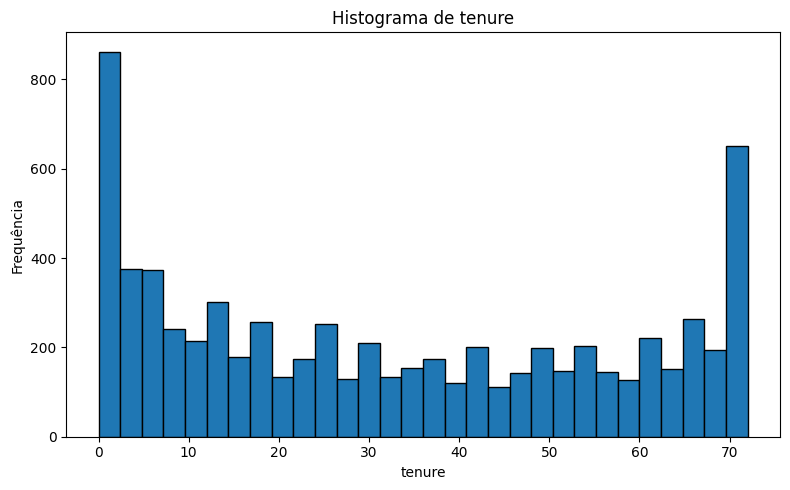

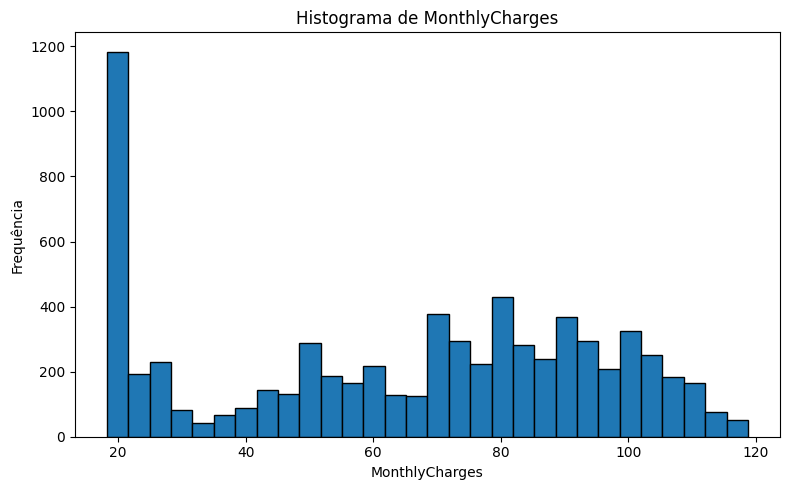

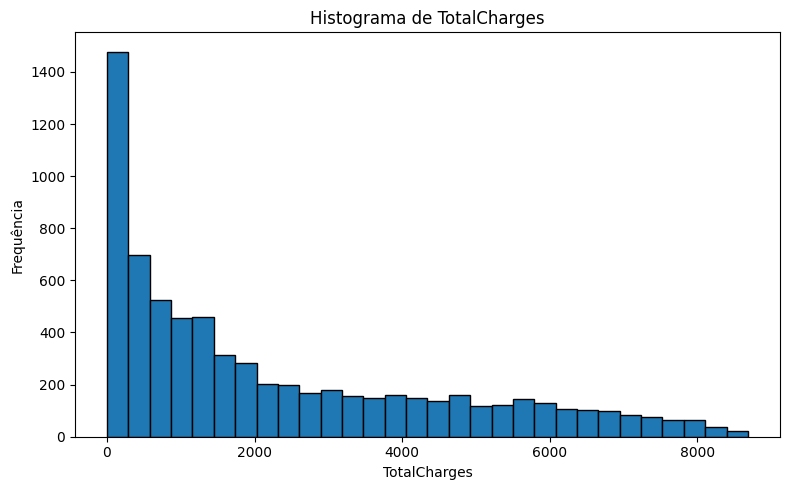

In [6]:
# Histogramas das variáveis numéricas

numeric_vars = ["tenure", "MonthlyCharges", "TotalCharges"]

for col in numeric_vars:
    plt.figure(figsize=(8, 5))
    plt.hist(df_m2[col].dropna(), bins=30, edgecolor="black")
    plt.title(f"Histograma de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.tight_layout()
    
    # Guardar figura
    plt.savefig(figures_path / f"histograma_{col}.png", dpi=300)
    
    plt.show()

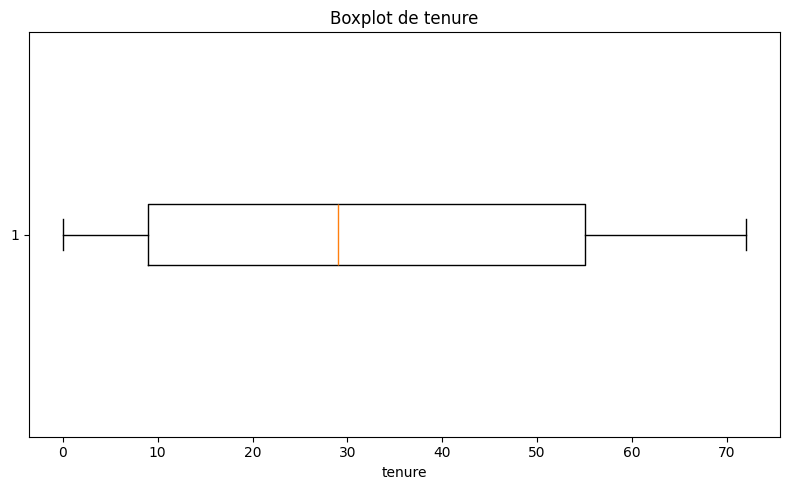

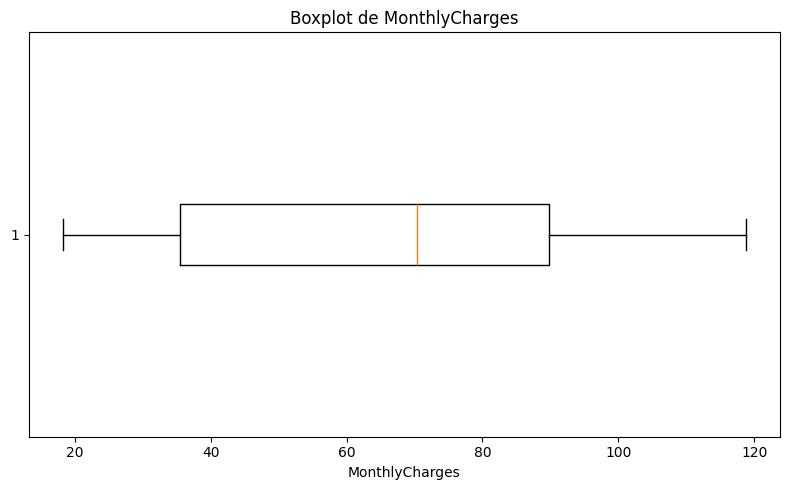

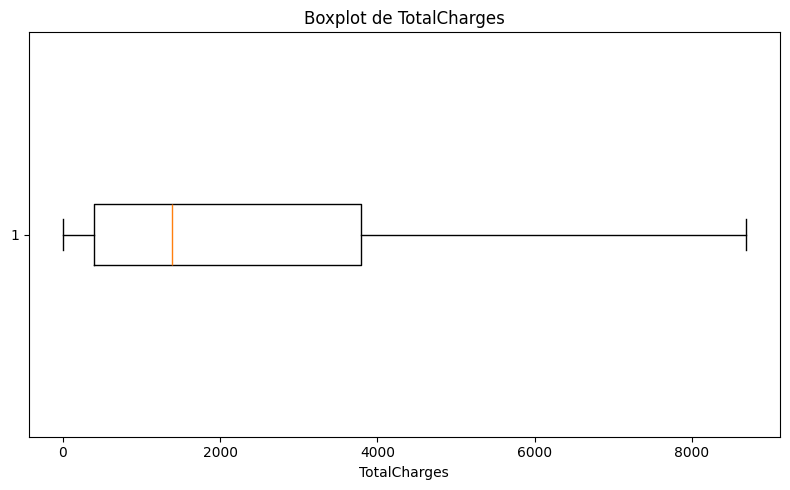

In [7]:
# Boxplots das variáveis numéricas

for col in numeric_vars:
    plt.figure(figsize=(8, 5))
    plt.boxplot(df_m2[col].dropna(), vert=False)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    
    # Guardar figura
    plt.savefig(figures_path / f"boxplot_{col}.png", dpi=300)
    
    plt.show()

In [8]:
# Estatísticas descritivas das variáveis numéricas

numeric_summary = df_m2[numeric_vars].describe().T

numeric_summary["amplitude"] = numeric_summary["max"] - numeric_summary["min"]
numeric_summary["coef_variacao"] = numeric_summary["std"] / numeric_summary["mean"]

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,amplitude,coef_variacao
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00,72.0,0.758684
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75,100.5,0.464627
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80,8684.8,0.994324


## 2. Frequência das variáveis categóricas

Nesta secção são analisadas as frequências das variáveis categóricas. A variável `customerID` foi excluída por ser apenas um identificador. A variável `Churn` também foi excluída desta análise principal, porque o projeto está orientado para segmentação não supervisionada e não para classificação.

In [9]:
# Frequências das variáveis categóricas

# Identificar variáveis categóricas
categorical_vars = df_m2.select_dtypes(include="object").columns.tolist()

# Remover identificador e Churn da análise principal
categorical_vars = [
    col for col in categorical_vars 
    if col not in ["customerID", "Churn"]
]

print("Variáveis categóricas analisadas:")
print(categorical_vars)

for col in categorical_vars:
    print(f"\nFrequência absoluta e relativa de {col}:")
    
    freq_table = pd.DataFrame({
        "Contagem": df_m2[col].value_counts(),
        "Percentagem": df_m2[col].value_counts(normalize=True) * 100
    })
    
    freq_table["Percentagem"] = freq_table["Percentagem"].round(2)
    
    display(freq_table)

Variáveis categóricas analisadas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Frequência absoluta e relativa de gender:


,Contagem,Percentagem
gender,,
Male,3555,50.48
Female,3488,49.52



Frequência absoluta e relativa de Partner:


,Contagem,Percentagem
Partner,,
No,3641,51.7
Yes,3402,48.3



Frequência absoluta e relativa de Dependents:


...

,Contagem,Percentagem
Contract,,
Month-to-month,3875,55.02
Two year,1695,24.07
One year,1473,20.91



Frequência absoluta e relativa de PaperlessBilling:


,Contagem,Percentagem
PaperlessBilling,,
Yes,4171,59.22
No,2872,40.78



Frequência absoluta e relativa de PaymentMethod:


,Contagem,Percentagem
PaymentMethod,,
Electronic check,2365,33.58
Mailed check,1612,22.89
Bank transfer (automatic),1544,21.92
Credit card (automatic),1522,21.61


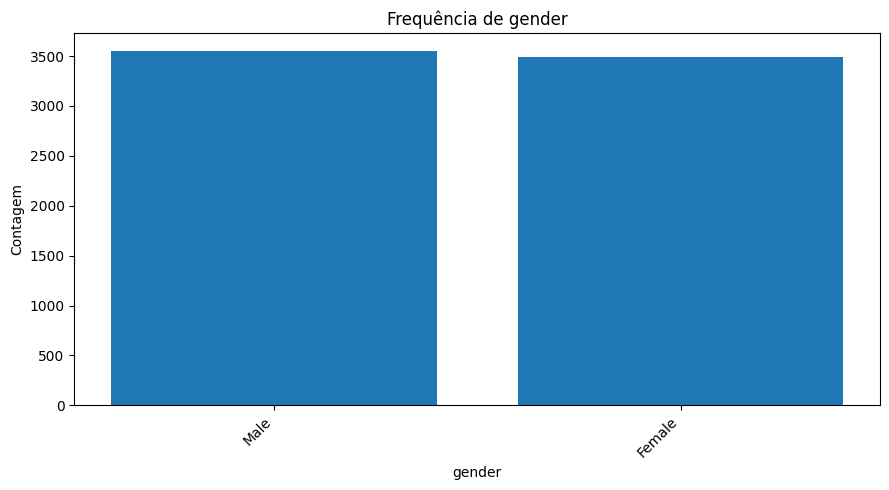

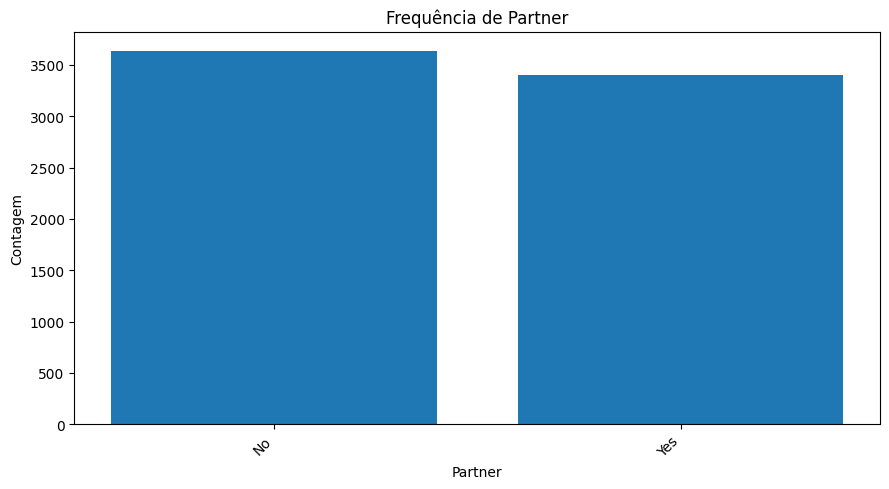

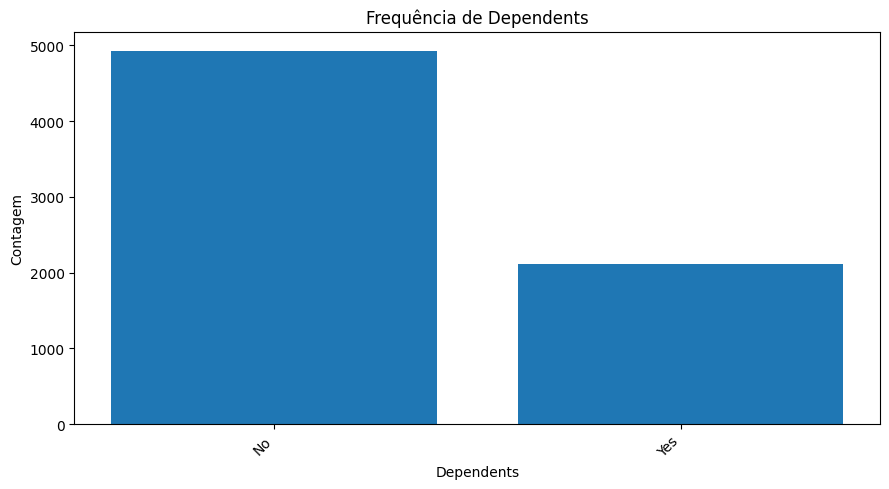

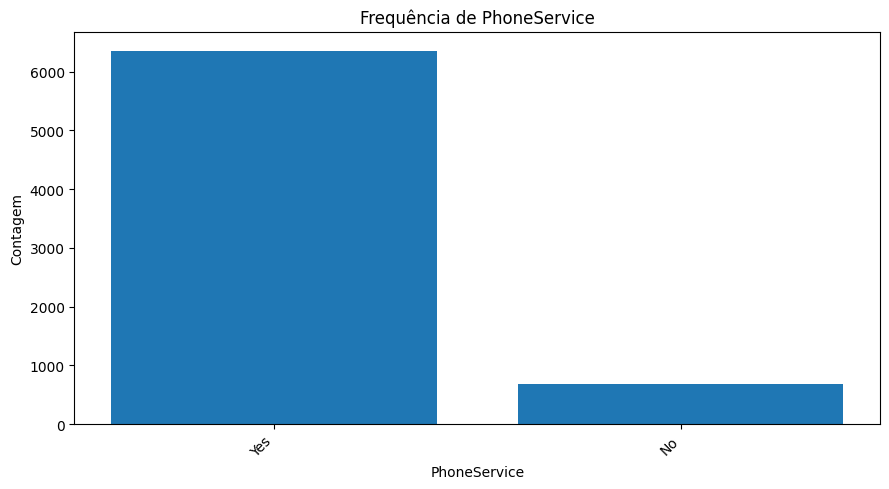

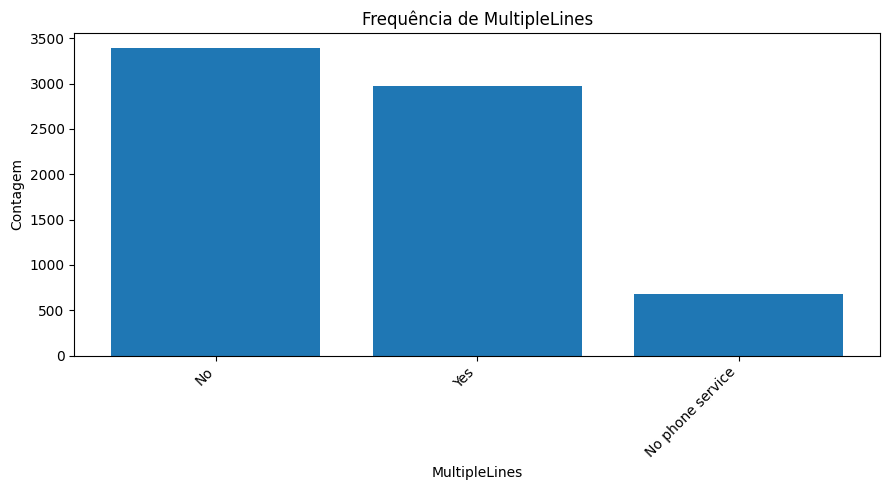

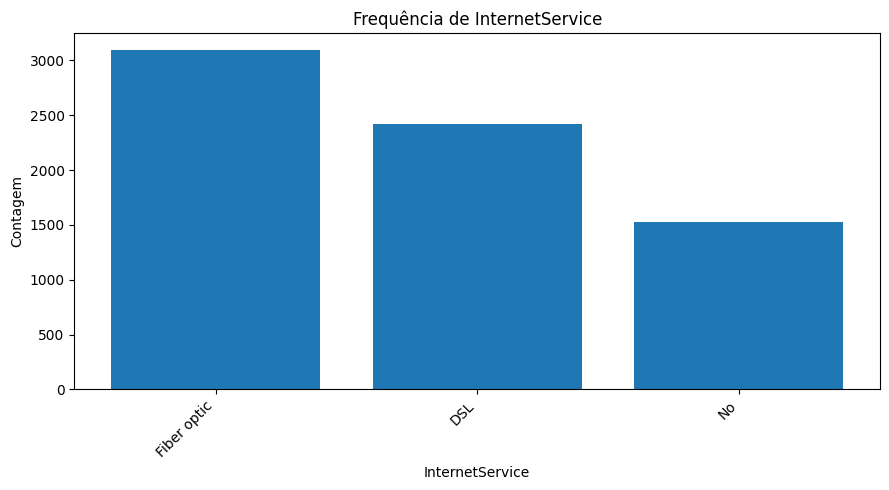

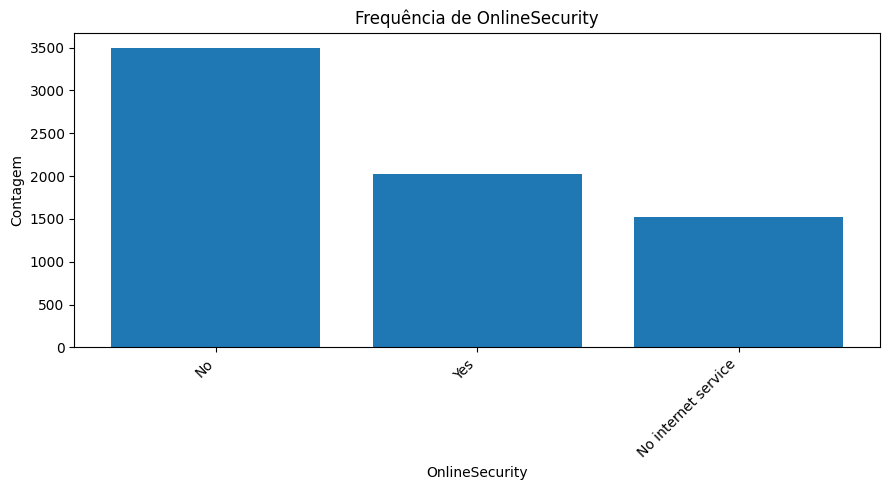

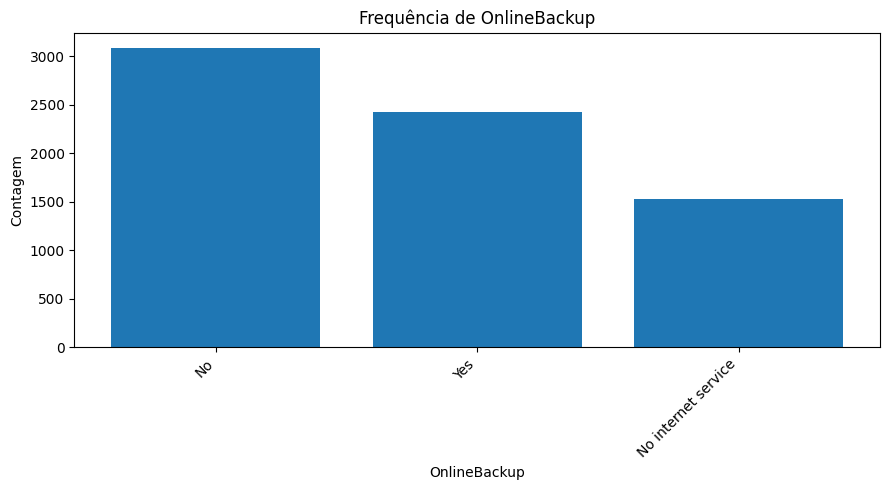

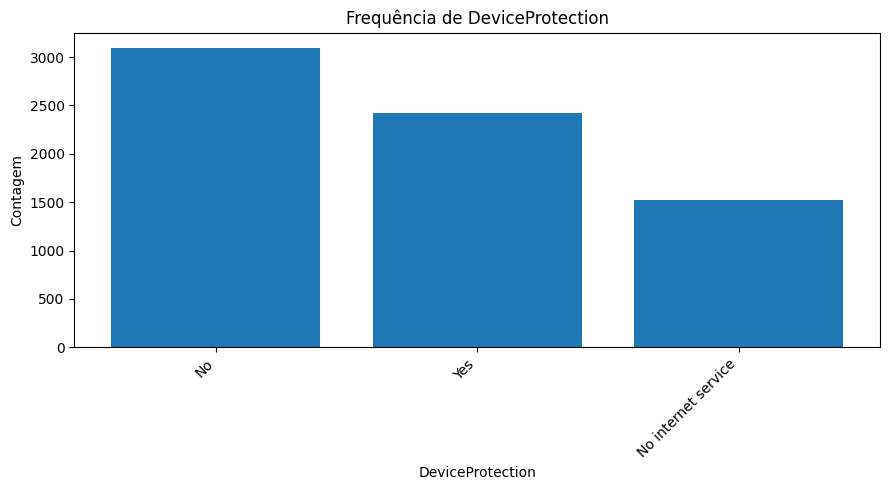

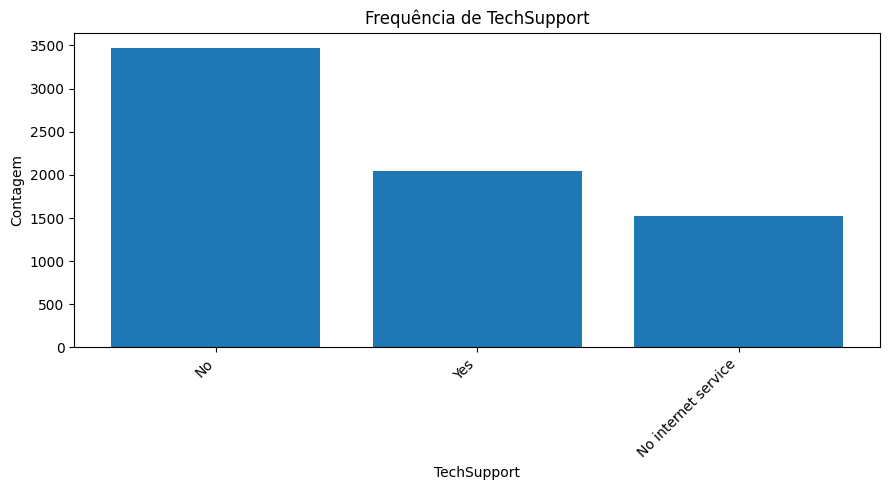

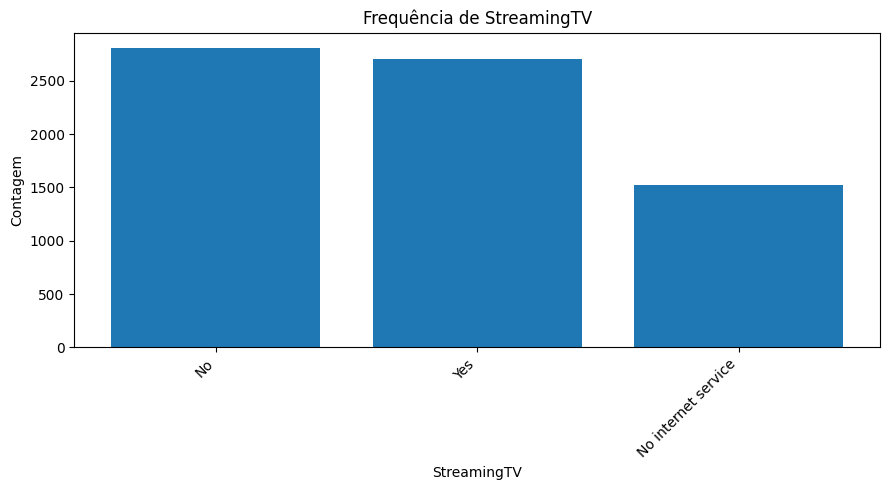

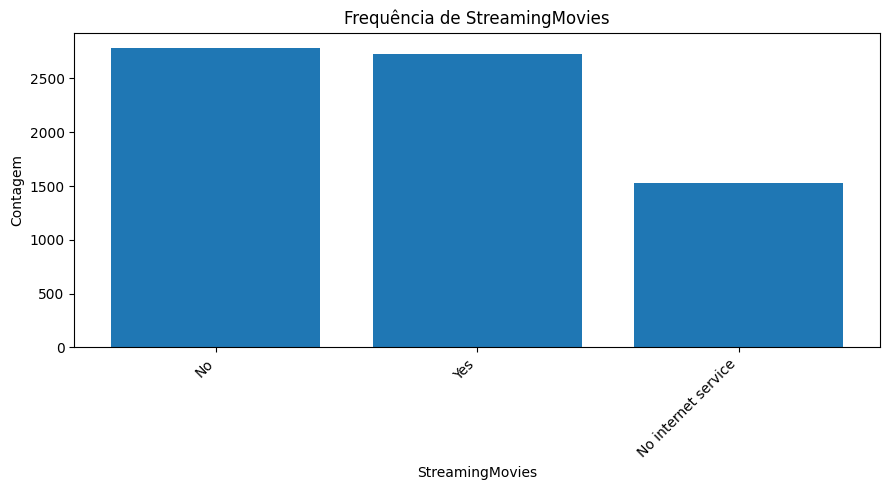

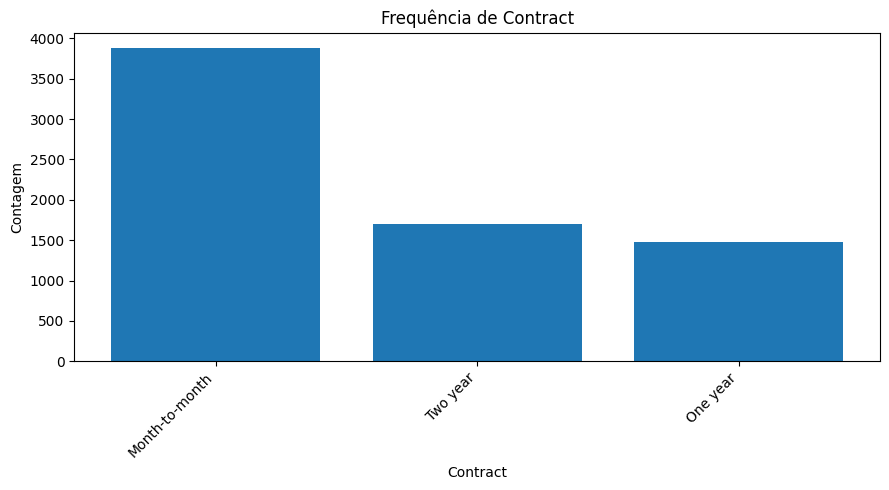

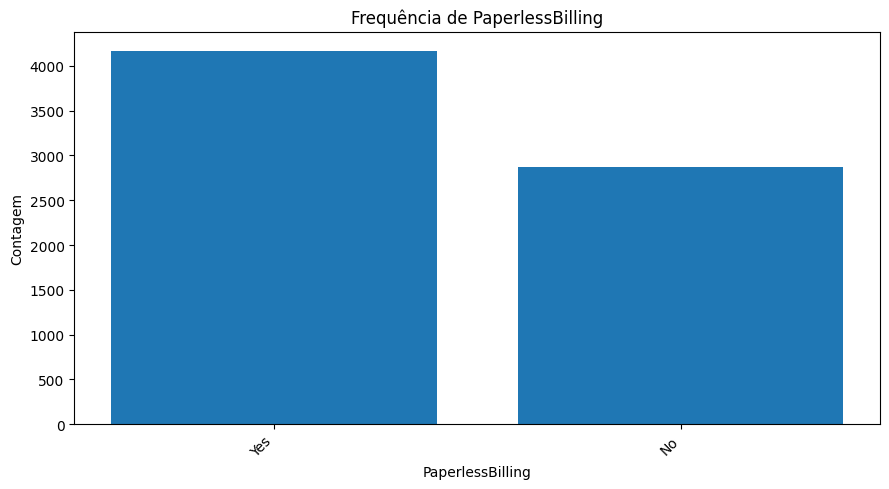

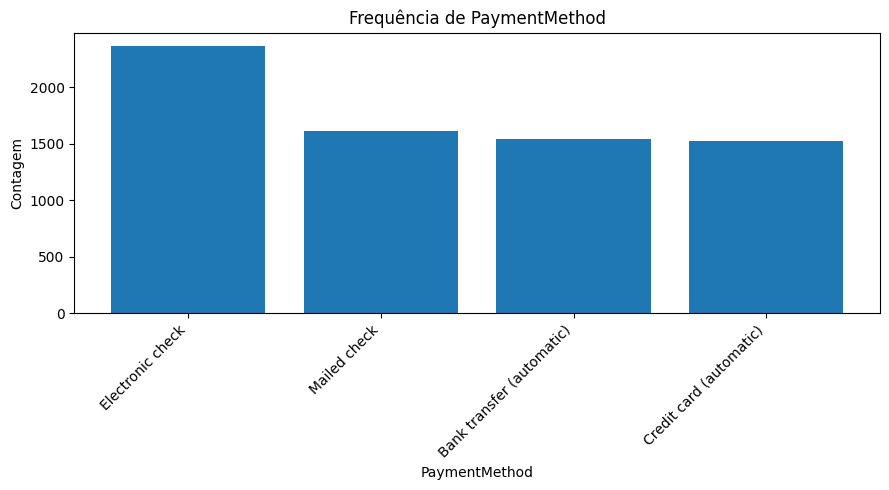

In [10]:
# Gráficos de barras das variáveis categóricas

for col in categorical_vars:
    plt.figure(figsize=(9, 5))
    
    counts = df_m2[col].value_counts()
    
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Frequência de {col}")
    plt.xlabel(col)
    plt.ylabel("Contagem")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    
    # Guardar figura
    safe_col_name = col.replace(" ", "_").replace("/", "_")
    plt.savefig(figures_path / f"frequencia_{safe_col_name}.png", dpi=300)
    
    plt.show()

## 3. Variáveis críticas para diferenciação dos clientes

Como o projeto segue uma abordagem não supervisionada, o foco não está em prever uma variável-alvo, mas sim em identificar variáveis que ajudam a diferenciar grupos de clientes.

Nesta fase, são consideradas especialmente relevantes as variáveis associadas a:

- tempo de permanência do cliente;
- valor mensal pago;
- valor total acumulado;
- tipo de contrato;
- serviços contratados;
- método de pagamento e faturação.

In [11]:
# Análise das variáveis numéricas mais diferenciadoras

critical_numeric_analysis = numeric_summary[
    ["mean", "std", "min", "max", "amplitude", "coef_variacao"]
].copy()

critical_numeric_analysis = critical_numeric_analysis.sort_values(
    by="coef_variacao", 
    ascending=False
)

display(critical_numeric_analysis)

,mean,std,min,max,amplitude,coef_variacao
TotalCharges,2279.734304,2266.794470,0.00,8684.80,8684.8,0.994324
tenure,32.371149,24.559481,0.00,72.00,72.0,0.758684
MonthlyCharges,64.761692,30.090047,18.25,118.75,100.5,0.464627


In [12]:
# Variáveis categóricas relevantes para segmentação

business_relevant_categoricals = [
    "Contract",
    "InternetService",
    "PaymentMethod",
    "OnlineSecurity",
    "TechSupport",
    "PaperlessBilling",
    "MultipleLines"
]

# Garantir que só são usadas colunas existentes no dataset
business_relevant_categoricals = [
    col for col in business_relevant_categoricals 
    if col in df_m2.columns
]

for col in business_relevant_categoricals:
    print(f"\nDistribuição de {col}:")
    
    freq = pd.DataFrame({
        "Contagem": df_m2[col].value_counts(),
        "Percentagem": (df_m2[col].value_counts(normalize=True) * 100).round(2)
    })
    
    display(freq)


Distribuição de Contract:


,Contagem,Percentagem
Contract,,
Month-to-month,3875,55.02
Two year,1695,24.07
One year,1473,20.91



Distribuição de InternetService:


,Contagem,Percentagem
InternetService,,
Fiber optic,3096,43.96
DSL,2421,34.37
No,1526,21.67



Distribuição de PaymentMethod:


...

,Contagem,Percentagem
TechSupport,,
No,3473,49.31
Yes,2044,29.02
No internet service,1526,21.67



Distribuição de PaperlessBilling:


,Contagem,Percentagem
PaperlessBilling,,
Yes,4171,59.22
No,2872,40.78



Distribuição de MultipleLines:


,Contagem,Percentagem
MultipleLines,,
No,3390,48.13
Yes,2971,42.18
No phone service,682,9.68


## 4. Síntese da análise univariada

A análise das variáveis numéricas permitiu observar a distribuição de `tenure`, `MonthlyCharges` e `TotalCharges`, que são variáveis importantes para diferenciar clientes com diferentes níveis de permanência e valor económico.

A análise das variáveis categóricas permitiu observar a distribuição dos tipos de contrato, serviços contratados, métodos de pagamento e opções de faturação. Estas variáveis serão relevantes para a fase seguinte, uma vez que podem contribuir para a formação de segmentos de clientes com características distintas.

Durante esta fase também foi corrigido o tipo de dados da variável `TotalCharges`, que inicialmente estava lida como texto. Após a conversão para numérico, os valores em falta foram analisados e tratados quando associados a clientes com `tenure = 0`.

A variável `Churn` não foi utilizada como variável-alvo, mantendo a coerência com a abordagem não supervisionada do projeto.

## 5. Análise Bivariada e Correlações

Nesta secção é realizada uma análise bivariada para estudar relações entre variáveis relevantes para a segmentação de clientes.

Como o projeto segue uma abordagem de aprendizagem não supervisionada, não será utilizada uma variável-alvo de classificação. Assim, em vez de analisar relações com `Churn`, serão analisadas relações entre variáveis críticas para a diferenciação dos clientes, nomeadamente `tenure`, `MonthlyCharges` e `TotalCharges`.

O objetivo é perceber se existem relações factuais entre atributos que possam influenciar a formação de perfis de clientes.

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pathlib import Path

# Garantir que a pasta de figuras existe
figures_path = Path("reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

,tenure,MonthlyCharges,TotalCharges,SeniorCitizen
tenure,1.000000,0.247900,0.826178,0.016567
MonthlyCharges,0.247900,1.000000,0.651174,0.220173
TotalCharges,0.826178,0.651174,1.000000,0.103006
SeniorCitizen,0.016567,0.220173,0.103006,1.000000


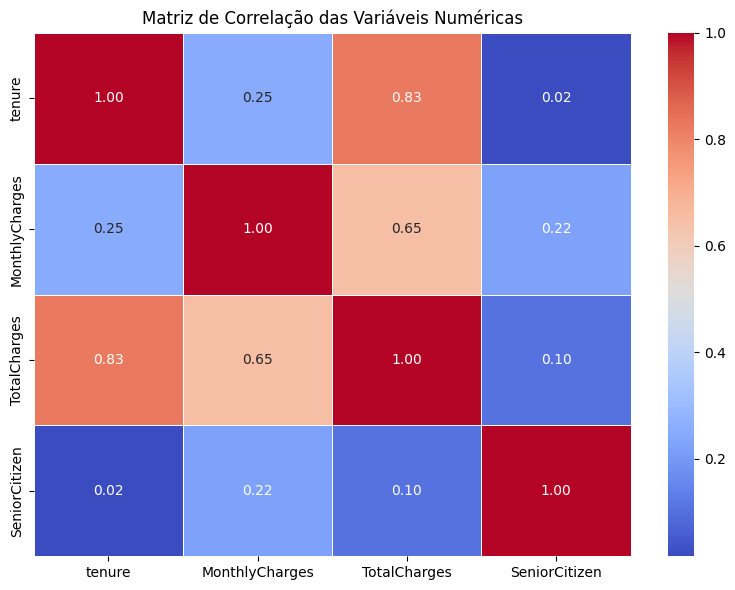

In [14]:
# Matriz de correlação das variáveis numéricas

# Selecionar variáveis numéricas relevantes para segmentação
corr_vars = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen"
]

# Garantir que só entram colunas existentes no dataframe
corr_vars = [col for col in corr_vars if col in df_m2.columns]

# Calcular matriz de correlação
corr_matrix = df_m2[corr_vars].corr()

display(corr_matrix)

# Criar heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de Correlação das Variáveis Numéricas")
plt.tight_layout()

# Guardar figura
plt.savefig(figures_path / "heatmap_correlacao_variaveis_numericas.png", dpi=300)

plt.show()

### Interpretação da matriz de correlação

A matriz de correlação permite observar relações lineares entre as principais variáveis numéricas do dataset.

A relação entre `tenure` e `TotalCharges` tende a ser positiva, o que é esperado, uma vez que clientes com maior tempo de permanência acumulam normalmente encargos totais mais elevados.

A variável `MonthlyCharges` também pode apresentar relação positiva com `TotalCharges`, pois clientes com encargos mensais mais altos tendem a acumular valores totais superiores ao longo do tempo.

Estas relações são relevantes para a segmentação, porque ajudam a distinguir clientes com diferentes níveis de permanência, valor mensal e valor acumulado.

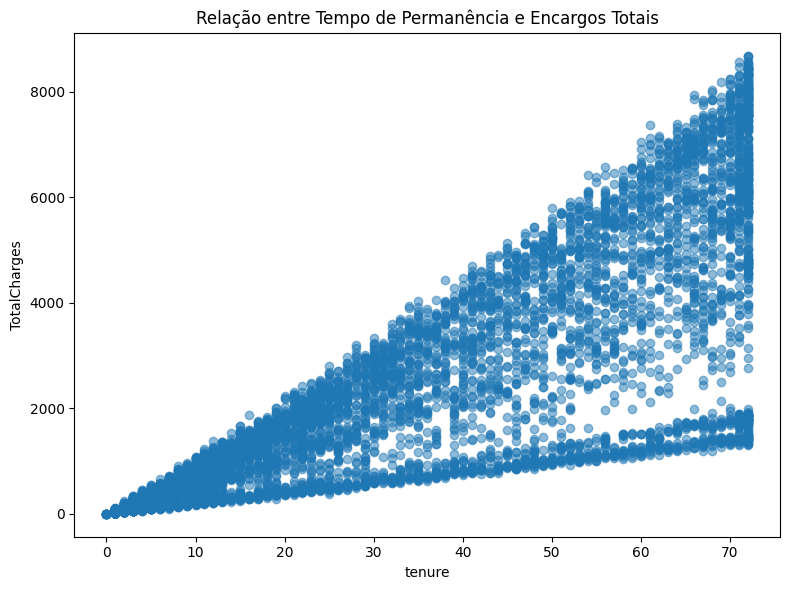

In [15]:
# Scatter plot: tenure vs TotalCharges

plt.figure(figsize=(8, 6))

plt.scatter(
    df_m2["tenure"],
    df_m2["TotalCharges"],
    alpha=0.5
)

plt.title("Relação entre Tempo de Permanência e Encargos Totais")
plt.xlabel("tenure")
plt.ylabel("TotalCharges")
plt.tight_layout()

# Guardar figura
plt.savefig(figures_path / "scatter_tenure_totalcharges.png", dpi=300)

plt.show()

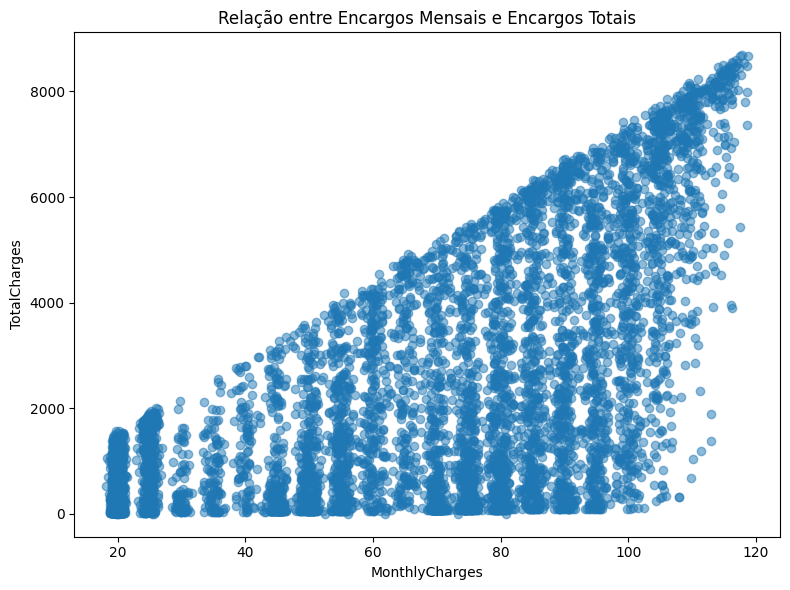

In [16]:
# Scatter plot: MonthlyCharges vs TotalCharges

plt.figure(figsize=(8, 6))

plt.scatter(
    df_m2["MonthlyCharges"],
    df_m2["TotalCharges"],
    alpha=0.5
)

plt.title("Relação entre Encargos Mensais e Encargos Totais")
plt.xlabel("MonthlyCharges")
plt.ylabel("TotalCharges")
plt.tight_layout()

# Guardar figura
plt.savefig(figures_path / "scatter_monthlycharges_totalcharges.png", dpi=300)

plt.show()

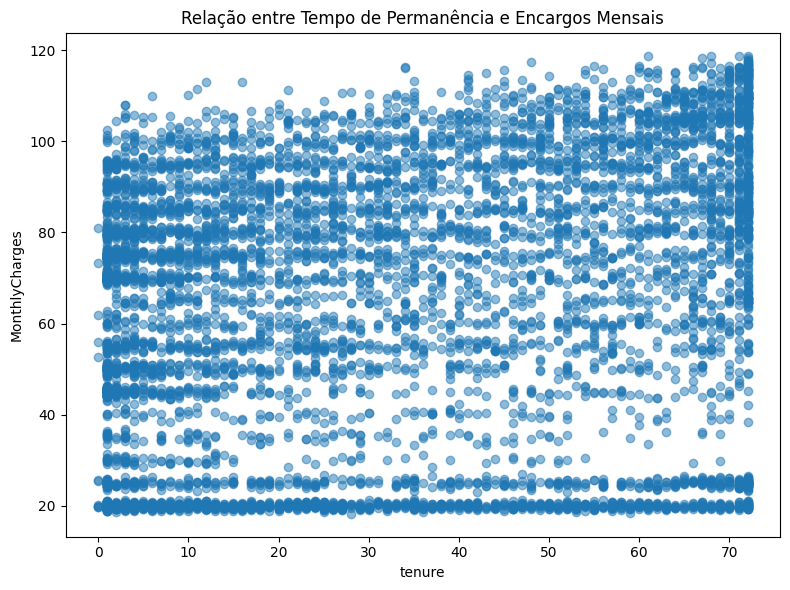

In [17]:
# Scatter plot: tenure vs MonthlyCharges

plt.figure(figsize=(8, 6))

plt.scatter(
    df_m2["tenure"],
    df_m2["MonthlyCharges"],
    alpha=0.5
)

plt.title("Relação entre Tempo de Permanência e Encargos Mensais")
plt.xlabel("tenure")
plt.ylabel("MonthlyCharges")
plt.tight_layout()

# Guardar figura
plt.savefig(figures_path / "scatter_tenure_monthlycharges.png", dpi=300)

plt.show()

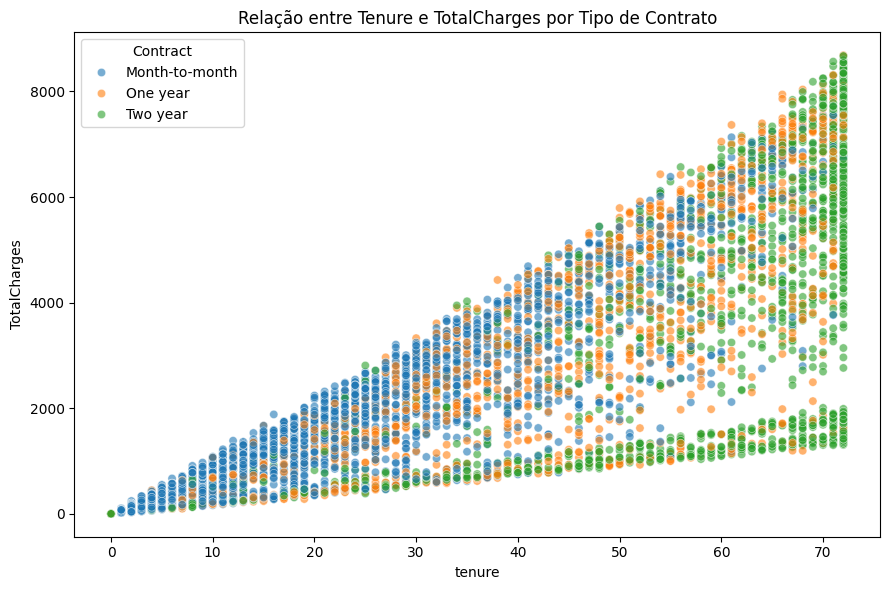

In [18]:
# Scatter plot com diferenciação por tipo de contrato

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_m2,
    x="tenure",
    y="TotalCharges",
    hue="Contract",
    alpha=0.6
)

plt.title("Relação entre Tenure e TotalCharges por Tipo de Contrato")
plt.xlabel("tenure")
plt.ylabel("TotalCharges")
plt.legend(title="Contract")
plt.tight_layout()

# Guardar figura
plt.savefig(figures_path / "scatter_tenure_totalcharges_contract.png", dpi=300)

plt.show()

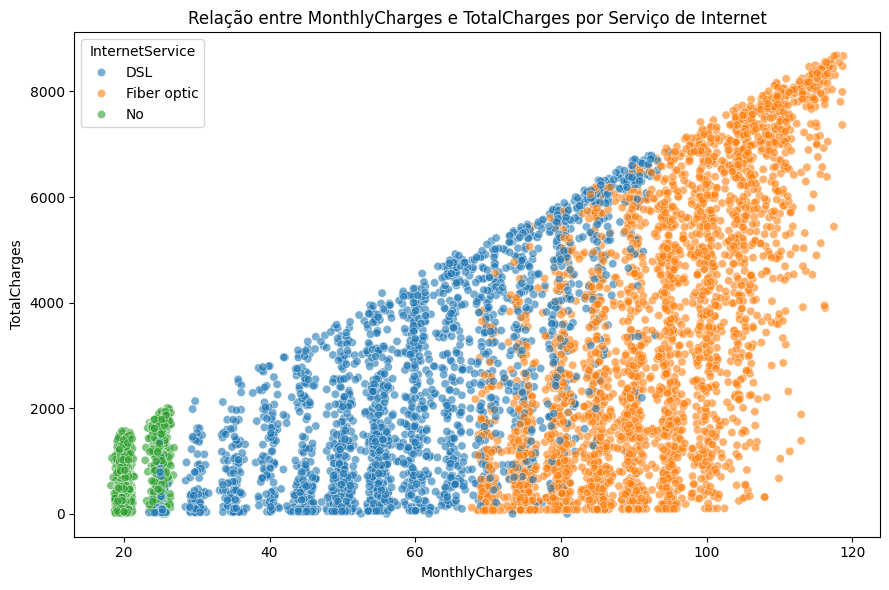

In [19]:
# Scatter plot com diferenciação por serviço de Internet

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df_m2,
    x="MonthlyCharges",
    y="TotalCharges",
    hue="InternetService",
    alpha=0.6
)

plt.title("Relação entre MonthlyCharges e TotalCharges por Serviço de Internet")
plt.xlabel("MonthlyCharges")
plt.ylabel("TotalCharges")
plt.legend(title="InternetService")
plt.tight_layout()

# Guardar figura
plt.savefig(figures_path / "scatter_monthlycharges_totalcharges_internetservice.png", dpi=300)

plt.show()

In [20]:
# Correlações ordenadas entre variáveis numéricas

corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ["Variável 1", "Variável 2", "Correlação"]

# Remover autocorrelações
corr_pairs = corr_pairs[corr_pairs["Variável 1"] != corr_pairs["Variável 2"]]

# Evitar pares duplicados
corr_pairs["Par"] = corr_pairs.apply(
    lambda row: tuple(sorted([row["Variável 1"], row["Variável 2"]])),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates("Par").drop(columns="Par")

# Ordenar por valor absoluto da correlação
corr_pairs["Correlação Absoluta"] = corr_pairs["Correlação"].abs()

corr_pairs = corr_pairs.sort_values(
    by="Correlação Absoluta",
    ascending=False
)

display(corr_pairs)

,Variável 1,Variável 2,Correlação,Correlação Absoluta
2,tenure,TotalCharges,0.826178,0.826178
6,MonthlyCharges,TotalCharges,0.651174,0.651174
1,tenure,MonthlyCharges,0.247900,0.247900
7,MonthlyCharges,SeniorCitizen,0.220173,0.220173
11,TotalCharges,SeniorCitizen,0.103006,0.103006
3,tenure,SeniorCitizen,0.016567,0.016567


### Síntese da análise bivariada

A análise bivariada mostrou relações relevantes entre algumas variáveis numéricas importantes para a segmentação.

A relação entre `tenure` e `TotalCharges` é particularmente importante, uma vez que clientes com maior tempo de permanência tendem a apresentar encargos totais superiores. Esta relação é coerente com a lógica do negócio, pois quanto mais tempo um cliente permanece na empresa, maior tende a ser o valor acumulado pago.

Também foi analisada a relação entre `MonthlyCharges` e `TotalCharges`, permitindo observar diferenças entre clientes com diferentes níveis de encargos mensais e valor total acumulado.

Os gráficos de dispersão com `Contract` e `InternetService` ajudam a perceber como variáveis contratuais e de serviços subscritos podem diferenciar grupos de clientes. Estas variáveis serão relevantes para a fase de preparação e modelação, onde o objetivo será identificar 3 perfis de clientes estatisticamente caracterizáveis.

## 6. Tratamento de Dados em Falta — Missing Data

Nesta secção é analisada a existência de valores em falta no dataset.

O objetivo é identificar a percentagem de valores nulos por coluna e definir uma estratégia de tratamento adequada, garantindo que o dataset fica preparado para a fase de modelação.

Como o projeto segue uma abordagem de segmentação não supervisionada, o tratamento de dados em falta será aplicado às variáveis relevantes para a diferenciação dos clientes, sem tratar `Churn` como variável-alvo.

In [21]:
# Tratamento de Dados em Falta — Missing Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Garantir que existe uma cópia para a Milestone 2
try:
    df_m2
except NameError:
    df_m2 = df.copy()

# Garantir que a pasta de figuras existe
figures_path = Path("reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

# Percentagem de valores em falta antes de qualquer tratamento
missing_summary_before = pd.DataFrame({
    "Valores em falta": df_m2.isna().sum(),
    "Percentagem (%)": (df_m2.isna().mean() * 100).round(2)
})

missing_summary_before = missing_summary_before.sort_values(
    by="Percentagem (%)",
    ascending=False
)

display(missing_summary_before)

,Valores em falta,Percentagem (%)
TotalCharges_num,11,0.16
customerID,0,0.00
SeniorCitizen,0,0.00
Partner,0,0.00
Dependents,0,0.00
gender,0,0.00
tenure,0,0.00
PhoneService,0,0.00
InternetService,0,0.00
MultipleLines,0,0.00


In [22]:
# Conversão de TotalCharges para numérico

# Converter TotalCharges para numérico
# Valores inválidos ou espaços em branco passam a NaN
df_m2["TotalCharges"] = pd.to_numeric(df_m2["TotalCharges"], errors="coerce")

# Verificar novamente os valores em falta depois da conversão
missing_summary_after_conversion = pd.DataFrame({
    "Valores em falta": df_m2.isna().sum(),
    "Percentagem (%)": (df_m2.isna().mean() * 100).round(2)
})

missing_summary_after_conversion = missing_summary_after_conversion.sort_values(
    by="Percentagem (%)",
    ascending=False
)

display(missing_summary_after_conversion)

print("Linhas com TotalCharges em falta após conversão:")
display(
    df_m2[df_m2["TotalCharges"].isna()][
        ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
    ]
)

,Valores em falta,Percentagem (%)
TotalCharges_num,11,0.16
customerID,0,0.00
SeniorCitizen,0,0.00
Partner,0,0.00
Dependents,0,0.00
gender,0,0.00
tenure,0,0.00
PhoneService,0,0.00
InternetService,0,0.00
MultipleLines,0,0.00


Linhas com TotalCharges em falta após conversão:


,customerID,tenure,MonthlyCharges,TotalCharges


In [23]:
# Análise dos valores em falta em TotalCharges

missing_totalcharges = df_m2[df_m2["TotalCharges"].isna()]

print("Número de valores em falta em TotalCharges:")
print(len(missing_totalcharges))

print("\nDistribuição de tenure nas linhas com TotalCharges em falta:")
display(missing_totalcharges["tenure"].value_counts().sort_index().to_frame("Contagem"))

# Verificar se todos os nulos de TotalCharges correspondem a tenure = 0
all_missing_have_tenure_zero = (missing_totalcharges["tenure"] == 0).all()
print(all_missing_have_tenure_zero)

Número de valores em falta em TotalCharges:
0

Distribuição de tenure nas linhas com TotalCharges em falta:


,Contagem
tenure,


True


In [24]:
# Estratégia de tratamento de valores em falta

# 1. TotalCharges:
# Se TotalCharges está em falta e tenure = 0, então TotalCharges é preenchido com 0.
# Justificação: clientes com tenure = 0 ainda não acumularam encargos totais.

condition_totalcharges_zero = df_m2["TotalCharges"].isna() & (df_m2["tenure"] == 0)

df_m2.loc[condition_totalcharges_zero, "TotalCharges"] = 0

print("Valores de TotalCharges preenchidos com 0:")
print(condition_totalcharges_zero.sum())


# 2. Restantes valores numéricos em falta:
# Usar mediana, porque é menos sensível a outliers do que a média.

numeric_cols = df_m2.select_dtypes(include=["int64", "float64"]).columns.tolist()

for col in numeric_cols:
    if df_m2[col].isna().sum() > 0:
        median_value = df_m2[col].median()
        df_m2[col] = df_m2[col].fillna(median_value)
        print(f"Coluna numérica '{col}' preenchida com mediana: {median_value}")


# 3. Restantes valores categóricos em falta:
# Usar moda, porque representa a categoria mais frequente.

categorical_cols = df_m2.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    if df_m2[col].isna().sum() > 0:
        mode_value = df_m2[col].mode()[0]
        df_m2[col] = df_m2[col].fillna(mode_value)
        print(f"Coluna categórica '{col}' preenchida com moda: {mode_value}")

Valores de TotalCharges preenchidos com 0:
0
Coluna numérica 'TotalCharges_num' preenchida com mediana: 1397.475


In [25]:
# Verificação final dos valores em falta

missing_summary_after = pd.DataFrame({
    "Valores em falta": df_m2.isna().sum(),
    "Percentagem (%)": (df_m2.isna().mean() * 100).round(2)
})

missing_summary_after = missing_summary_after.sort_values(
    by="Percentagem (%)",
    ascending=False
)

display(missing_summary_after)

print("Total de valores em falta no dataset após tratamento:")
print(df_m2.isna().sum().sum())

,Valores em falta,Percentagem (%)
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


Total de valores em falta no dataset após tratamento:
0


In [26]:
# Guardar dataset após tratamento de valores em falta

processed_path = Path("data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

output_file = processed_path / "telco_customer_churn_m2_missing_tratado.csv"

df_m2.to_csv(output_file, index=False)

print(f"Dataset guardado em: {output_file}")
print(f"Dimensão final: {df_m2.shape[0]} linhas e {df_m2.shape[1]} colunas")

Dataset guardado em: data/processed/telco_customer_churn_m2_missing_tratado.csv
Dimensão final: 7043 linhas e 22 colunas


### Síntese do tratamento de dados em falta

Foi analisada a percentagem de valores em falta por coluna. Após a conversão da variável `TotalCharges` para formato numérico, foram identificados valores em falta associados a registos onde esta variável não estava corretamente representada como número.

A estratégia adotada foi preencher `TotalCharges` com 0 quando o cliente apresentava `tenure = 0`, uma vez que clientes sem tempo de permanência ainda não acumularam encargos totais.

Para eventuais valores em falta em variáveis numéricas, foi definida a mediana como estratégia de imputação, por ser menos sensível a valores extremos do que a média. Para eventuais valores em falta em variáveis categóricas, foi definida a moda como estratégia de imputação, por representar a categoria mais frequente.

Após o tratamento, foi confirmada a inexistência de valores em falta no dataset preparado para as próximas fases da Milestone 2.

## 7. Tratamento de Outliers e Erros nos Dados

Nesta secção são analisados possíveis valores atípicos e erros no reconhecimento dos tipos de dados.

Como o projeto tem como objetivo construir um modelo descritivo de segmentação de clientes, é importante garantir que as variáveis numéricas estão corretamente representadas e que valores extremos não enviesam a formação dos perfis.

A análise será focada nas principais variáveis numéricas relevantes para a segmentação:

- `tenure`;
- `MonthlyCharges`;
- `TotalCharges`.

Também será verificado se existem erros de tipo, como variáveis numéricas lidas como texto.

In [27]:
# Verificação dos tipos de dados

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Garantir que existe uma cópia para a Milestone 2
try:
    df_m2
except NameError:
    df_m2 = df.copy()

# Criar pasta para guardar figuras
figures_path = Path("reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

# Verificar tipos de dados
data_types = pd.DataFrame({
    "Coluna": df_m2.columns,
    "Tipo de dados": df_m2.dtypes.astype(str),
    "Valores únicos": df_m2.nunique().values,
    "Valores em falta": df_m2.isna().sum().values
})

display(data_types)

,Coluna,Tipo de dados,Valores únicos,Valores em falta
customerID,customerID,object,7043,0
gender,gender,object,2,0
SeniorCitizen,SeniorCitizen,int64,2,0
Partner,Partner,object,2,0
Dependents,Dependents,object,2,0
tenure,tenure,int64,73,0
PhoneService,PhoneService,object,2,0
MultipleLines,MultipleLines,object,3,0
InternetService,InternetService,object,3,0
OnlineSecurity,OnlineSecurity,object,3,0


In [28]:
# Correção do tipo de dados da variável TotalCharges

print("Tipo de dados de TotalCharges antes da conversão:")
print(df_m2["TotalCharges"].dtype)

# Converter TotalCharges para numérico
df_m2["TotalCharges"] = pd.to_numeric(df_m2["TotalCharges"], errors="coerce")

print("\nTipo de dados de TotalCharges depois da conversão:")
print(df_m2["TotalCharges"].dtype)

print("\nValores em falta em TotalCharges após conversão:")
print(df_m2["TotalCharges"].isna().sum())

# Caso existam valores em falta com tenure = 0, preencher com 0
condition_totalcharges_zero = df_m2["TotalCharges"].isna() & (df_m2["tenure"] == 0)

df_m2.loc[condition_totalcharges_zero, "TotalCharges"] = 0

print("\nValores de TotalCharges preenchidos com 0:")
print(condition_totalcharges_zero.sum())

print("\nValores em falta em TotalCharges após tratamento:")
print(df_m2["TotalCharges"].isna().sum())

Tipo de dados de TotalCharges antes da conversão:
float64

Tipo de dados de TotalCharges depois da conversão:
float64

Valores em falta em TotalCharges após conversão:
0

Valores de TotalCharges preenchidos com 0:
0

Valores em falta em TotalCharges após tratamento:
0


In [29]:
# Verificação de valores impossíveis ou incoerentes

numeric_vars = ["tenure", "MonthlyCharges", "TotalCharges"]

# Garantir que só entram colunas existentes
numeric_vars = [col for col in numeric_vars if col in df_m2.columns]

range_check = pd.DataFrame({
    "Mínimo": df_m2[numeric_vars].min(),
    "Máximo": df_m2[numeric_vars].max(),
    "Média": df_m2[numeric_vars].mean(),
    "Mediana": df_m2[numeric_vars].median(),
    "Desvio padrão": df_m2[numeric_vars].std()
})

display(range_check)

# Verificar valores negativos
for col in numeric_vars:
    negative_count = (df_m2[col] < 0).sum()
    print(f"{col}: {negative_count} valores negativos")

,Mínimo,Máximo,Média,Mediana,Desvio padrão
tenure,0.00,72.00,32.371149,29.00,24.559481
MonthlyCharges,18.25,118.75,64.761692,70.35,30.090047
TotalCharges,0.00,8684.80,2279.734304,1394.55,2266.794470


tenure: 0 valores negativos
MonthlyCharges: 0 valores negativos
TotalCharges: 0 valores negativos


In [30]:
# Identificação de outliers pelo método IQR

outlier_summary = []

for col in numeric_vars:
    Q1 = df_m2[col].quantile(0.25)
    Q3 = df_m2[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df_m2[(df_m2[col] < lower_limit) | (df_m2[col] > upper_limit)]
    
    outlier_summary.append({
        "Variável": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Limite inferior": lower_limit,
        "Limite superior": upper_limit,
        "N.º de outliers": len(outliers),
        "Percentagem de outliers (%)": round(len(outliers) / len(df_m2) * 100, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

display(outlier_summary_df)

,Variável,Q1,Q3,IQR,Limite inferior,Limite superior,N.º de outliers,Percentagem de outliers (%)
0,tenure,9.00,55.00,46.00,-60.000,124.000,0,0.0
1,MonthlyCharges,35.50,89.85,54.35,-46.025,171.375,0,0.0
2,TotalCharges,398.55,3786.60,3388.05,-4683.525,8868.675,0,0.0


In [31]:
# Visualização dos registos considerados outliers

for col in numeric_vars:
    Q1 = df_m2[col].quantile(0.25)
    Q3 = df_m2[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    outliers = df_m2[(df_m2[col] < lower_limit) | (df_m2[col] > upper_limit)]
    
    print(f"\nOutliers identificados em {col}: {len(outliers)}")
    
    if len(outliers) > 0:
        display(
            outliers[
                ["customerID", "tenure", "MonthlyCharges", "TotalCharges"]
            ].head(10)
        )


Outliers identificados em tenure: 0

Outliers identificados em MonthlyCharges: 0

Outliers identificados em TotalCharges: 0


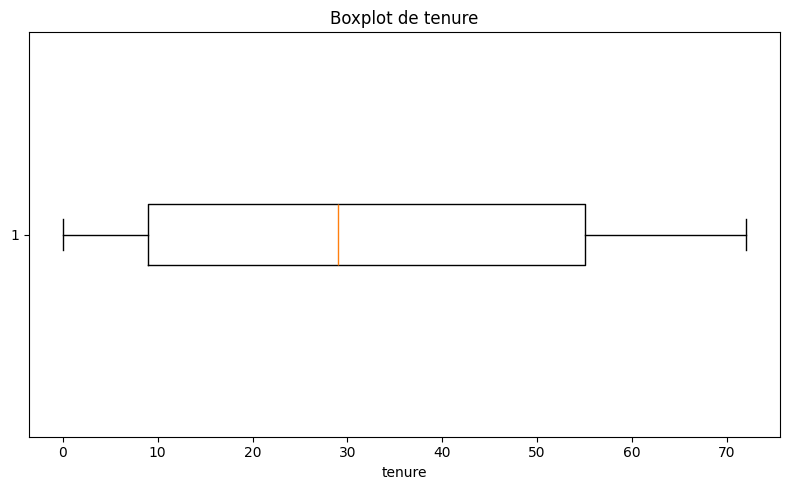

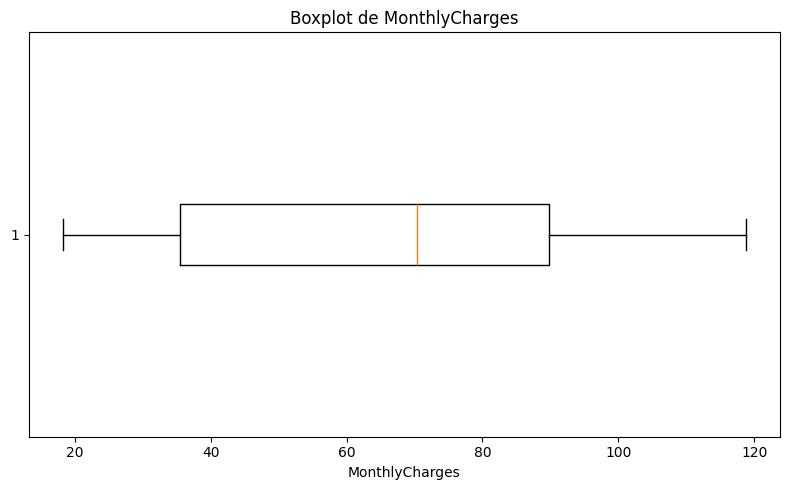

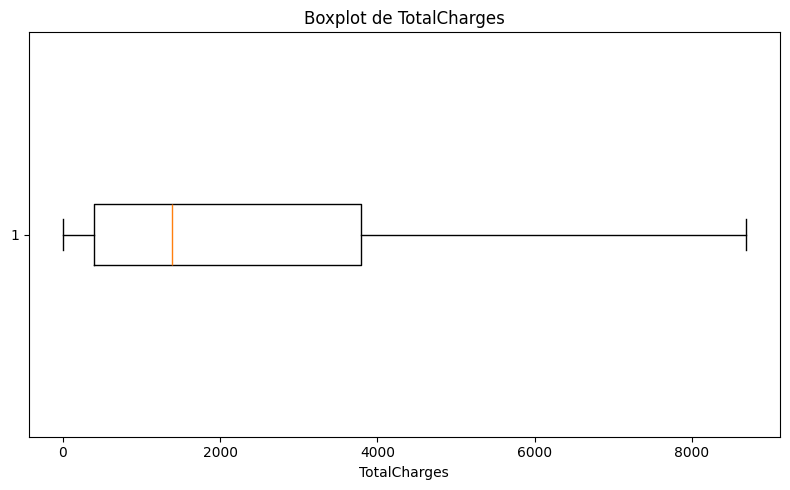

In [32]:
# Boxplots para identificação visual de outliers
for col in numeric_vars:
    plt.figure(figsize=(8, 5))
    plt.boxplot(df_m2[col].dropna(), vert=False)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.tight_layout()
    
    plt.savefig(figures_path / f"boxplot_outliers_{col}.png", dpi=300)
    
    plt.show()

### Decisão sobre o tratamento dos outliers

Foram identificados possíveis valores atípicos através do método IQR e através de boxplots.

No entanto, os valores extremos encontrados nas variáveis `tenure`, `MonthlyCharges` e `TotalCharges` não foram automaticamente removidos, porque podem representar clientes reais com maior permanência, maior nível de serviços contratados ou maior valor económico acumulado.

A remoção automática destes valores poderia eliminar perfis relevantes para a segmentação. Assim, nesta fase, os outliers foram documentados e mantidos no dataset.

Na fase de preparação para modelação, será aplicado escalonamento às variáveis numéricas, de forma a reduzir o impacto das diferentes escalas entre atributos.

In [33]:
# Criação de variáveis indicadoras de outliers

for col in numeric_vars:
    Q1 = df_m2[col].quantile(0.25)
    Q3 = df_m2[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR
    
    df_m2[f"{col}_outlier"] = (
        (df_m2[col] < lower_limit) | 
        (df_m2[col] > upper_limit)
    ).astype(int)

outlier_flag_cols = [f"{col}_outlier" for col in numeric_vars]

display(df_m2[outlier_flag_cols].sum().to_frame("N.º de outliers sinalizados"))

,N.º de outliers sinalizados
tenure_outlier,0
MonthlyCharges_outlier,0
TotalCharges_outlier,0


In [34]:
# Verificação final dos tipos de dados após correções

final_data_types = pd.DataFrame({
    "Coluna": df_m2.columns,
    "Tipo de dados final": df_m2.dtypes.astype(str),
    "Valores em falta": df_m2.isna().sum().values
})

display(final_data_types)

,Coluna,Tipo de dados final,Valores em falta
customerID,customerID,object,0
gender,gender,object,0
SeniorCitizen,SeniorCitizen,int64,0
Partner,Partner,object,0
Dependents,Dependents,object,0
tenure,tenure,int64,0
PhoneService,PhoneService,object,0
MultipleLines,MultipleLines,object,0
InternetService,InternetService,object,0
OnlineSecurity,OnlineSecurity,object,0


In [35]:
# Guardar dataset após análise de outliers e correção de tipos

processed_path = Path("data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

output_file = processed_path / "telco_customer_churn_m2_outliers_tipos_tratados.csv"

df_m2.to_csv(output_file, index=False)

print(f"Dataset guardado em: {output_file}")
print(f"Dimensão final: {df_m2.shape[0]} linhas e {df_m2.shape[1]} colunas")

Dataset guardado em: data/processed/telco_customer_churn_m2_outliers_tipos_tratados.csv
Dimensão final: 7043 linhas e 25 colunas


## 8. Transformação de Variáveis

Nesta fase são aplicadas transformações às variáveis para preparar o dataset para a modelação não supervisionada.

Como os algoritmos de segmentação trabalham com valores numéricos, as variáveis categóricas serão transformadas através de One-Hot Encoding. Esta opção é adequada porque a maioria das variáveis categóricas do dataset não tem uma ordem natural.

As variáveis numéricas `tenure`, `MonthlyCharges` e `TotalCharges` serão escalonadas com StandardScaler, para que fiquem numa escala comparável. Esta transformação é importante porque algoritmos como K-Means são sensíveis à escala das variáveis.

A variável `customerID` será excluída por ser apenas um identificador. A variável `Churn` também será excluída, mantendo a coerência com a abordagem de aprendizagem não supervisionada.

In [36]:
# Transformação de Variáveis — Preparação Inicial

import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler

# Garantir que existe uma cópia da Milestone 2
try:
    df_m2
except NameError:
    df_m2 = df.copy()

# Garantir que TotalCharges está em formato numérico
df_m2["TotalCharges"] = pd.to_numeric(df_m2["TotalCharges"], errors="coerce")

# Preencher TotalCharges com 0 quando tenure = 0
condition_totalcharges_zero = df_m2["TotalCharges"].isna() & (df_m2["tenure"] == 0)
df_m2.loc[condition_totalcharges_zero, "TotalCharges"] = 0

# Caso ainda existam nulos em TotalCharges, preencher com a mediana
if df_m2["TotalCharges"].isna().sum() > 0:
    df_m2["TotalCharges"] = df_m2["TotalCharges"].fillna(df_m2["TotalCharges"].median())

print("Valores em falta em TotalCharges após preparação:")
print(df_m2["TotalCharges"].isna().sum())

Valores em falta em TotalCharges após preparação:
0


In [37]:
# Seleção das variáveis para segmentação

# Variáveis demográficas
demographic_vars = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

# Variáveis contratuais
contractual_vars = [
    "tenure",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

# Variáveis de serviços subscritos
service_vars = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Variáveis de consumo / valor económico
consumption_vars = [
    "MonthlyCharges",
    "TotalCharges"
]

# Juntar variáveis segundo o Objetivo SMART
selected_vars = (
    demographic_vars
    + contractual_vars
    + service_vars
    + consumption_vars
)

# Garantir que só entram colunas existentes no dataframe
selected_vars = [col for col in selected_vars if col in df_m2.columns]

# Criar dataframe apenas com as variáveis selecionadas
df_transform = df_m2[selected_vars].copy()

print("Variáveis selecionadas para transformação:")
print(selected_vars)

print("\nDimensão antes da transformação:")
print(df_transform.shape)

display(df_transform.head())

Variáveis selecionadas para transformação:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MonthlyCharges', 'TotalCharges']

Dimensão antes da transformação:
(7043, 19)


,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,PaperlessBilling,PaymentMethod,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,Month-to-month,Yes,Electronic check,No,No phone service,DSL,No,Yes,No,No,No,No,29.85,29.85
1,Male,0,No,No,34,One year,No,Mailed check,Yes,No,DSL,Yes,No,Yes,No,No,No,56.95,1889.50
2,Male,0,No,No,2,Month-to-month,Yes,Mailed check,Yes,No,DSL,Yes,Yes,No,No,No,No,53.85,108.15
3,Male,0,No,No,45,One year,No,Bank transfer (automatic),No,No phone service,DSL,Yes,No,Yes,Yes,No,No,42.30,1840.75
4,Female,0,No,No,2,Month-to-month,Yes,Electronic check,Yes,No,Fiber optic,No,No,No,No,No,No,70.70,151.65


In [38]:
# Identificação dos tipos de variáveis

# Variáveis numéricas que serão escalonadas
numeric_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

numeric_features = [col for col in numeric_features if col in df_transform.columns]

# Variáveis binárias já numéricas
binary_numeric_features = [
    "SeniorCitizen"
]

binary_numeric_features = [col for col in binary_numeric_features if col in df_transform.columns]

# Variáveis categóricas a transformar com One-Hot Encoding
categorical_features = df_transform.select_dtypes(include=["object"]).columns.tolist()

print("Variáveis numéricas a escalonar:")
print(numeric_features)

print("\nVariáveis binárias já numéricas:")
print(binary_numeric_features)

print("\nVariáveis categóricas para One-Hot Encoding:")
print(categorical_features)

Variáveis numéricas a escalonar:
['tenure', 'MonthlyCharges', 'TotalCharges']

Variáveis binárias já numéricas:
['SeniorCitizen']

Variáveis categóricas para One-Hot Encoding:
['gender', 'Partner', 'Dependents', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']


In [39]:
# One-Hot Encoding das variáveis categóricas

df_encoded = pd.get_dummies(
    df_transform,
    columns=categorical_features,
    drop_first=False,
    dtype=int
)

print("Dimensão antes do One-Hot Encoding:")
print(df_transform.shape)

print("\nDimensão depois do One-Hot Encoding:")
print(df_encoded.shape)

print("\nPrimeiras linhas após One-Hot Encoding:")
display(df_encoded.head())

Dimensão antes do One-Hot Encoding:
(7043, 19)

Dimensão depois do One-Hot Encoding:
(7043, 45)

Primeiras linhas após One-Hot Encoding:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,1,29.85,29.85,1,0,0,1,1,0,...,0,1,0,0,1,0,0,1,0,0
1,0,34,56.95,1889.50,0,1,1,0,1,0,...,1,1,0,0,1,0,0,1,0,0
2,0,2,53.85,108.15,0,1,1,0,1,0,...,0,1,0,0,1,0,0,1,0,0
3,0,45,42.30,1840.75,0,1,1,0,1,0,...,1,0,0,1,1,0,0,1,0,0
4,0,2,70.70,151.65,1,0,1,0,1,0,...,0,1,0,0,1,0,0,1,0,0


In [40]:
# Escalonamento das variáveis numéricas com StandardScaler

df_model_ready = df_encoded.copy()

scaler = StandardScaler()

df_model_ready[numeric_features] = scaler.fit_transform(
    df_model_ready[numeric_features]
)

print("Dataset após escalonamento das variáveis numéricas:")
display(df_model_ready.head())

print("\nResumo das variáveis numéricas após escalonamento:")
display(df_model_ready[numeric_features].describe().T)

Dataset após escalonamento das variáveis numéricas:


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,...,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,-1.277445,-1.160323,-0.992611,1,0,0,1,1,0,...,0,1,0,0,1,0,0,1,0,0
1,0,0.066327,-0.259629,-0.172165,0,1,1,0,1,0,...,1,1,0,0,1,0,0,1,0,0
2,0,-1.236724,-0.362660,-0.958066,0,1,1,0,1,0,...,0,1,0,0,1,0,0,1,0,0
3,0,0.514251,-0.746535,-0.193672,0,1,1,0,1,0,...,1,0,0,1,1,0,0,1,0,0
4,0,-1.236724,0.197365,-0.938874,1,0,1,0,1,0,...,0,1,0,0,1,0,0,1,0,0



Resumo das variáveis numéricas após escalonamento:


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,-2.421273e-17,1.000071,-1.318165,-0.951682,-0.137274,0.921455,1.613701
MonthlyCharges,7043.0,-6.406285e-17,1.000071,-1.545860,-0.972540,0.185733,0.833833,1.794352
TotalCharges,7043.0,-3.783239e-17,1.000071,-1.005780,-0.829946,-0.390528,0.664803,2.825806


In [41]:
# Validação final do dataset transformado

# Verificar se ainda existem colunas não numéricas
non_numeric_cols = df_model_ready.select_dtypes(exclude=[np.number]).columns.tolist()

# Verificar valores em falta
missing_values_final = df_model_ready.isna().sum().sum()

print("Colunas não numéricas após transformação:")
print(non_numeric_cols)

print("\nTotal de valores em falta após transformação:")
print(missing_values_final)

print("\nDimensão final do dataset preparado:")
print(df_model_ready.shape)

# Garantir que Churn e customerID não foram usados
print("\nA variável Churn está no dataset final?")
print("Churn" in df_model_ready.columns)

print("\nA variável customerID está no dataset final?")
print("customerID" in df_model_ready.columns)

Colunas não numéricas após transformação:
[]

Total de valores em falta após transformação:
0

Dimensão final do dataset preparado:
(7043, 45)

A variável Churn está no dataset final?
False

A variável customerID está no dataset final?
False


## 9. Criação de Novos Atributos

Nesta secção são criadas novas variáveis a partir das variáveis existentes no dataset.

Como o projeto segue uma abordagem de aprendizagem não supervisionada, estas novas variáveis não serão avaliadas em relação a uma variável-alvo de classificação. Em vez disso, será analisado se estão alinhadas com o Objetivo SMART e se ajudam a diferenciar clientes em termos de serviços subscritos, consumo e tempo de permanência.

As novas variáveis criadas são:

- `ServiceCount`: número de serviços subscritos pelo cliente;
- `AvgChargePerTenure`: valor médio acumulado por mês de permanência;
- `HasInternetService`: indicação binária sobre a existência de serviço de internet contratado.

Estas variáveis foram escolhidas porque podem ajudar a caracterizar perfis de clientes com diferentes níveis de utilização de serviços, valor económico e relação contratual com a empresa.

In [42]:
# Criação de Novos Atributos

import pandas as pd
import numpy as np
from pathlib import Path

# Garantir que existe uma cópia para a Milestone 2
try:
    df_m2
except NameError:
    df_m2 = df.copy()

# Garantir que TotalCharges está em formato numérico
df_m2["TotalCharges"] = pd.to_numeric(df_m2["TotalCharges"], errors="coerce")

# Tratar TotalCharges em falta quando tenure = 0
condition_totalcharges_zero = df_m2["TotalCharges"].isna() & (df_m2["tenure"] == 0)
df_m2.loc[condition_totalcharges_zero, "TotalCharges"] = 0

# Caso ainda existam nulos, preencher com mediana
if df_m2["TotalCharges"].isna().sum() > 0:
    df_m2["TotalCharges"] = df_m2["TotalCharges"].fillna(df_m2["TotalCharges"].median())


# Nova variável 1: ServiceCount
# Número de serviços subscritos pelo cliente

service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Garantir que só são usadas colunas existentes
service_columns = [col for col in service_columns if col in df_m2.columns]

df_m2["ServiceCount"] = 0

for col in service_columns:
    df_m2["ServiceCount"] += (df_m2[col] == "Yes").astype(int)


# Nova variável 2: AvgChargePerTenure
# Valor médio acumulado por mês de permanência

df_m2["AvgChargePerTenure"] = np.where(
    df_m2["tenure"] > 0,
    df_m2["TotalCharges"] / df_m2["tenure"],
    0
)


# Nova variável 3: HasInternetService
# Indica se o cliente tem algum serviço de internet

if "InternetService" in df_m2.columns:
    df_m2["HasInternetService"] = np.where(
        df_m2["InternetService"] != "No",
        1,
        0
    )


# Visualizar as novas variáveis
new_features = ["ServiceCount", "AvgChargePerTenure", "HasInternetService"]
new_features = [col for col in new_features if col in df_m2.columns]

display(df_m2[new_features].head())

print("Novas variáveis criadas:")
print(new_features)

,ServiceCount,AvgChargePerTenure,HasInternetService
0,1,29.850000,1
1,3,55.573529,1
2,3,54.075000,1
3,3,40.905556,1
4,1,75.825000,1


Novas variáveis criadas:
['ServiceCount', 'AvgChargePerTenure', 'HasInternetService']


In [43]:
# Estatísticas descritivas das novas variáveis

new_features_summary = df_m2[new_features].describe().T

display(new_features_summary)

,count,mean,std,min,25%,50%,75%,max
ServiceCount,7043.0,3.362914,2.062031,0.0,1.000,3.0,5.000000,8.0
AvgChargePerTenure,7043.0,64.698218,30.270670,0.0,35.649,70.3,90.174158,121.4
HasInternetService,7043.0,0.783331,0.412004,0.0,1.000,1.0,1.000000,1.0


In [44]:
# Verificação de valores inválidos nas novas variáveis

quality_new_features = pd.DataFrame({
    "Valores em falta": df_m2[new_features].isna().sum(),
    "Percentagem em falta (%)": (df_m2[new_features].isna().mean() * 100).round(2),
    "Mínimo": df_m2[new_features].min(),
    "Máximo": df_m2[new_features].max(),
    "Valores únicos": df_m2[new_features].nunique()
})

display(quality_new_features)

,Valores em falta,Percentagem em falta (%),Mínimo,Máximo,Valores únicos
ServiceCount,0,0.0,0.0,8.0,9
AvgChargePerTenure,0,0.0,0.0,121.4,6586
HasInternetService,0,0.0,0.0,1.0,2


In [45]:
# Correlação das novas variáveis com variáveis críticas

critical_vars = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ServiceCount",
    "AvgChargePerTenure",
    "HasInternetService"
]

critical_vars = [col for col in critical_vars if col in df_m2.columns]

correlation_new_features = df_m2[critical_vars].corr()

display(correlation_new_features)

,tenure,MonthlyCharges,TotalCharges,ServiceCount,AvgChargePerTenure,HasInternetService
tenure,1.000000,0.247900,0.826178,0.523600,0.249391,0.039062
MonthlyCharges,0.247900,1.000000,0.651174,0.802322,0.994355,0.763557
TotalCharges,0.826178,0.651174,1.000000,0.795854,0.651435,0.375223
ServiceCount,0.523600,0.802322,0.795854,1.000000,0.797374,0.545546
AvgChargePerTenure,0.249391,0.994355,0.651435,0.797374,1.000000,0.758465
HasInternetService,0.039062,0.763557,0.375223,0.545546,0.758465,1.000000


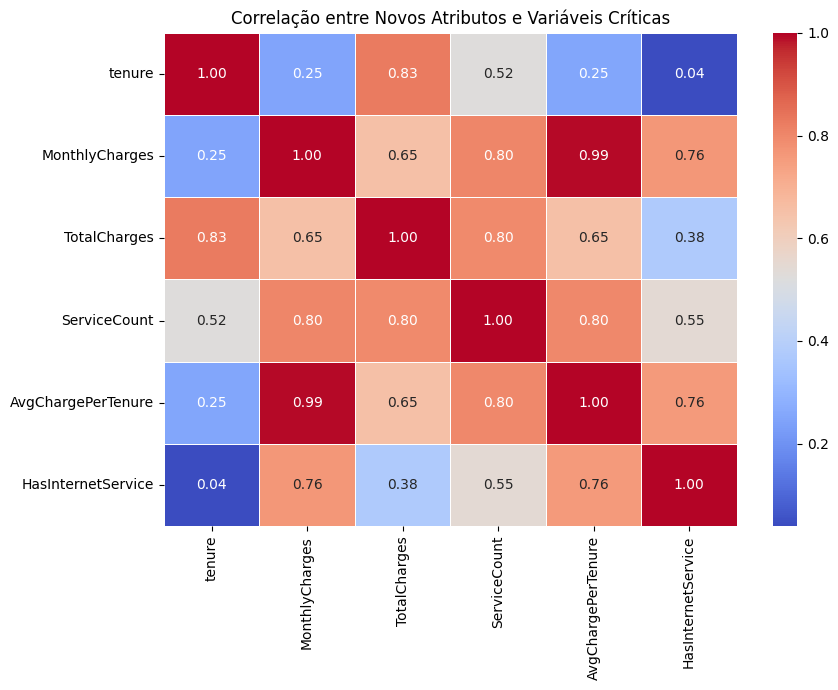

In [46]:
# Heatmap das novas variáveis e variáveis críticas

import seaborn as sns
import matplotlib.pyplot as plt

figures_path = Path("reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(9, 7))

sns.heatmap(
    correlation_new_features,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlação entre Novos Atributos e Variáveis Críticas")
plt.tight_layout()

plt.savefig(figures_path / "heatmap_novos_atributos_variaveis_criticas.png", dpi=300)

plt.show()

In [47]:
# Correlações das novas variáveis ordenadas

correlation_pairs = correlation_new_features.unstack().reset_index()
correlation_pairs.columns = ["Variável 1", "Variável 2", "Correlação"]

# Remover autocorrelações
correlation_pairs = correlation_pairs[
    correlation_pairs["Variável 1"] != correlation_pairs["Variável 2"]
]

# Manter apenas pares que envolvem novas variáveis
correlation_pairs = correlation_pairs[
    correlation_pairs["Variável 1"].isin(new_features) |
    correlation_pairs["Variável 2"].isin(new_features)
]

# Remover duplicados
correlation_pairs["Par"] = correlation_pairs.apply(
    lambda row: tuple(sorted([row["Variável 1"], row["Variável 2"]])),
    axis=1
)

correlation_pairs = correlation_pairs.drop_duplicates("Par").drop(columns="Par")

# Ordenar por valor absoluto
correlation_pairs["Correlação Absoluta"] = correlation_pairs["Correlação"].abs()

correlation_pairs = correlation_pairs.sort_values(
    by="Correlação Absoluta",
    ascending=False
)

display(correlation_pairs)

,Variável 1,Variável 2,Correlação,Correlação Absoluta
10,MonthlyCharges,AvgChargePerTenure,0.994355,0.994355
9,MonthlyCharges,ServiceCount,0.802322,0.802322
22,ServiceCount,AvgChargePerTenure,0.797374,0.797374
15,TotalCharges,ServiceCount,0.795854,0.795854
11,MonthlyCharges,HasInternetService,0.763557,0.763557
29,AvgChargePerTenure,HasInternetService,0.758465,0.758465
16,TotalCharges,AvgChargePerTenure,0.651435,0.651435
23,ServiceCount,HasInternetService,0.545546,0.545546
3,tenure,ServiceCount,0.523600,0.523600
17,TotalCharges,HasInternetService,0.375223,0.375223


In [48]:
# Relação das novas variáveis com variáveis categóricas relevantes

categorical_reference_vars = [
    "Contract",
    "InternetService",
    "PaymentMethod"
]

categorical_reference_vars = [
    col for col in categorical_reference_vars if col in df_m2.columns
]

for cat_col in categorical_reference_vars:
    print(f"\nMédia das novas variáveis por categoria de {cat_col}:")
    
    group_summary = df_m2.groupby(cat_col)[new_features].mean().round(2)
    
    display(group_summary)


Média das novas variáveis por categoria de Contract:


,ServiceCount,AvgChargePerTenure,HasInternetService
Contract,,,
Month-to-month,2.84,66.38,0.86
One year,3.82,65.06,0.75
Two year,4.17,60.54,0.62



Média das novas variáveis por categoria de InternetService:


,ServiceCount,AvgChargePerTenure,HasInternetService
InternetService,,,
DSL,3.67,57.98,1.0
Fiber optic,4.18,91.46,1.0
No,1.22,21.05,0.0



Média das novas variáveis por categoria de PaymentMethod:


,ServiceCount,AvgChargePerTenure,HasInternetService
PaymentMethod,,,
Bank transfer (automatic),3.85,67.09,0.78
Credit card (automatic),3.88,66.48,0.78
Electronic check,3.47,76.26,0.95
Mailed check,2.26,43.76,0.54


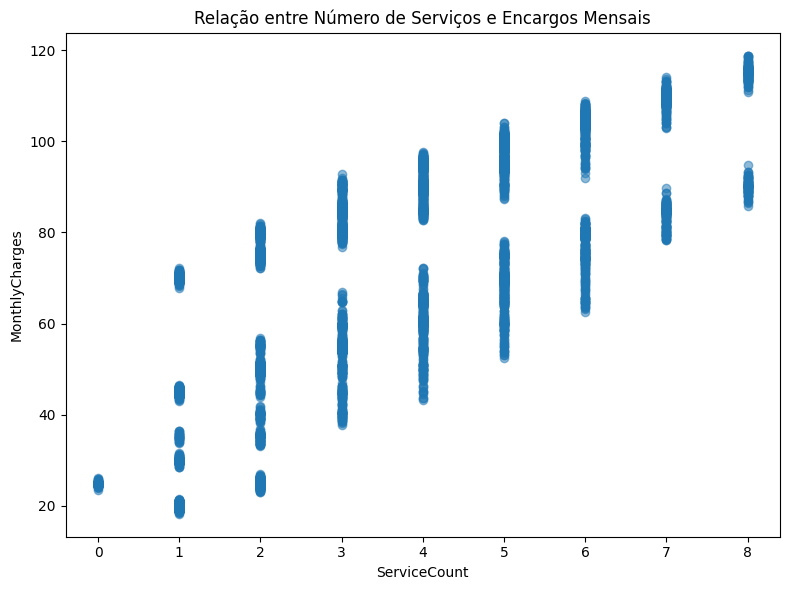

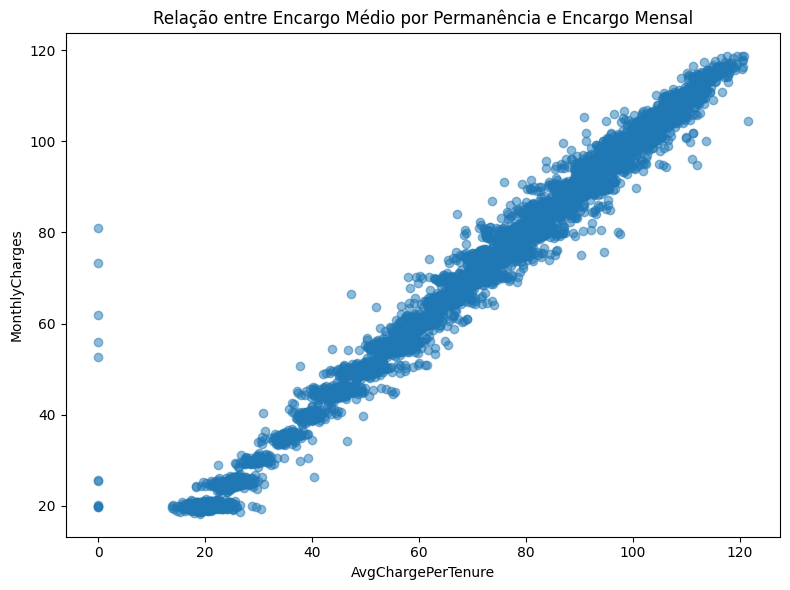

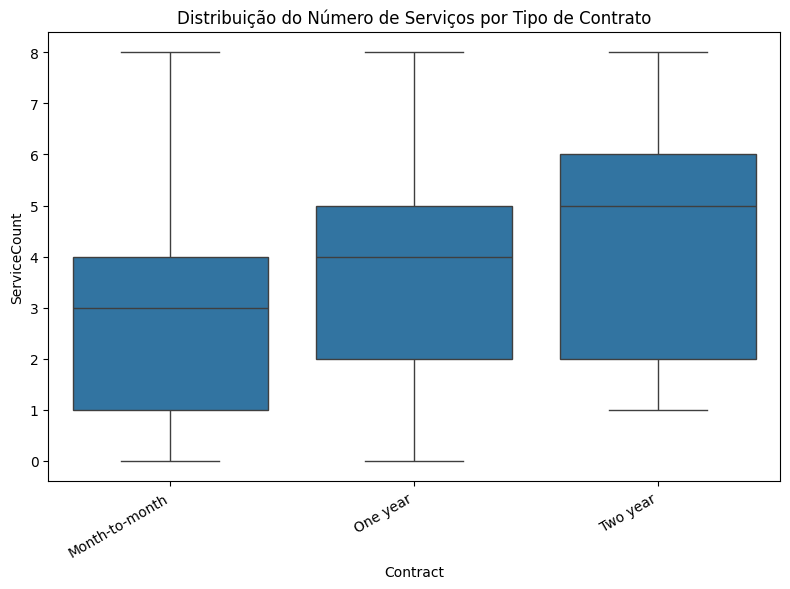

In [49]:
# Scatter plot: ServiceCount vs MonthlyCharges

plt.figure(figsize=(8, 6))

plt.scatter(
    df_m2["ServiceCount"],
    df_m2["MonthlyCharges"],
    alpha=0.5
)

plt.title("Relação entre Número de Serviços e Encargos Mensais")
plt.xlabel("ServiceCount")
plt.ylabel("MonthlyCharges")
plt.tight_layout()

plt.savefig(figures_path / "scatter_servicecount_monthlycharges.png", dpi=300)

plt.show()


# Scatter plot: AvgChargePerTenure vs MonthlyCharges

plt.figure(figsize=(8, 6))

plt.scatter(
    df_m2["AvgChargePerTenure"],
    df_m2["MonthlyCharges"],
    alpha=0.5
)

plt.title("Relação entre Encargo Médio por Permanência e Encargo Mensal")
plt.xlabel("AvgChargePerTenure")
plt.ylabel("MonthlyCharges")
plt.tight_layout()

plt.savefig(figures_path / "scatter_avgchargepertenure_monthlycharges.png", dpi=300)

plt.show()


# Boxplot: ServiceCount por Contract

if "Contract" in df_m2.columns:
    plt.figure(figsize=(8, 6))
    
    sns.boxplot(
        data=df_m2,
        x="Contract",
        y="ServiceCount"
    )
    
    plt.title("Distribuição do Número de Serviços por Tipo de Contrato")
    plt.xlabel("Contract")
    plt.ylabel("ServiceCount")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    
    plt.savefig(figures_path / "boxplot_servicecount_contract.png", dpi=300)
    
    plt.show()

In [50]:
# Guardar dataset com novos atributos

processed_path = Path("data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

output_file = processed_path / "telco_customer_churn_m2_novos_atributos.csv"

df_m2.to_csv(output_file, index=False)

print(f"Dataset com novos atributos guardado em: {output_file}")
print(f"Dimensão final: {df_m2.shape[0]} linhas e {df_m2.shape[1]} colunas")

Dataset com novos atributos guardado em: data/processed/telco_customer_churn_m2_novos_atributos.csv
Dimensão final: 7043 linhas e 28 colunas


### Síntese da criação de novos atributos

Foram criadas novas variáveis com o objetivo de enriquecer a análise de segmentação:

- `ServiceCount`, que representa o número de serviços subscritos pelo cliente;
- `AvgChargePerTenure`, que representa o valor médio acumulado por mês de permanência;
- `HasInternetService`, que identifica se o cliente possui ou não serviço de internet.

Estas variáveis estão alinhadas com o Objetivo SMART, porque ajudam a caracterizar perfis de clientes com base em serviços subscritos, consumo e relação com a empresa.

Após a análise de correlação, observou-se que:

- `ServiceCount` apresentou maior relação com `[preencher com variável]`, com correlação de `[preencher]`;
- `AvgChargePerTenure` apresentou maior relação com `[preencher com variável]`, com correlação de `[preencher]`;
- `HasInternetService` apresentou maior relação com `[preencher com variável]`, com correlação de `[preencher]`.

Como o projeto é não supervisionado, estas variáveis não foram avaliadas contra uma variável-alvo. A sua utilidade será confirmada na fase de modelação, através da análise dos clusters, do Coeficiente de Silhueta e da capacidade de caracterizar os 3 perfis de clientes.

## 10. Seleção de Atributos — Feature Selection

Nesta fase é realizada a seleção final de atributos para a modelação não supervisionada.

Como o projeto não tem variável-alvo, a seleção de atributos não será feita com base na capacidade de prever uma classe. Em vez disso, serão mantidas variáveis alinhadas com o Objetivo SMART e removidas variáveis identificadoras, redundantes, constantes ou com correlação demasiado alta entre si.

A variável `customerID` será removida por ser apenas um identificador. A variável `Churn` também será excluída, uma vez que o objetivo do projeto não é prever abandono, mas sim identificar 3 perfis de clientes.

In [51]:
# Seleção de Atributos — Preparação inicial

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.preprocessing import StandardScaler

# Garantir que existe uma cópia da Milestone 2
try:
    df_m2
except NameError:
    df_m2 = df.copy()

# Criar pasta para figuras e dados processados
figures_path = Path("reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

processed_path = Path("data/processed")
processed_path.mkdir(parents=True, exist_ok=True)

# Garantir que TotalCharges está em formato numérico
df_m2["TotalCharges"] = pd.to_numeric(df_m2["TotalCharges"], errors="coerce")

# Tratar TotalCharges em falta quando tenure = 0
condition_totalcharges_zero = df_m2["TotalCharges"].isna() & (df_m2["tenure"] == 0)
df_m2.loc[condition_totalcharges_zero, "TotalCharges"] = 0

# Caso ainda existam nulos, preencher com mediana
if df_m2["TotalCharges"].isna().sum() > 0:
    df_m2["TotalCharges"] = df_m2["TotalCharges"].fillna(df_m2["TotalCharges"].median())

print("Dimensão inicial de df_m2:")
print(df_m2.shape)

print("\nTotal de valores em falta:")
print(df_m2.isna().sum().sum())

Dimensão inicial de df_m2:
(7043, 28)

Total de valores em falta:
0


In [52]:
# Garantir existência dos novos atributos

# Nova variável: ServiceCount
if "ServiceCount" not in df_m2.columns:
    service_columns = [
        "PhoneService",
        "MultipleLines",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies"
    ]

    service_columns = [col for col in service_columns if col in df_m2.columns]

    df_m2["ServiceCount"] = 0

    for col in service_columns:
        df_m2["ServiceCount"] += (df_m2[col] == "Yes").astype(int)


# Nova variável: AvgChargePerTenure
if "AvgChargePerTenure" not in df_m2.columns:
    df_m2["AvgChargePerTenure"] = np.where(
        df_m2["tenure"] > 0,
        df_m2["TotalCharges"] / df_m2["tenure"],
        0
    )


# Nova variável: HasInternetService
if "HasInternetService" not in df_m2.columns and "InternetService" in df_m2.columns:
    df_m2["HasInternetService"] = np.where(
        df_m2["InternetService"] != "No",
        1,
        0
    )

new_features = [
    "ServiceCount",
    "AvgChargePerTenure",
    "HasInternetService"
]

new_features = [col for col in new_features if col in df_m2.columns]

print("Novos atributos disponíveis:")
print(new_features)

display(df_m2[new_features].head())

Novos atributos disponíveis:
['ServiceCount', 'AvgChargePerTenure', 'HasInternetService']


,ServiceCount,AvgChargePerTenure,HasInternetService
0,1,29.850000,1
1,3,55.573529,1
2,3,54.075000,1
3,3,40.905556,1
4,1,75.825000,1


In [53]:
# Seleção inicial de variáveis alinhadas com o Objetivo SMART

# Variáveis demográficas
demographic_vars = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents"
]

# Variáveis contratuais
contractual_vars = [
    "tenure",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod"
]

# Variáveis de serviços subscritos
service_vars = [
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

# Variáveis de consumo / valor económico
consumption_vars = [
    "MonthlyCharges",
    "TotalCharges"
]

# Novos atributos criados
engineered_vars = [
    "ServiceCount",
    "AvgChargePerTenure",
    "HasInternetService"
]

# Juntar todas as variáveis relevantes para segmentação
selected_vars = (
    demographic_vars
    + contractual_vars
    + service_vars
    + consumption_vars
    + engineered_vars
)

# Garantir que só entram colunas existentes no dataframe
selected_vars = [col for col in selected_vars if col in df_m2.columns]

# Remover variáveis que não entram na segmentação
selected_vars = [
    col for col in selected_vars
    if col not in ["customerID", "Churn"]
]

# Criar dataframe de atributos para feature selection
df_features = df_m2[selected_vars].copy()

print("Variáveis selecionadas para feature selection:")
print(selected_vars)

print("\nDimensão de df_features:")
print(df_features.shape)

display(df_features.head())

Variáveis selecionadas para feature selection:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MonthlyCharges', 'TotalCharges', 'ServiceCount', 'AvgChargePerTenure', 'HasInternetService']

Dimensão de df_features:
(7043, 22)


,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,PaperlessBilling,PaymentMethod,PhoneService,MultipleLines,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,MonthlyCharges,TotalCharges,ServiceCount,AvgChargePerTenure,HasInternetService
0,Female,0,Yes,No,1,Month-to-month,Yes,Electronic check,No,No phone service,...,Yes,No,No,No,No,29.85,29.85,1,29.850000,1
1,Male,0,No,No,34,One year,No,Mailed check,Yes,No,...,No,Yes,No,No,No,56.95,1889.50,3,55.573529,1
2,Male,0,No,No,2,Month-to-month,Yes,Mailed check,Yes,No,...,Yes,No,No,No,No,53.85,108.15,3,54.075000,1
3,Male,0,No,No,45,One year,No,Bank transfer (automatic),No,No phone service,...,No,Yes,Yes,No,No,42.30,1840.75,3,40.905556,1
4,Female,0,No,No,2,Month-to-month,Yes,Electronic check,Yes,No,...,No,No,No,No,No,70.70,151.65,1,75.825000,1


In [54]:
# One-Hot Encoding com redução de redundância

categorical_features = df_features.select_dtypes(include=["object"]).columns.tolist()

print("Variáveis categóricas para One-Hot Encoding:")
print(categorical_features)

df_encoded = pd.get_dummies(
    df_features,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

print("\nDimensão antes do One-Hot Encoding:")
print(df_features.shape)

print("\nDimensão depois do One-Hot Encoding:")
print(df_encoded.shape)

display(df_encoded.head())

Variáveis categóricas para One-Hot Encoding:
['gender', 'Partner', 'Dependents', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

Dimensão antes do One-Hot Encoding:
(7043, 22)

Dimensão depois do One-Hot Encoding:
(7043, 33)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ServiceCount,AvgChargePerTenure,HasInternetService,gender_Male,Partner_Yes,Dependents_Yes,...,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes
0,0,1,29.85,29.85,1,29.850000,1,0,1,0,...,0,1,0,0,0,0,0,0,0,0
1,0,34,56.95,1889.50,3,55.573529,1,1,0,0,...,0,0,0,1,0,0,0,0,0,0
2,0,2,53.85,108.15,3,54.075000,1,1,0,0,...,0,1,0,0,0,0,0,0,0,0
3,0,45,42.30,1840.75,3,40.905556,1,1,0,0,...,0,0,0,1,0,1,0,0,0,0
4,0,2,70.70,151.65,1,75.825000,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [55]:
# Remoção de variáveis constantes

nunique = df_encoded.nunique()

constant_columns = nunique[nunique <= 1].index.tolist()

print("Colunas constantes removidas:")
print(constant_columns)

df_selected = df_encoded.drop(columns=constant_columns)

print("\nDimensão após remoção de colunas constantes:")
print(df_selected.shape)

Colunas constantes removidas:
[]

Dimensão após remoção de colunas constantes:
(7043, 33)


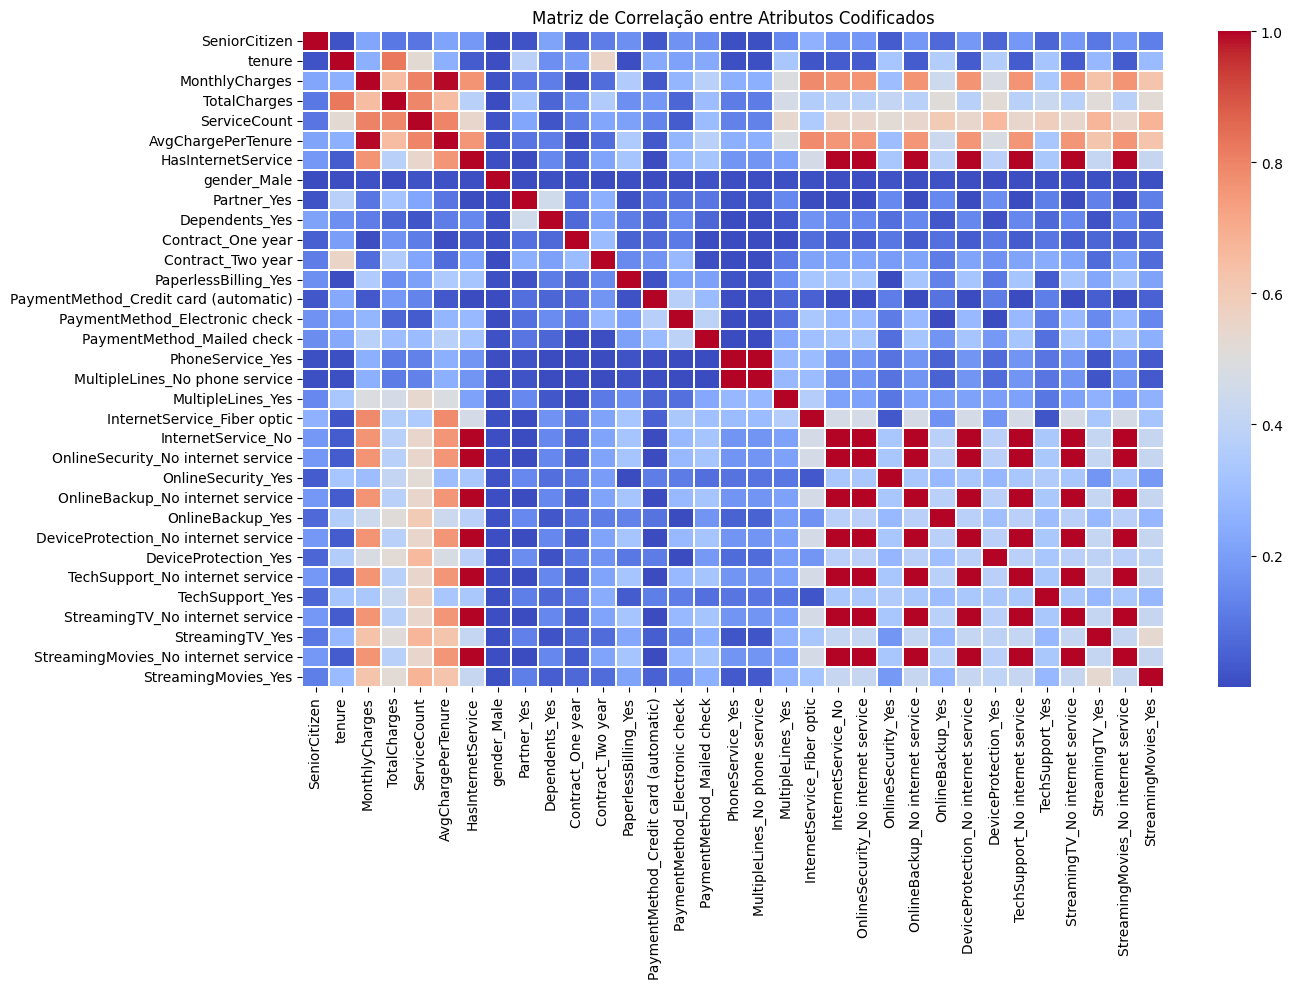

In [56]:
# Matriz de correlação para seleção de atributos

corr_matrix = df_selected.corr().abs()

plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    linewidths=0.2
)

plt.title("Matriz de Correlação entre Atributos Codificados")
plt.tight_layout()

plt.savefig(figures_path / "heatmap_feature_selection_correlacao.png", dpi=300)

plt.show()

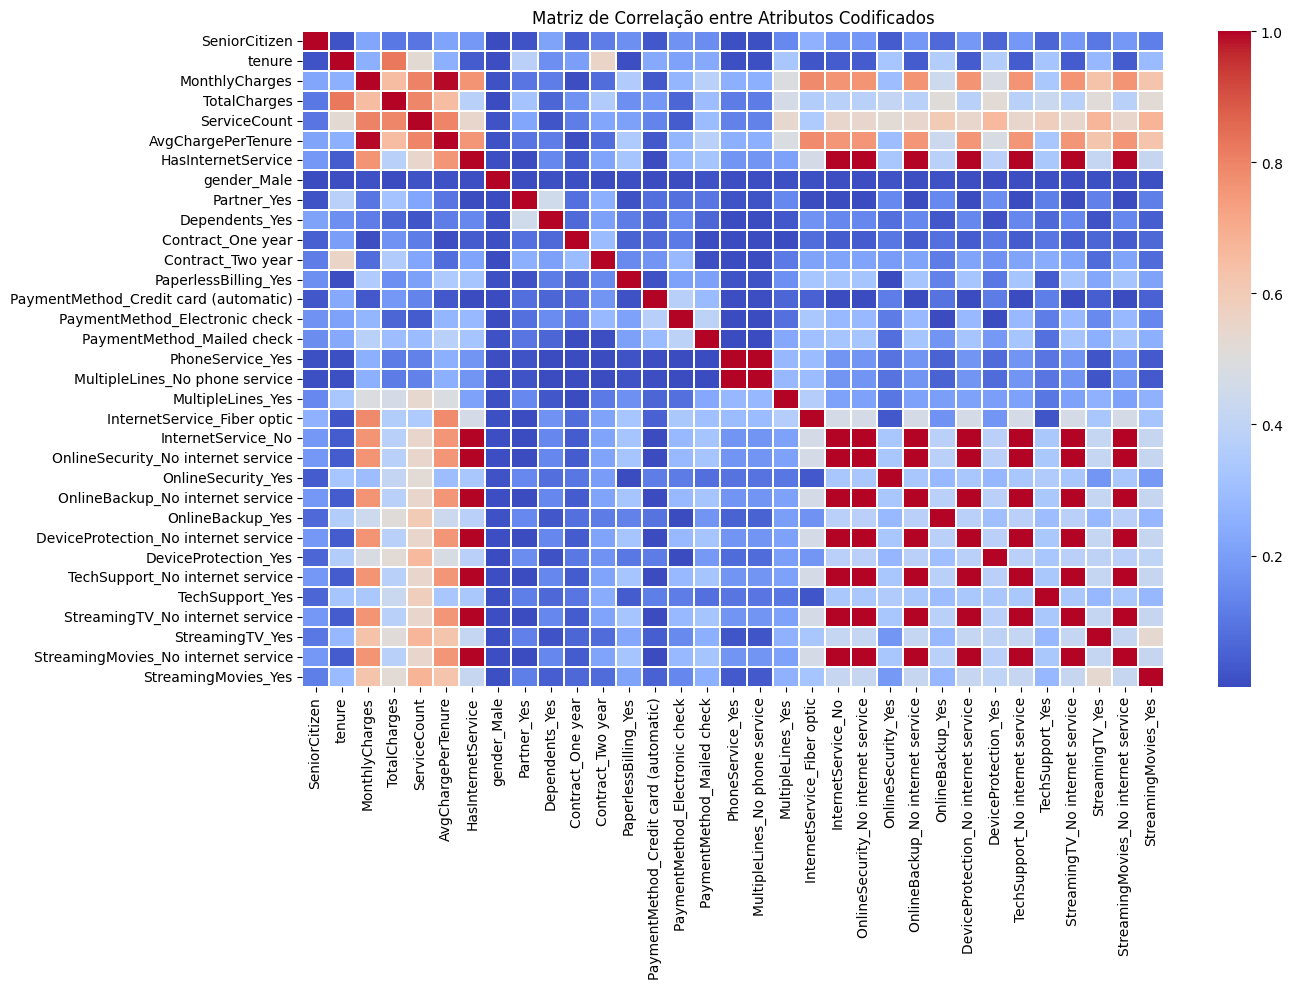

Pares com correlação elevada encontrados:


,Variável 1,Variável 2,Correlação absoluta
3,HasInternetService,OnlineSecurity_No internet service,1.000000
2,HasInternetService,InternetService_No,1.000000
5,HasInternetService,OnlineBackup_No internet service,1.000000
8,HasInternetService,DeviceProtection_No internet service,1.000000
12,HasInternetService,TechSupport_No internet service,1.000000
17,HasInternetService,StreamingTV_No internet service,1.000000
23,HasInternetService,StreamingMovies_No internet service,1.000000
4,InternetService_No,OnlineSecurity_No internet service,1.000000
9,InternetService_No,DeviceProtection_No internet service,1.000000
6,InternetService_No,OnlineBackup_No internet service,1.000000



Colunas removidas por correlação elevada:
['AvgChargePerTenure', 'MultipleLines_No phone service', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service']

Dimensão antes da remoção por correlação:
(7043, 33)

Dimensão depois da remoção por correlação:
(7043, 24)


In [57]:
# Correlação e remoção de variáveis com correlação elevada

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Garantir que a pasta de figuras existe
figures_path = Path("reports/figures")
figures_path.mkdir(parents=True, exist_ok=True)

# Limite de correlação definido para considerar redundância
correlation_threshold = 0.90

# Calcular matriz de correlação absoluta
corr_matrix = df_selected.corr().abs()

# Criar heatmap da matriz de correlação
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    linewidths=0.2
)

plt.title("Matriz de Correlação entre Atributos Codificados")
plt.tight_layout()

plt.savefig(figures_path / "heatmap_feature_selection_correlacao.png", dpi=300)

plt.show()

# Obter apenas a parte superior da matriz para evitar pares duplicados
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

# Identificar pares com correlação elevada
high_corr_pairs = []

for column in upper_triangle.columns:
    correlated_columns = upper_triangle.index[
        upper_triangle[column] > correlation_threshold
    ].tolist()
    
    for correlated_column in correlated_columns:
        high_corr_pairs.append({
            "Variável 1": correlated_column,
            "Variável 2": column,
            "Correlação absoluta": upper_triangle.loc[correlated_column, column]
        })

high_corr_pairs_df = pd.DataFrame(high_corr_pairs)

if len(high_corr_pairs_df) > 0:
    high_corr_pairs_df = high_corr_pairs_df.sort_values(
        by="Correlação absoluta",
        ascending=False
    )
    print("Pares com correlação elevada encontrados:")
    display(high_corr_pairs_df)
else:
    print(f"Não foram encontrados pares com correlação absoluta superior a {correlation_threshold}.")

# Remover uma das variáveis de cada par com correlação elevada
columns_to_drop_corr = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > correlation_threshold)
]

print("\nColunas removidas por correlação elevada:")
print(columns_to_drop_corr)

df_selected_no_corr = df_selected.drop(columns=columns_to_drop_corr)

print("\nDimensão antes da remoção por correlação:")
print(df_selected.shape)

print("\nDimensão depois da remoção por correlação:")
print(df_selected_no_corr.shape)

In [58]:
# Escalonamento dos atributos finais

df_final_features = df_selected_no_corr.copy()

# Variáveis contínuas/count que devem ser escalonadas se ainda existirem
continuous_features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ServiceCount",
    "AvgChargePerTenure"
]

continuous_features = [
    col for col in continuous_features
    if col in df_final_features.columns
]

scaler = StandardScaler()

df_final_features[continuous_features] = scaler.fit_transform(
    df_final_features[continuous_features]
)

print("Variáveis escalonadas:")
print(continuous_features)

print("\nDimensão final do dataset processado:")
print(df_final_features.shape)

display(df_final_features.head())

Variáveis escalonadas:
['tenure', 'MonthlyCharges', 'TotalCharges', 'ServiceCount']

Dimensão final do dataset processado:
(7043, 24)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ServiceCount,HasInternetService,gender_Male,Partner_Yes,Dependents_Yes,Contract_One year,...,PaymentMethod_Mailed check,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes
0,0,-1.277445,-1.160323,-0.992611,-1.145997,1,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0.066327,-0.259629,-0.172165,-0.176011,1,1,0,0,1,...,1,1,0,0,1,0,1,0,0,0
2,0,-1.236724,-0.362660,-0.958066,-0.176011,1,1,0,0,0,...,1,1,0,0,1,1,0,0,0,0
3,0,0.514251,-0.746535,-0.193672,-0.176011,1,1,0,0,1,...,0,0,0,0,1,0,1,1,0,0
4,0,-1.236724,0.197365,-0.938874,-1.145997,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0


In [59]:
# Validação final do dataset processado

non_numeric_cols = df_final_features.select_dtypes(exclude=[np.number]).columns.tolist()
missing_values = df_final_features.isna().sum().sum()

print("Colunas não numéricas no dataset final:")
print(non_numeric_cols)

print("\nTotal de valores em falta no dataset final:")
print(missing_values)

print("\nChurn está no dataset final?")
print("Churn" in df_final_features.columns)

print("\ncustomerID está no dataset final?")
print("customerID" in df_final_features.columns)

print("\nDimensão final:")
print(df_final_features.shape)

Colunas não numéricas no dataset final:
[]

Total de valores em falta no dataset final:
0

Churn está no dataset final?
False

customerID está no dataset final?
False

Dimensão final:
(7043, 24)


In [60]:
# Guardar dataset processado final

output_file = processed_path / "telco_customer_churn_m2_final_processado.csv"

df_final_features.to_csv(output_file, index=False)

print(f"Dataset processado guardado em: {output_file}")
print(f"Dimensão final: {df_final_features.shape[0]} linhas e {df_final_features.shape[1]} colunas")

# Guardar lista de atributos finais

features_file = processed_path / "lista_atributos_finais_m2.csv"

final_features_list = pd.DataFrame({
    "Atributo final": df_final_features.columns
})

final_features_list.to_csv(features_file, index=False)

print(f"Lista de atributos finais guardada em: {features_file}")

display(final_features_list)



# Guardar tabela de variáveis removidas

removed_features = pd.DataFrame({
    "Variável removida": constant_columns + columns_to_drop_corr,
    "Motivo": (
        ["Coluna constante"] * len(constant_columns)
        + ["Correlação elevada"] * len(columns_to_drop_corr)
    )
})

removed_features_file = processed_path / "atributos_removidos_m2.csv"

removed_features.to_csv(removed_features_file, index=False)

print(f"Tabela de atributos removidos guardada em: {removed_features_file}")

display(removed_features)

Dataset processado guardado em: data/processed/telco_customer_churn_m2_final_processado.csv
Dimensão final: 7043 linhas e 24 colunas
Lista de atributos finais guardada em: data/processed/lista_atributos_finais_m2.csv


,Atributo final
0,SeniorCitizen
1,tenure
2,MonthlyCharges
3,TotalCharges
4,ServiceCount
5,HasInternetService
6,gender_Male
7,Partner_Yes
8,Dependents_Yes
9,Contract_One year


Tabela de atributos removidos guardada em: data/processed/atributos_removidos_m2.csv


,Variável removida,Motivo
0,AvgChargePerTenure,Correlação elevada
1,MultipleLines_No phone service,Correlação elevada
2,InternetService_No,Correlação elevada
3,OnlineSecurity_No internet service,Correlação elevada
4,OnlineBackup_No internet service,Correlação elevada
5,DeviceProtection_No internet service,Correlação elevada
6,TechSupport_No internet service,Correlação elevada
7,StreamingTV_No internet service,Correlação elevada
8,StreamingMovies_No internet service,Correlação elevada


# Milestone 3 — Modelação e Avaliação

## 1. Configuração e Baseline

Nesta fase inicia-se a modelação do projeto, seguindo a abordagem não supervisionada definida no Objetivo SMART.  
Como o objetivo é segmentar clientes em perfis, a técnica escolhida é **Clustering**.

Nesta primeira experiência será criado um modelo baseline com K-Means, para servir como ponto de comparação com modelos ou configurações posteriores.

In [61]:
# Milestone 3 — Configuração inicial

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.decomposition import PCA

# Pastas do projeto
processed_path = Path("data/processed")
figures_path = Path("reports/figures")

processed_path.mkdir(parents=True, exist_ok=True)
figures_path.mkdir(parents=True, exist_ok=True)

# Garantir que o dataset processado da M2 existe
try:
    X = df_final_features.copy()
    print("Dataset carregado a partir da variável df_final_features.")
except NameError:
    X = pd.read_csv(processed_path / "telco_customer_churn_m2_final_processado.csv")
    print("Dataset carregado a partir do ficheiro CSV processado da M2.")

print("Dimensão do dataset para modelação:")
print(X.shape)

print("\nTotal de valores em falta:")
print(X.isna().sum().sum())

print("\nColunas não numéricas:")
print(X.select_dtypes(exclude=[np.number]).columns.tolist())

print("\nChurn está no dataset de modelação?")
print("Churn" in X.columns)

print("\ncustomerID está no dataset de modelação?")
print("customerID" in X.columns)

display(X.head())

Dataset carregado a partir da variável df_final_features.
Dimensão do dataset para modelação:
(7043, 24)

Total de valores em falta:
0

Colunas não numéricas:
[]

Churn está no dataset de modelação?
False

customerID está no dataset de modelação?
False


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,ServiceCount,HasInternetService,gender_Male,Partner_Yes,Dependents_Yes,Contract_One year,...,PaymentMethod_Mailed check,PhoneService_Yes,MultipleLines_Yes,InternetService_Fiber optic,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes
0,0,-1.277445,-1.160323,-0.992611,-1.145997,1,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0,0.066327,-0.259629,-0.172165,-0.176011,1,1,0,0,1,...,1,1,0,0,1,0,1,0,0,0
2,0,-1.236724,-0.362660,-0.958066,-0.176011,1,1,0,0,0,...,1,1,0,0,1,1,0,0,0,0
3,0,0.514251,-0.746535,-0.193672,-0.176011,1,1,0,0,1,...,0,0,0,0,1,0,1,1,0,0
4,0,-1.236724,0.197365,-0.938874,-1.145997,1,0,0,0,0,...,0,1,0,1,0,0,0,0,0,0


## 1.1. Estratégia de Validação

Como se trata de um problema não supervisionado, não existe uma variável-alvo para prever.  
Por isso, a divisão dos dados em treino e teste não tem o mesmo significado de um problema supervisionado.

A divisão 80/20 será usada apenas para verificar se a estrutura dos clusters se mantém estável em diferentes amostras dos dados.  
O modelo será ajustado no conjunto de treino e depois aplicado ao conjunto de teste, permitindo comparar métricas de coesão e separação.

In [62]:
# Divisão treino/teste para avaliação de estabilidade dos clusters

X_train, X_test = train_test_split(
    X,
    test_size=0.20,
    random_state=42,
    shuffle=True
)

print("Dimensão do conjunto de treino:")
print(X_train.shape)

print("\nDimensão do conjunto de teste:")
print(X_test.shape)

print("\nPercentagem usada para treino:")
print(round(len(X_train) / len(X) * 100, 2), "%")

print("\nPercentagem usada para teste:")
print(round(len(X_test) / len(X) * 100, 2), "%")

Dimensão do conjunto de treino:
(5634, 24)

Dimensão do conjunto de teste:
(1409, 24)

Percentagem usada para treino:
79.99 %

Percentagem usada para teste:
20.01 %


## 1.2. Métricas de Desempenho

Como o problema é de clustering, as métricas escolhidas avaliam a qualidade da formação dos grupos:

- **Silhouette Score:** métrica principal, pois avalia simultaneamente a coesão interna dos clusters e a separação entre clusters;
- **Davies-Bouldin Index:** métrica complementar, em que valores mais baixos indicam melhor separação;
- **Calinski-Harabasz Score:** métrica complementar, em que valores mais altos indicam clusters mais bem definidos;
- **Inércia:** mede a soma das distâncias quadráticas dos pontos aos centros dos clusters, sendo útil para comparação interna em modelos K-Means.

In [63]:
# Funções auxiliares para avaliação dos clusters

def calcular_inercia_manual(X_data, labels, centers):
    """
    Calcula a inércia para dados aos quais já foram atribuídos clusters.
    É útil para calcular uma inércia aproximada no conjunto de teste.
    """
    X_array = np.asarray(X_data)
    inertia = 0
    
    for cluster_id in np.unique(labels):
        cluster_points = X_array[labels == cluster_id]
        center = centers[cluster_id]
        inertia += np.sum((cluster_points - center) ** 2)
    
    return inertia


def avaliar_clusters(X_data, labels, centers=None):
    """
    Calcula métricas de avaliação para clustering.
    """
    n_clusters = len(np.unique(labels))
    
    if n_clusters < 2:
        raise ValueError("É necessário existir pelo menos 2 clusters para calcular as métricas.")
    
    resultados = {
        "n_clusters": n_clusters,
        "Silhouette Score": silhouette_score(X_data, labels),
        "Davies-Bouldin Index": davies_bouldin_score(X_data, labels),
        "Calinski-Harabasz Score": calinski_harabasz_score(X_data, labels)
    }
    
    if centers is not None:
        resultados["Inércia"] = calcular_inercia_manual(X_data, labels, centers)
    
    return resultados


def resumo_dimensao_clusters(labels):
    """
    Cria uma tabela com número e percentagem de clientes por cluster.
    """
    labels_series = pd.Series(labels, name="Cluster")
    
    resumo = labels_series.value_counts().sort_index().reset_index()
    resumo.columns = ["Cluster", "Nº de clientes"]
    
    resumo["Percentagem (%)"] = (
        resumo["Nº de clientes"] / resumo["Nº de clientes"].sum() * 100
    ).round(2)
    
    return resumo

## 2.1. Modelo Baseline — K-Means

O modelo baseline escolhido foi o **K-Means com 3 clusters**, porque o Objetivo SMART do projeto pretende identificar 3 perfis de clientes.

Este modelo é simples, interpretável e adequado como ponto de partida para comparar experiências futuras com outros algoritmos ou diferentes configurações de hiperparâmetros.

In [64]:
# Modelo Baseline — K-Means com 3 clusters

baseline_kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

# Treino no conjunto de treino
baseline_kmeans.fit(X_train)

# Atribuição de clusters
train_labels = baseline_kmeans.labels_
test_labels = baseline_kmeans.predict(X_test)

# Avaliação no treino e no teste
baseline_train_metrics = avaliar_clusters(
    X_train,
    train_labels,
    centers=baseline_kmeans.cluster_centers_
)

baseline_test_metrics = avaliar_clusters(
    X_test,
    test_labels,
    centers=baseline_kmeans.cluster_centers_
)

# Tabela comparativa
baseline_results = pd.DataFrame([
    {"Conjunto": "Treino", **baseline_train_metrics},
    {"Conjunto": "Teste", **baseline_test_metrics}
])

baseline_results = baseline_results.round(4)

display(baseline_results)

# Guardar resultados
baseline_results.to_csv(
    processed_path / "m3_baseline_kmeans_train_test_metrics.csv",
    index=False
)

,Conjunto,n_clusters,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Inércia
0,Treino,3,0.2151,1.6238,2187.4128,25631.3821
1,Teste,3,0.2194,1.5860,547.2395,6431.5630


In [65]:
# Distribuição dos clusters no treino

cluster_train_summary = resumo_dimensao_clusters(train_labels)

print("Distribuição dos clusters — Treino")
display(cluster_train_summary)

# Distribuição dos clusters no teste

cluster_test_summary = resumo_dimensao_clusters(test_labels)

print("Distribuição dos clusters — Teste")
display(cluster_test_summary)

# Guardar tabelas
cluster_train_summary.to_csv(
    processed_path / "m3_baseline_kmeans_train_cluster_sizes.csv",
    index=False
)

cluster_test_summary.to_csv(
    processed_path / "m3_baseline_kmeans_test_cluster_sizes.csv",
    index=False
)

Distribuição dos clusters — Treino


,Cluster,Nº de clientes,Percentagem (%)
0,0,1740,30.88
1,1,1814,32.20
2,2,2080,36.92


Distribuição dos clusters — Teste


,Cluster,Nº de clientes,Percentagem (%)
0,0,424,30.09
1,1,450,31.94
2,2,535,37.97


In [66]:
# Baseline ajustado ao dataset completo para análise global dos perfis

baseline_kmeans_full = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

full_labels = baseline_kmeans_full.fit_predict(X)

# Métricas globais
baseline_full_metrics = avaliar_clusters(
    X,
    full_labels,
    centers=baseline_kmeans_full.cluster_centers_
)

baseline_full_metrics_df = pd.DataFrame([baseline_full_metrics]).round(4)

print("Métricas do Baseline no dataset completo:")
display(baseline_full_metrics_df)

# Distribuição global dos clusters
cluster_full_summary = resumo_dimensao_clusters(full_labels)

print("Distribuição global dos clusters:")
display(cluster_full_summary)

# Guardar resultados
baseline_full_metrics_df.to_csv(
    processed_path / "m3_baseline_kmeans_full_metrics.csv",
    index=False
)

cluster_full_summary.to_csv(
    processed_path / "m3_baseline_kmeans_full_cluster_sizes.csv",
    index=False
)

# Criar dataset com o cluster atribuído
df_clusters_baseline = X.copy()
df_clusters_baseline["Cluster_Baseline"] = full_labels

df_clusters_baseline.to_csv(
    processed_path / "m3_baseline_kmeans_clusters.csv",
    index=False
)

print("Dataset com clusters guardado.")

Métricas do Baseline no dataset completo:


,n_clusters,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Score,Inércia
0,3,0.2161,1.6154,2734.0298,32059.2893


Distribuição global dos clusters:


,Cluster,Nº de clientes,Percentagem (%)
0,0,2171,30.82
1,1,2265,32.16
2,2,2607,37.02


Dataset com clusters guardado.


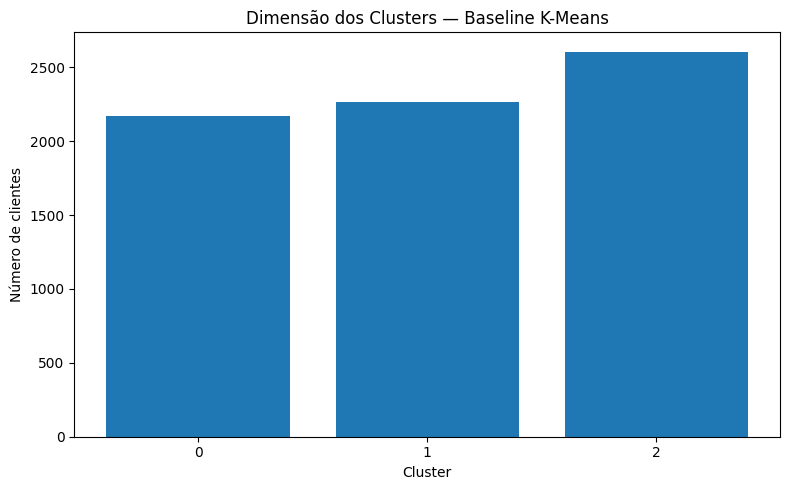

In [67]:
# Gráfico da dimensão dos clusters do baseline

plt.figure(figsize=(8, 5))

plt.bar(
    cluster_full_summary["Cluster"].astype(str),
    cluster_full_summary["Nº de clientes"]
)

plt.title("Dimensão dos Clusters — Baseline K-Means")
plt.xlabel("Cluster")
plt.ylabel("Número de clientes")
plt.tight_layout()

plt.savefig(
    figures_path / "m3_baseline_kmeans_dimensao_clusters.png",
    dpi=300
)

plt.show()

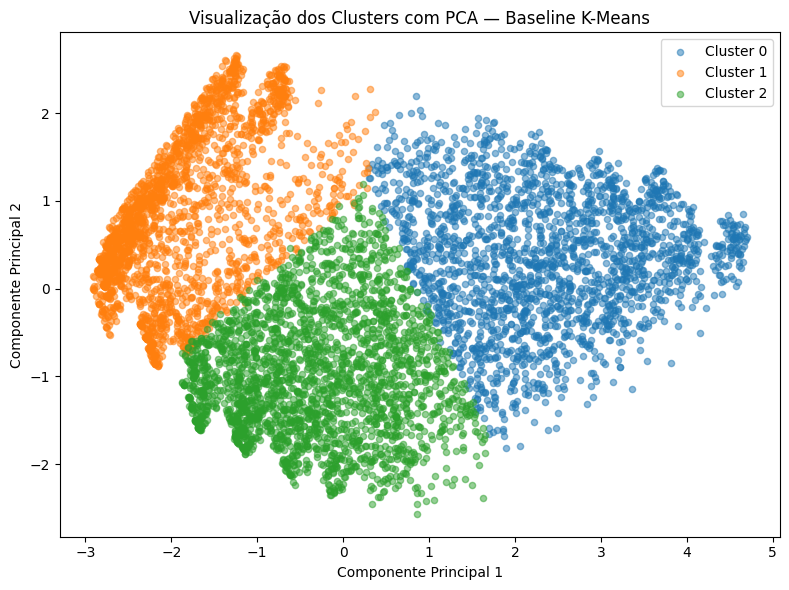

Variância explicada pelas duas primeiras componentes:
[0.45129927 0.14697828]

Variância explicada acumulada:
0.5983


In [68]:
# Visualização dos clusters em 2D com PCA

pca = PCA(n_components=2, random_state=42)

X_pca = pca.fit_transform(X)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Cluster": full_labels
})

plt.figure(figsize=(8, 6))

for cluster_id in sorted(pca_df["Cluster"].unique()):
    subset = pca_df[pca_df["Cluster"] == cluster_id]
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster_id}",
        alpha=0.5,
        s=20
    )

plt.title("Visualização dos Clusters com PCA — Baseline K-Means")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.tight_layout()

plt.savefig(
    figures_path / "m3_baseline_kmeans_pca_2d.png",
    dpi=300
)

plt.show()

print("Variância explicada pelas duas primeiras componentes:")
print(pca.explained_variance_ratio_)

print("\nVariância explicada acumulada:")
print(round(pca.explained_variance_ratio_.sum(), 4))

## 2.2. Modelos Candidatos

Depois da criação do modelo baseline com K-Means, foram testados vários algoritmos de clustering para avaliar se seria possível obter uma segmentação mais robusta.

Os algoritmos testados foram:

- **K-Means**, por ser o modelo base e interpretável;
- **MiniBatch K-Means**, por ser uma alternativa mais eficiente computacionalmente;
- **Agglomerative Clustering**, por permitir uma abordagem hierárquica;
- **DBSCAN**, por ser baseado em densidade e permitir identificar pontos considerados ruído.

A comparação foi feita com métricas adequadas a problemas não supervisionados: Silhouette Score, Davies-Bouldin Index e Calinski-Harabasz Score.

In [69]:
from sklearn.cluster import MiniBatchKMeans, AgglomerativeClustering, DBSCAN
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.metrics import silhouette_samples

def calcular_inercia_centros(X_data, labels, centers):
    """
    Calcula a inércia para modelos com centros, como K-Means e MiniBatch K-Means.
    Ignora label -1, caso exista ruído em algum modelo.
    """
    X_array = np.asarray(X_data)
    labels_array = np.asarray(labels)
    
    inertia = 0
    
    for cluster_id in np.unique(labels_array):
        if cluster_id == -1:
            continue
        
        cluster_points = X_array[labels_array == cluster_id]
        
        if cluster_id < len(centers):
            center = centers[cluster_id]
            inertia += np.sum((cluster_points - center) ** 2)
    
    return inertia


def avaliar_labels_cluster(X_data, labels, centers=None, sample_size=3000):
    """
    Avalia clustering com métricas de coesão e separação.
    Esta função é mais completa do que a função usada no baseline, porque também trata ruído do DBSCAN.
    """
    X_df = pd.DataFrame(X_data).reset_index(drop=True)
    labels_array = np.asarray(labels)
    
    noise_mask = labels_array == -1
    valid_mask = ~noise_mask
    
    X_valid = X_df.loc[valid_mask]
    labels_valid = labels_array[valid_mask]
    
    n_clusters = len(np.unique(labels_valid))
    ruido_pct = round(noise_mask.mean() * 100, 2)
    
    resultados = {
        "N_Clusters": n_clusters,
        "Ruido_%": ruido_pct,
        "Silhouette": np.nan,
        "Davies_Bouldin": np.nan,
        "Calinski_Harabasz": np.nan,
        "Inercia": np.nan,
        "Min_Cluster_%": np.nan
    }
    
    if n_clusters < 2 or len(X_valid) < 2:
        return resultados
    
    cluster_counts = pd.Series(labels_valid).value_counts()
    resultados["Min_Cluster_%"] = round(cluster_counts.min() / len(labels_array) * 100, 2)
    
    if len(X_valid) > sample_size:
        resultados["Silhouette"] = silhouette_score(
            X_valid,
            labels_valid,
            sample_size=sample_size,
            random_state=42
        )
    else:
        resultados["Silhouette"] = silhouette_score(X_valid, labels_valid)
    
    resultados["Davies_Bouldin"] = davies_bouldin_score(X_valid, labels_valid)
    resultados["Calinski_Harabasz"] = calinski_harabasz_score(X_valid, labels_valid)
    
    if centers is not None:
        resultados["Inercia"] = calcular_inercia_centros(X_df, labels_array, centers)
    
    return resultados


def avaliar_modelo_candidato(modelo_nome, parametros, X_train, X_test):
    """
    Treina e avalia um modelo candidato em treino e teste.
    """
    
    if modelo_nome == "KMeans":
        modelo = KMeans(**parametros)
        labels_train = modelo.fit_predict(X_train)
        labels_test = modelo.predict(X_test)
        centers = modelo.cluster_centers_
        tipo_aplicacao = "fit treino + predict teste"
    
    elif modelo_nome == "MiniBatchKMeans":
        modelo = MiniBatchKMeans(**parametros)
        labels_train = modelo.fit_predict(X_train)
        labels_test = modelo.predict(X_test)
        centers = modelo.cluster_centers_
        tipo_aplicacao = "fit treino + predict teste"
    
    elif modelo_nome == "Agglomerative":
        modelo_train = AgglomerativeClustering(**parametros)
        labels_train = modelo_train.fit_predict(X_train)
        
        modelo_test = AgglomerativeClustering(**parametros)
        labels_test = modelo_test.fit_predict(X_test)
        
        centers = None
        tipo_aplicacao = "fit separado no teste"
    
    elif modelo_nome == "DBSCAN":
        modelo_train = DBSCAN(**parametros)
        labels_train = modelo_train.fit_predict(X_train)
        
        modelo_test = DBSCAN(**parametros)
        labels_test = modelo_test.fit_predict(X_test)
        
        centers = None
        tipo_aplicacao = "fit separado no teste"
    
    else:
        raise ValueError("Modelo não reconhecido.")
    
    metricas_train = avaliar_labels_cluster(X_train, labels_train, centers=centers)
    metricas_test = avaliar_labels_cluster(X_test, labels_test, centers=centers)
    
    resultado_train = {
        "Modelo": modelo_nome,
        "Conjunto": "Treino",
        "Tipo_Aplicacao": tipo_aplicacao,
        **parametros,
        **metricas_train
    }
    
    resultado_test = {
        "Modelo": modelo_nome,
        "Conjunto": "Teste",
        "Tipo_Aplicacao": tipo_aplicacao,
        **parametros,
        **metricas_test
    }
    
    return resultado_train, resultado_test

In [70]:
# Definição dos modelos candidatos

espacos_modelos = {
    "KMeans": list(ParameterGrid({
        "n_clusters": [3, 4, 5, 6],
        "init": ["k-means++"],
        "n_init": [10, 20],
        "max_iter": [300],
        "random_state": [42]
    })),
    
    "MiniBatchKMeans": list(ParameterGrid({
        "n_clusters": [3, 4, 5, 6],
        "init": ["k-means++"],
        "n_init": [10],
        "batch_size": [512, 1024],
        "max_iter": [300],
        "random_state": [42]
    })),
    
    "Agglomerative": list(ParameterGrid({
        "n_clusters": [3, 4, 5, 6],
        "linkage": ["ward", "complete", "average"]
    })),
    
    "DBSCAN": list(ParameterGrid({
        "eps": [1.5, 2.0, 2.5, 3.0, 3.5],
        "min_samples": [5, 10, 20]
    }))
}

total_experiencias = sum(len(configs) for configs in espacos_modelos.values())

print("Total de experiências a executar:", total_experiencias)

for modelo_nome, configs in espacos_modelos.items():
    print(f"{modelo_nome}: {len(configs)} configurações")

Total de experiências a executar: 43
KMeans: 8 configurações
MiniBatchKMeans: 8 configurações
Agglomerative: 12 configurações
DBSCAN: 15 configurações


In [71]:
# Execução das experiências com modelos candidatos

resultados_experiencias = []

for modelo_nome, configs in espacos_modelos.items():
    print(f"\nA testar modelo: {modelo_nome}")
    
    for i, parametros in enumerate(configs, start=1):
        try:
            resultado_train, resultado_test = avaliar_modelo_candidato(
                modelo_nome=modelo_nome,
                parametros=parametros,
                X_train=X_train,
                X_test=X_test
            )
            
            resultados_experiencias.append(resultado_train)
            resultados_experiencias.append(resultado_test)
            
            print(f"  Experiência {i}/{len(configs)} concluída.")
        
        except Exception as e:
            print(f"  Erro em {modelo_nome}, experiência {i}/{len(configs)}: {e}")

resultados_experiencias_df = pd.DataFrame(resultados_experiencias)

colunas_metricas = [
    "Silhouette",
    "Davies_Bouldin",
    "Calinski_Harabasz",
    "Inercia",
    "Ruido_%",
    "Min_Cluster_%"
]

for coluna in colunas_metricas:
    if coluna in resultados_experiencias_df.columns:
        resultados_experiencias_df[coluna] = resultados_experiencias_df[coluna].round(4)

display(resultados_experiencias_df)

resultados_experiencias_df.to_csv(
    processed_path / "m3_modelos_candidatos_resultados_train_test.csv",
    index=False
)

print("Resultados dos modelos candidatos guardados.")


A testar modelo: KMeans
  Experiência 1/8 concluída.
  Experiência 2/8 concluída.
  Experiência 3/8 concluída.
  Experiência 4/8 concluída.
  Experiência 5/8 concluída.
  Experiência 6/8 concluída.
  Experiência 7/8 concluída.
  Experiência 8/8 concluída.

A testar modelo: MiniBatchKMeans
  Experiência 1/8 concluída.
  Experiência 2/8 concluída.
  Experiência 3/8 concluída.
  Experiência 4/8 concluída.
  Experiência 5/8 concluída.
  Experiência 6/8 concluída.
  Experiência 7/8 concluída.
  Experiência 8/8 concluída.

A testar modelo: Agglomerative
  Experiência 1/12 concluída.
  Experiência 2/12 concluída.
  Experiência 3/12 concluída.
  Experiência 4/12 concluída.
  Experiência 5/12 concluída.
  Experiência 6/12 concluída.
  Experiência 7/12 concluída.
  Experiência 8/12 concluída.
  Experiência 9/12 concluída.
  Experiência 10/12 concluída.
  Experiência 11/12 concluída.
  Experiência 12/12 concluída.

A testar modelo: DBSCAN
  Experiência 1/15 concluída.
  Experiência 2/15 concluíd

,Modelo,Conjunto,Tipo_Aplicacao,init,max_iter,n_clusters,n_init,random_state,N_Clusters,Ruido_%,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inercia,Min_Cluster_%,batch_size,linkage,eps,min_samples
0,KMeans,Treino,fit treino + predict teste,k-means++,300.0,3.0,10.0,42.0,3,0.0,0.2128,1.6238,2187.4128,25631.3821,30.88,NaN,NaN,NaN,NaN
1,KMeans,Teste,fit treino + predict teste,k-means++,300.0,3.0,10.0,42.0,3,0.0,0.2194,1.5860,547.2395,6431.5630,30.09,NaN,NaN,NaN,NaN
2,KMeans,Treino,fit treino + predict teste,k-means++,300.0,3.0,20.0,42.0,3,0.0,0.2128,1.6238,2187.4128,25631.3821,30.88,NaN,NaN,NaN,NaN
3,KMeans,Teste,fit treino + predict teste,k-means++,300.0,3.0,20.0,42.0,3,0.0,0.2194,1.5860,547.2395,6431.5630,30.09,NaN,NaN,NaN,NaN
4,KMeans,Treino,fit treino + predict teste,k-means++,300.0,4.0,10.0,42.0,4,0.0,0.1861,1.6656,1719.0109,23770.9072,14.34,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,DBSCAN,Teste,fit separado no teste,NaN,NaN,NaN,NaN,NaN,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.5,5.0
82,DBSCAN,Treino,fit separado no teste,NaN,NaN,NaN,NaN,NaN,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.5,10.0
83,DBSCAN,Teste,fit separado no teste,NaN,NaN,NaN,NaN,NaN,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.5,10.0
84,DBSCAN,Treino,fit separado no teste,NaN,NaN,NaN,NaN,NaN,1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.5,20.0


Resultados dos modelos candidatos guardados.


In [72]:
# Ranking dos modelos no conjunto de teste

ranking_teste = resultados_experiencias_df[
    resultados_experiencias_df["Conjunto"] == "Teste"
].copy()

ranking_teste_valido = ranking_teste[
    (ranking_teste["N_Clusters"] >= 3) &
    (ranking_teste["N_Clusters"] <= 6) &
    (ranking_teste["Min_Cluster_%"] >= 5) &
    (ranking_teste["Silhouette"].notna())
].copy()

if ranking_teste_valido.empty:
    print("Não houve modelos válidos após os filtros. Será mostrado o ranking sem filtro de dimensão mínima.")
    ranking_teste_valido = ranking_teste[
        ranking_teste["Silhouette"].notna()
    ].copy()

ranking_teste_valido = ranking_teste_valido.sort_values(
    by=["Silhouette", "Davies_Bouldin"],
    ascending=[False, True]
)

print("Ranking dos modelos candidatos no conjunto de teste:")
display(ranking_teste_valido.head(15))

ranking_teste_valido.to_csv(
    processed_path / "m3_ranking_modelos_candidatos_teste.csv",
    index=False
)

melhor_modelo_candidato = ranking_teste_valido.iloc[0]

print("Melhor modelo candidato no teste:")
display(melhor_modelo_candidato)

Ranking dos modelos candidatos no conjunto de teste:


,Modelo,Conjunto,Tipo_Aplicacao,init,max_iter,n_clusters,n_init,random_state,N_Clusters,Ruido_%,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inercia,Min_Cluster_%,batch_size,linkage,eps,min_samples
1,KMeans,Teste,fit treino + predict teste,k-means++,300.0,3.0,10.0,42.0,3,0.0,0.2194,1.5860,547.2395,6431.5630,30.09,NaN,NaN,NaN,NaN
3,KMeans,Teste,fit treino + predict teste,k-means++,300.0,3.0,20.0,42.0,3,0.0,0.2194,1.5860,547.2395,6431.5630,30.09,NaN,NaN,NaN,NaN
25,MiniBatchKMeans,Teste,fit treino + predict teste,k-means++,300.0,3.0,10.0,42.0,3,0.0,0.2191,1.5888,547.1260,6435.0907,30.23,1024.0,NaN,NaN,NaN
17,MiniBatchKMeans,Teste,fit treino + predict teste,k-means++,300.0,3.0,10.0,42.0,3,0.0,0.2188,1.5926,546.7840,6435.0061,30.38,512.0,NaN,NaN,NaN
49,Agglomerative,Teste,fit separado no teste,NaN,NaN,3.0,NaN,NaN,3,0.0,0.2025,1.5544,487.8959,NaN,25.34,NaN,average,NaN,NaN
33,Agglomerative,Teste,fit separado no teste,NaN,NaN,3.0,NaN,NaN,3,0.0,0.1985,1.5448,469.4592,NaN,22.14,NaN,ward,NaN,NaN
19,MiniBatchKMeans,Teste,fit treino + predict teste,k-means++,300.0,4.0,10.0,42.0,4,0.0,0.1907,1.6106,431.6223,5956.0594,13.84,512.0,NaN,NaN,NaN
5,KMeans,Teste,fit treino + predict teste,k-means++,300.0,4.0,10.0,42.0,4,0.0,0.1901,1.6150,431.3498,5957.1594,14.83,NaN,NaN,NaN,NaN
7,KMeans,Teste,fit treino + predict teste,k-means++,300.0,4.0,20.0,42.0,4,0.0,0.1901,1.6150,431.3498,5957.0932,14.83,NaN,NaN,NaN,NaN
51,Agglomerative,Teste,fit separado no teste,NaN,NaN,4.0,NaN,NaN,4,0.0,0.1772,1.8191,387.0049,NaN,12.49,NaN,average,NaN,NaN


Melhor modelo candidato no teste:


Modelo                                   KMeans
Conjunto                                  Teste
Tipo_Aplicacao       fit treino + predict teste
init                                  k-means++
max_iter                                  300.0
n_clusters                                  3.0
n_init                                     10.0
random_state                               42.0
N_Clusters                                    3
Ruido_%                                     0.0
Silhouette                               0.2194
Davies_Bouldin                            1.586
Calinski_Harabasz                      547.2395
Inercia                                6431.563
Min_Cluster_%                             30.09
batch_size                                  NaN
linkage                                     NaN
eps                                         NaN
min_samples                                 NaN
Name: 1, dtype: object

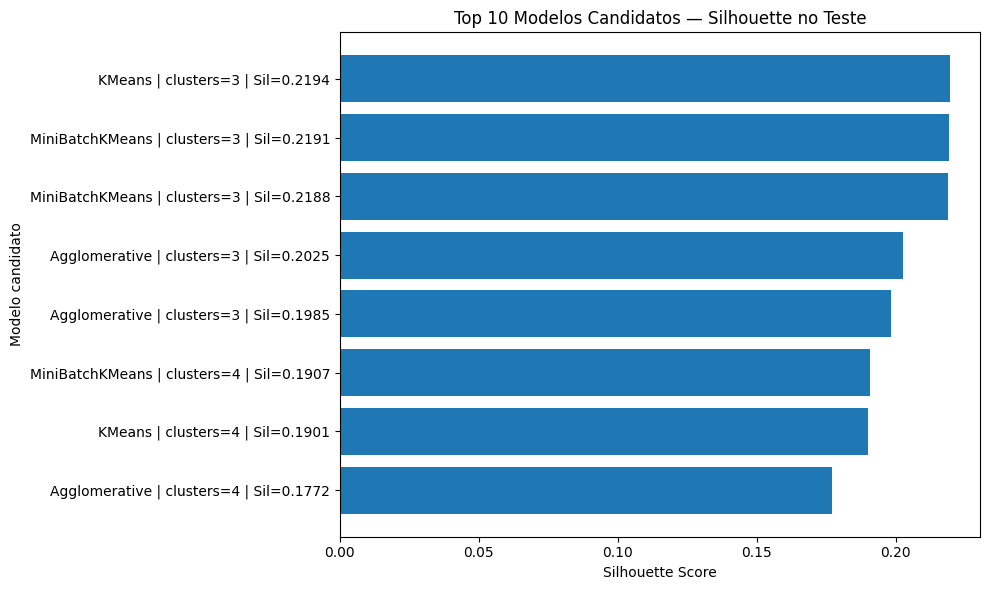

In [73]:
# Gráfico comparativo dos melhores modelos candidatos

top_modelos = ranking_teste_valido.head(10).copy()

top_modelos["Descricao"] = top_modelos.apply(
    lambda row: f"{row['Modelo']} | clusters={int(row['N_Clusters'])} | Sil={row['Silhouette']:.4f}",
    axis=1
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_modelos["Descricao"],
    top_modelos["Silhouette"]
)

plt.xlabel("Silhouette Score")
plt.ylabel("Modelo candidato")
plt.title("Top 10 Modelos Candidatos — Silhouette no Teste")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    figures_path / "m3_comparacao_modelos_candidatos_silhouette.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,k,Inercia
0,2,38178.774393
1,3,32059.289314
2,4,29723.982388
3,5,27700.622485
4,6,26227.012273
5,7,25224.882633
6,8,24276.240367
7,9,23630.674839
8,10,23102.942243


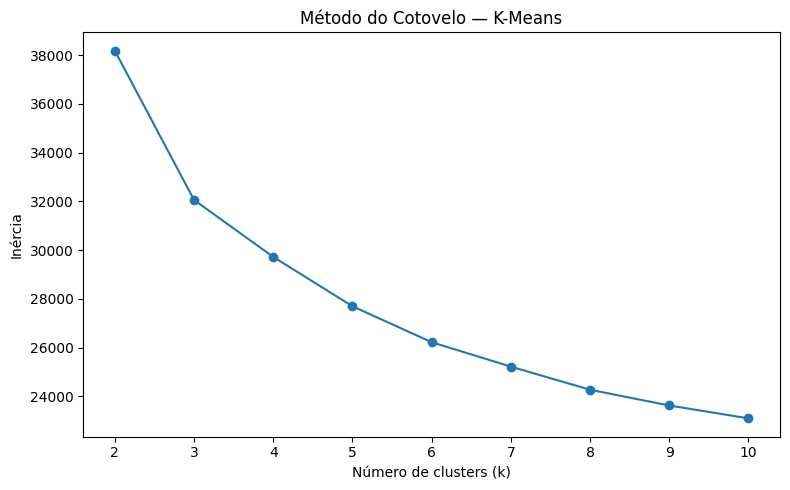

In [74]:
# Método do Cotovelo para K-Means

k_values = range(2, 11)
inertias = []

for k in k_values:
    modelo = KMeans(
        n_clusters=k,
        init="k-means++",
        n_init=10,
        max_iter=300,
        random_state=42
    )
    
    modelo.fit(X)
    inertias.append(modelo.inertia_)

elbow_df = pd.DataFrame({
    "k": list(k_values),
    "Inercia": inertias
})

display(elbow_df)

elbow_df.to_csv(
    processed_path / "m3_elbow_method_kmeans.csv",
    index=False
)

plt.figure(figsize=(8, 5))

plt.plot(
    elbow_df["k"],
    elbow_df["Inercia"],
    marker="o"
)

plt.title("Método do Cotovelo — K-Means")
plt.xlabel("Número de clusters (k)")
plt.ylabel("Inércia")
plt.xticks(list(k_values))
plt.tight_layout()

plt.savefig(
    figures_path / "m3_elbow_method_kmeans.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3. Otimização e Validação Cruzada

Após a comparação inicial dos modelos candidatos, foi realizada a otimização do K-Means.

A otimização foi feita com uma grelha manual de hiperparâmetros, testando diferentes valores de `n_clusters`, `init`, `n_init`, `max_iter` e `algorithm`.

Como o objetivo SMART do projeto prevê a identificação de 3 perfis de clientes, será analisada a melhor configuração geral e também a melhor configuração especificamente com 3 clusters.

A validação cruzada foi realizada com 5 folds, usando o Silhouette Score como métrica principal de estabilidade.

In [75]:
# Cross-Validation manual para K-Means

def cross_validate_kmeans(parametros, X_data, n_splits=5):
    """
    Validação cruzada manual para K-Means.
    Em cada fold, o modelo é treinado numa parte dos dados e avaliado na parte de validação.
    """
    
    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )
    
    resultados_folds = []
    
    X_reset = pd.DataFrame(X_data).reset_index(drop=True)
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_reset), start=1):
        X_fold_train = X_reset.iloc[train_idx]
        X_fold_val = X_reset.iloc[val_idx]
        
        modelo = KMeans(**parametros)
        modelo.fit(X_fold_train)
        
        labels_val = modelo.predict(X_fold_val)
        
        metricas = avaliar_labels_cluster(
            X_fold_val,
            labels_val,
            centers=modelo.cluster_centers_
        )
        
        resultados_folds.append({
            "Fold": fold,
            **parametros,
            **metricas
        })
    
    return pd.DataFrame(resultados_folds)


print("Função de Cross-Validation criada.")

Função de Cross-Validation criada.


In [76]:
# Grid Search manual para K-Means

grid_kmeans = list(ParameterGrid({
    "n_clusters": [3, 4, 5, 6],
    "init": ["k-means++", "random"],
    "n_init": [10, 20],
    "max_iter": [300, 500],
    "algorithm": ["lloyd", "elkan"],
    "random_state": [42]
}))

print("Total de configurações K-Means a testar:", len(grid_kmeans))

resultados_cv = []

for i, parametros in enumerate(grid_kmeans, start=1):
    try:
        resultado = cross_validate_kmeans(
            parametros=parametros,
            X_data=X,
            n_splits=5
        )
        
        resultados_cv.append(resultado)
        print(f"Configuração {i}/{len(grid_kmeans)} concluída.")
    
    except Exception as e:
        print(f"Erro na configuração {i}/{len(grid_kmeans)}: {e}")

resultados_cv_df = pd.concat(resultados_cv, ignore_index=True)

for coluna in colunas_metricas:
    if coluna in resultados_cv_df.columns:
        resultados_cv_df[coluna] = resultados_cv_df[coluna].round(4)

display(resultados_cv_df.head())

resultados_cv_df.to_csv(
    processed_path / "m3_kmeans_gridsearch_cv_folds.csv",
    index=False
)

print("Resultados por fold guardados.")

Total de configurações K-Means a testar: 64
Configuração 1/64 concluída.
Configuração 2/64 concluída.
Configuração 3/64 concluída.
Configuração 4/64 concluída.
Configuração 5/64 concluída.
Configuração 6/64 concluída.
Configuração 7/64 concluída.
Configuração 8/64 concluída.
Configuração 9/64 concluída.
Configuração 10/64 concluída.
Configuração 11/64 concluída.
Configuração 12/64 concluída.
Configuração 13/64 concluída.
Configuração 14/64 concluída.
Configuração 15/64 concluída.
Configuração 16/64 concluída.
Configuração 17/64 concluída.
Configuração 18/64 concluída.
Configuração 19/64 concluída.
Configuração 20/64 concluída.
Configuração 21/64 concluída.
Configuração 22/64 concluída.
Configuração 23/64 concluída.
Configuração 24/64 concluída.
Configuração 25/64 concluída.
Configuração 26/64 concluída.
Configuração 27/64 concluída.
Configuração 28/64 concluída.
Configuração 29/64 concluída.
Configuração 30/64 concluída.
Configuração 31/64 concluída.
Configuração 32/64 concluída.
Confi

,Fold,algorithm,init,max_iter,n_clusters,n_init,random_state,N_Clusters,Ruido_%,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inercia,Min_Cluster_%
0,1,lloyd,k-means++,300,3,10,42,3,0.0,0.2194,1.5860,547.2395,6431.5630,30.09
1,2,lloyd,k-means++,300,3,10,42,3,0.0,0.2105,1.6391,527.1316,6441.8946,30.38
2,3,lloyd,k-means++,300,3,10,42,3,0.0,0.2115,1.6273,528.3125,6476.6602,29.31
3,4,lloyd,k-means++,300,3,10,42,3,0.0,0.2166,1.6125,558.9058,6391.1068,29.55
4,5,lloyd,k-means++,300,3,10,42,3,0.0,0.2216,1.6001,573.9145,6350.0918,31.96


Resultados por fold guardados.


In [77]:
# Resumo da Cross-Validation

colunas_grupo = [
    "n_clusters",
    "init",
    "n_init",
    "max_iter",
    "algorithm",
    "random_state"
]

cv_resumo = resultados_cv_df.groupby(colunas_grupo).agg(
    Silhouette_Media=("Silhouette", "mean"),
    Silhouette_Desvio=("Silhouette", "std"),
    Davies_Bouldin_Media=("Davies_Bouldin", "mean"),
    Calinski_Harabasz_Media=("Calinski_Harabasz", "mean"),
    Inercia_Media=("Inercia", "mean"),
    Min_Cluster_Media=("Min_Cluster_%", "mean")
).reset_index()

cv_resumo = cv_resumo.round(4)

cv_resumo = cv_resumo.sort_values(
    by=["Silhouette_Media", "Davies_Bouldin_Media"],
    ascending=[False, True]
)

print("Top 15 configurações gerais:")
display(cv_resumo.head(15))

melhor_config_geral = cv_resumo.iloc[0]

print("Melhor configuração geral:")
display(melhor_config_geral)

cv_resumo_k3 = cv_resumo[cv_resumo["n_clusters"] == 3].copy()

melhor_config_k3 = cv_resumo_k3.iloc[0]

print("Melhor configuração com 3 clusters:")
display(melhor_config_k3)

cv_resumo.to_csv(
    processed_path / "m3_kmeans_gridsearch_cv_resumo.csv",
    index=False
)

Top 15 configurações gerais:


,n_clusters,init,n_init,max_iter,algorithm,random_state,Silhouette_Media,Silhouette_Desvio,Davies_Bouldin_Media,Calinski_Harabasz_Media,Inercia_Media,Min_Cluster_Media
12,3,random,20,300,elkan,42,0.2159,0.0049,1.6129,547.1060,6418.2650,30.258
13,3,random,20,300,lloyd,42,0.2159,0.0049,1.6129,547.1060,6418.2650,30.258
14,3,random,20,500,elkan,42,0.2159,0.0049,1.6129,547.1060,6418.2650,30.258
15,3,random,20,500,lloyd,42,0.2159,0.0049,1.6129,547.1060,6418.2650,30.258
0,3,k-means++,10,300,elkan,42,0.2159,0.0048,1.6130,547.1008,6418.2633,30.258
1,3,k-means++,10,300,lloyd,42,0.2159,0.0048,1.6130,547.1008,6418.2633,30.258
2,3,k-means++,10,500,elkan,42,0.2159,0.0048,1.6130,547.1008,6418.2633,30.258
3,3,k-means++,10,500,lloyd,42,0.2159,0.0048,1.6130,547.1008,6418.2633,30.258
4,3,k-means++,20,300,elkan,42,0.2159,0.0048,1.6130,547.1008,6418.2286,30.258
5,3,k-means++,20,300,lloyd,42,0.2159,0.0048,1.6130,547.1008,6418.2286,30.258


Melhor configuração geral:


n_clusters                        3
init                         random
n_init                           20
max_iter                        300
algorithm                     elkan
random_state                     42
Silhouette_Media             0.2159
Silhouette_Desvio            0.0049
Davies_Bouldin_Media         1.6129
Calinski_Harabasz_Media     547.106
Inercia_Media              6418.265
Min_Cluster_Media            30.258
Name: 12, dtype: object

Melhor configuração com 3 clusters:


n_clusters                        3
init                         random
n_init                           20
max_iter                        300
algorithm                     elkan
random_state                     42
Silhouette_Media             0.2159
Silhouette_Desvio            0.0049
Davies_Bouldin_Media         1.6129
Calinski_Harabasz_Media     547.106
Inercia_Media              6418.265
Min_Cluster_Media            30.258
Name: 12, dtype: object

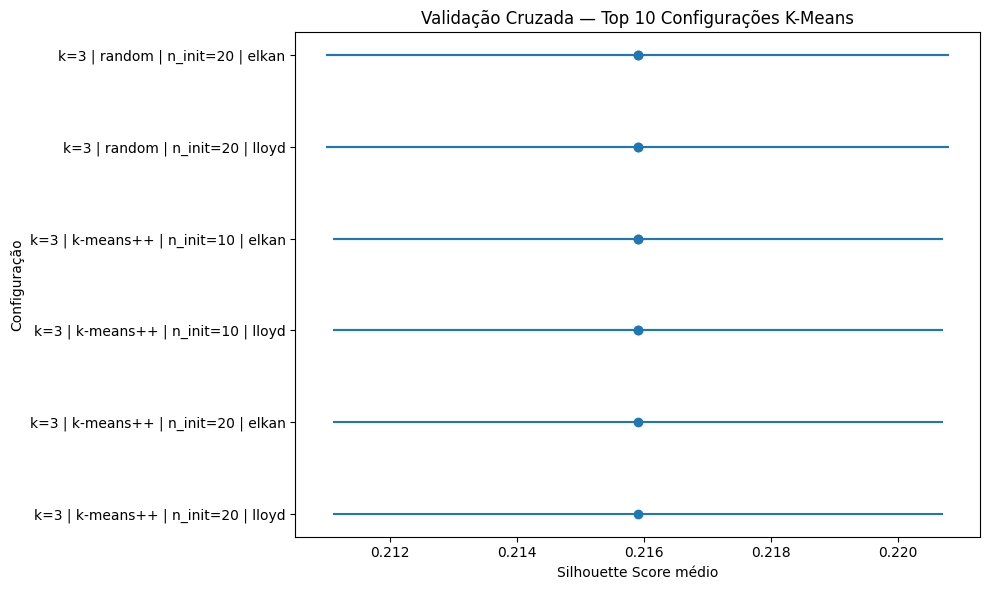

In [78]:
# Gráfico da estabilidade das melhores configurações

top_cv = cv_resumo.head(10).copy()

top_cv["Descricao"] = top_cv.apply(
    lambda row: (
        f"k={int(row['n_clusters'])} | "
        f"{row['init']} | "
        f"n_init={int(row['n_init'])} | "
        f"{row['algorithm']}"
    ),
    axis=1
)

plt.figure(figsize=(10, 6))

plt.errorbar(
    top_cv["Silhouette_Media"],
    top_cv["Descricao"],
    xerr=top_cv["Silhouette_Desvio"],
    fmt="o"
)

plt.xlabel("Silhouette Score médio")
plt.ylabel("Configuração")
plt.title("Validação Cruzada — Top 10 Configurações K-Means")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    figures_path / "m3_kmeans_cross_validation_top_configuracoes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [79]:
# Modelo final otimizado alinhado ao Objetivo SMART

parametros_finais = {
    "n_clusters": int(melhor_config_k3["n_clusters"]),
    "init": melhor_config_k3["init"],
    "n_init": int(melhor_config_k3["n_init"]),
    "max_iter": int(melhor_config_k3["max_iter"]),
    "algorithm": melhor_config_k3["algorithm"],
    "random_state": int(melhor_config_k3["random_state"])
}

print("Parâmetros finais escolhidos:")
print(parametros_finais)

modelo_final = KMeans(**parametros_finais)

labels_finais = modelo_final.fit_predict(X)

metricas_finais = avaliar_labels_cluster(
    X,
    labels_finais,
    centers=modelo_final.cluster_centers_,
    sample_size=len(X)
)

metricas_finais_df = pd.DataFrame([{
    "Modelo": "KMeans Otimizado",
    **parametros_finais,
    **metricas_finais
}]).round(4)

print("Métricas finais do modelo otimizado:")
display(metricas_finais_df)

clusters_finais_resumo = resumo_dimensao_clusters(labels_finais)

print("Distribuição dos clusters finais:")
display(clusters_finais_resumo)

metricas_finais_df.to_csv(
    processed_path / "m3_modelo_final_kmeans_otimizado_metricas.csv",
    index=False
)

clusters_finais_resumo.to_csv(
    processed_path / "m3_modelo_final_kmeans_otimizado_dimensao_clusters.csv",
    index=False
)

df_modelo_final = X.copy()
df_modelo_final["Cluster_Final"] = labels_finais

df_modelo_final.to_csv(
    processed_path / "m3_modelo_final_kmeans_otimizado_clusters.csv",
    index=False
)

print("Modelo final e clusters guardados.")

Parâmetros finais escolhidos:
{'n_clusters': 3, 'init': 'random', 'n_init': 20, 'max_iter': 300, 'algorithm': 'elkan', 'random_state': 42}
Métricas finais do modelo otimizado:


,Modelo,n_clusters,init,n_init,max_iter,algorithm,random_state,N_Clusters,Ruido_%,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inercia,Min_Cluster_%
0,KMeans Otimizado,3,random,20,300,elkan,42,3,0.0,0.2161,1.6155,2734.0301,32059.3038,30.81


Distribuição dos clusters finais:


,Cluster,Nº de clientes,Percentagem (%)
0,0,2170,30.81
1,1,2609,37.04
2,2,2264,32.15


Modelo final e clusters guardados.


,Modelo,n_clusters,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inercia
0,KMeans Baseline,3,0.2161,1.6154,2734.0298,32059.2893
1,KMeans Otimizado,3,0.2161,1.6155,2734.0301,32059.3038


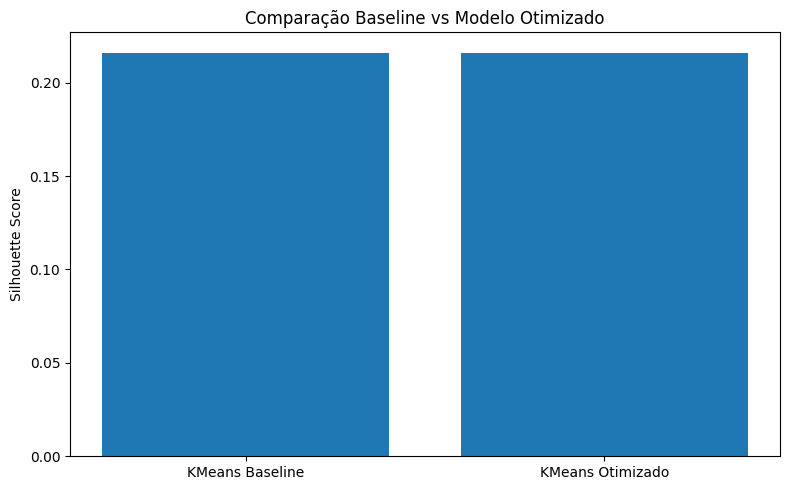

In [80]:
# Comparação Baseline vs Modelo Otimizado

try:
    baseline_comparacao = pd.DataFrame([{
        "Modelo": "KMeans Baseline",
        "n_clusters": int(baseline_full_metrics_df.loc[0, "n_clusters"]),
        "Silhouette": float(baseline_full_metrics_df.loc[0, "Silhouette Score"]),
        "Davies_Bouldin": float(baseline_full_metrics_df.loc[0, "Davies-Bouldin Index"]),
        "Calinski_Harabasz": float(baseline_full_metrics_df.loc[0, "Calinski-Harabasz Score"]),
        "Inercia": float(baseline_full_metrics_df.loc[0, "Inércia"])
    }])
except Exception:
    baseline_carregado = pd.read_csv(processed_path / "m3_baseline_kmeans_full_metrics.csv")
    
    baseline_comparacao = pd.DataFrame([{
        "Modelo": "KMeans Baseline",
        "n_clusters": int(baseline_carregado.loc[0, "n_clusters"]),
        "Silhouette": float(baseline_carregado.loc[0, "Silhouette Score"]),
        "Davies_Bouldin": float(baseline_carregado.loc[0, "Davies-Bouldin Index"]),
        "Calinski_Harabasz": float(baseline_carregado.loc[0, "Calinski-Harabasz Score"]),
        "Inercia": float(baseline_carregado.loc[0, "Inércia"])
    }])

final_comparacao = pd.DataFrame([{
    "Modelo": "KMeans Otimizado",
    "n_clusters": int(metricas_finais_df.loc[0, "n_clusters"]),
    "Silhouette": float(metricas_finais_df.loc[0, "Silhouette"]),
    "Davies_Bouldin": float(metricas_finais_df.loc[0, "Davies_Bouldin"]),
    "Calinski_Harabasz": float(metricas_finais_df.loc[0, "Calinski_Harabasz"]),
    "Inercia": float(metricas_finais_df.loc[0, "Inercia"])
}])

comparacao_baseline_otimizado = pd.concat(
    [baseline_comparacao, final_comparacao],
    ignore_index=True
)

comparacao_baseline_otimizado = comparacao_baseline_otimizado.round(4)

display(comparacao_baseline_otimizado)

comparacao_baseline_otimizado.to_csv(
    processed_path / "m3_comparacao_baseline_vs_otimizado.csv",
    index=False
)

plt.figure(figsize=(8, 5))

plt.bar(
    comparacao_baseline_otimizado["Modelo"],
    comparacao_baseline_otimizado["Silhouette"]
)

plt.ylabel("Silhouette Score")
plt.title("Comparação Baseline vs Modelo Otimizado")
plt.tight_layout()

plt.savefig(
    figures_path / "m3_comparacao_baseline_vs_otimizado_silhouette.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

,Fracao_Treino,N_Treino,N_Clusters,Ruido_%,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inercia,Min_Cluster_%
0,0.2,1127,3,0.0,0.2192,1.5887,546.7445,6441.4424,30.09
1,0.4,2254,3,0.0,0.2191,1.5889,546.8041,6439.0778,29.67
2,0.6,3380,3,0.0,0.2191,1.5886,547.0338,6437.8013,30.02
3,0.8,4507,3,0.0,0.2191,1.5880,547.1260,6434.9878,30.16
4,1.0,5634,3,0.0,0.2192,1.5873,547.1754,6431.4332,30.16


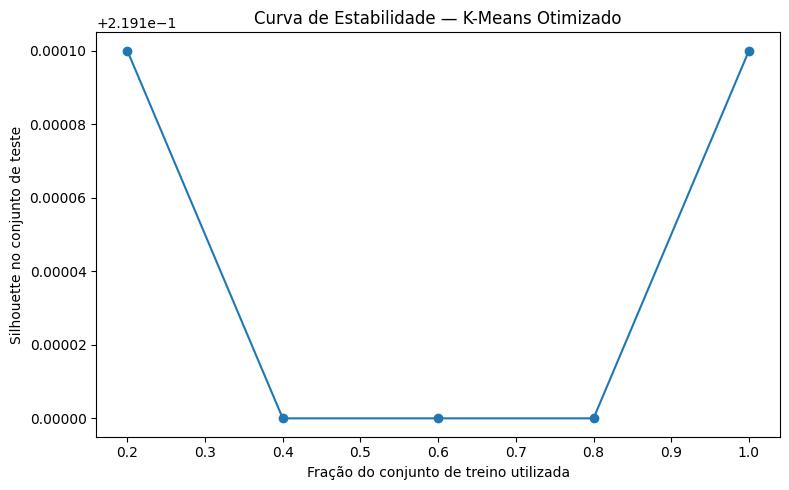

In [81]:
# Curva de estabilidade do modelo final por tamanho de amostra

fracoes_treino = [0.2, 0.4, 0.6, 0.8, 1.0]
resultados_estabilidade = []

for fracao in fracoes_treino:
    if fracao < 1.0:
        X_subtreino = X_train.sample(
            frac=fracao,
            random_state=42
        )
    else:
        X_subtreino = X_train.copy()
    
    modelo_temp = KMeans(**parametros_finais)
    modelo_temp.fit(X_subtreino)
    
    labels_teste_temp = modelo_temp.predict(X_test)
    
    metricas_temp = avaliar_labels_cluster(
        X_test,
        labels_teste_temp,
        centers=modelo_temp.cluster_centers_
    )
    
    resultados_estabilidade.append({
        "Fracao_Treino": fracao,
        "N_Treino": len(X_subtreino),
        **metricas_temp
    })

estabilidade_df = pd.DataFrame(resultados_estabilidade).round(4)

display(estabilidade_df)

estabilidade_df.to_csv(
    processed_path / "m3_curva_estabilidade_kmeans.csv",
    index=False
)

plt.figure(figsize=(8, 5))

plt.plot(
    estabilidade_df["Fracao_Treino"],
    estabilidade_df["Silhouette"],
    marker="o"
)

plt.xlabel("Fração do conjunto de treino utilizada")
plt.ylabel("Silhouette no conjunto de teste")
plt.title("Curva de Estabilidade — K-Means Otimizado")
plt.tight_layout()

plt.savefig(
    figures_path / "m3_curva_estabilidade_kmeans.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 3.2. Otimização Avançada dos Modelos Candidatos

Depois da primeira fase de experimentação, o melhor modelo encontrado foi o K-Means com 3 clusters. No entanto, como o objetivo desta fase é procurar uma segmentação com melhor separação entre grupos, foi realizada uma otimização avançada.

Nesta etapa foram testadas novas famílias de modelos e novas representações dos dados:

- K-Means com grelha mais alargada;
- MiniBatch K-Means;
- Bisecting K-Means, caso estivesse disponível no ambiente;
- Gaussian Mixture Models;
- BIRCH;
- variantes com PCA;
- variante com variáveis numéricas e de engenharia.

Modelos como Spectral Clustering, OPTICS e HDBSCAN foram considerados, mas não integrados na versão final da procura rápida devido ao maior custo computacional no Kaggle.

A seleção será feita com base no equilíbrio entre Silhouette Score, Davies-Bouldin Index, dimensão mínima dos clusters, estabilidade, interpretabilidade e alinhamento com o Objetivo SMART, que define a identificação de 3 perfis de clientes.

In [82]:
# Otimização Avançada dos Modelos Candidatos

from sklearn.mixture import GaussianMixture
from sklearn.cluster import Birch, SpectralClustering, OPTICS

# Importações opcionais, dependendo da versão do scikit-learn no Kaggle
try:
    from sklearn.cluster import BisectingKMeans
    bisecting_available = True
    print("BisectingKMeans disponível.")
except Exception:
    bisecting_available = False
    print("BisectingKMeans não disponível neste ambiente.")

try:
    from sklearn.cluster import HDBSCAN
    hdbscan_available = True
    print("HDBSCAN disponível.")
except Exception:
    hdbscan_available = False
    print("HDBSCAN não disponível neste ambiente.")

from sklearn.decomposition import PCA
from sklearn.model_selection import ParameterGrid


BisectingKMeans disponível.
HDBSCAN disponível.


In [83]:
# Criação de variantes do espaço de atributos

def criar_pca_df(X_base, variancia, nome_prefixo):
    """
    Aplica PCA mantendo uma percentagem de variância explicada.
    """
    pca = PCA(
        n_components=variancia,
        random_state=42
    )
    
    X_pca = pca.fit_transform(X_base)
    
    X_pca_df = pd.DataFrame(
        X_pca,
        columns=[f"{nome_prefixo}_PC{i+1}" for i in range(X_pca.shape[1])]
    )
    
    return X_pca_df, pca.explained_variance_ratio_.sum()


# Variantes principais
variantes_X = {}

# Variante atual já preparada na M2
variantes_X["Atual_M2"] = X.copy()

# PCA sobre a variante atual
X_pca_80, var80 = criar_pca_df(X, 0.80, "PCA80")
X_pca_90, var90 = criar_pca_df(X, 0.90, "PCA90")
X_pca_95, var95 = criar_pca_df(X, 0.95, "PCA95")

variantes_X["Atual_M2_PCA80"] = X_pca_80
variantes_X["Atual_M2_PCA90"] = X_pca_90
variantes_X["Atual_M2_PCA95"] = X_pca_95

# Variante apenas com variáveis numéricas/engenharia, se existirem
colunas_numericas_focadas = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ServiceCount",
    "HasInternetService"
]

colunas_numericas_focadas = [
    col for col in colunas_numericas_focadas
    if col in X.columns
]

if len(colunas_numericas_focadas) >= 2:
    variantes_X["Numericas_Engenharia"] = X[colunas_numericas_focadas].copy()

print("Variantes de dados criadas:")

for nome, X_var in variantes_X.items():
    print(nome, "->", X_var.shape)

Variantes de dados criadas:
Atual_M2 -> (7043, 24)
Atual_M2_PCA80 -> (7043, 9)
Atual_M2_PCA90 -> (7043, 13)
Atual_M2_PCA95 -> (7043, 16)
Numericas_Engenharia -> (7043, 6)


In [84]:
# Função de avaliação avançada

def avaliar_modelo_avancado(nome_modelo, parametros, X_data, nome_variante):
    """
    Treina um modelo de clustering no dataset completo e calcula métricas.
    Esta função é usada para procura avançada de modelos candidatos.
    """
    
    centers = None
    
    if nome_modelo == "KMeans":
        modelo = KMeans(**parametros)
        labels = modelo.fit_predict(X_data)
        centers = modelo.cluster_centers_
    
    elif nome_modelo == "MiniBatchKMeans":
        modelo = MiniBatchKMeans(**parametros)
        labels = modelo.fit_predict(X_data)
        centers = modelo.cluster_centers_
    
    elif nome_modelo == "BisectingKMeans":
        modelo = BisectingKMeans(**parametros)
        labels = modelo.fit_predict(X_data)
        centers = modelo.cluster_centers_
    
    elif nome_modelo == "GaussianMixture":
        modelo = GaussianMixture(**parametros)
        labels = modelo.fit_predict(X_data)
    
    elif nome_modelo == "Birch":
        modelo = Birch(**parametros)
        labels = modelo.fit_predict(X_data)
    
    elif nome_modelo == "SpectralClustering":
        modelo = SpectralClustering(**parametros)
        labels = modelo.fit_predict(X_data)
    
    elif nome_modelo == "OPTICS":
        modelo = OPTICS(**parametros)
        labels = modelo.fit_predict(X_data)
    
    elif nome_modelo == "HDBSCAN":
        modelo = HDBSCAN(**parametros)
        labels = modelo.fit_predict(X_data)
    
    else:
        raise ValueError("Modelo não reconhecido.")
    
    metricas = avaliar_labels_cluster(
        X_data,
        labels,
        centers=centers,
        sample_size=3000
    )
    
    resultado = {
        "Variante_Dados": nome_variante,
        "Modelo": nome_modelo,
        **parametros,
        **metricas
    }
    
    return resultado, labels

In [85]:
# Procura avançada otimizada — versão rápida

import time
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

inicio_total = time.time()

# Grelha reduzida para evitar tempos excessivos
espacos_avancados_rapidos = {}

espacos_avancados_rapidos["KMeans"] = list(ParameterGrid({
    "n_clusters": [2, 3, 4, 5, 6, 7, 8, 9, 10],
    "init": ["k-means++"],
    "n_init": [20, 50],
    "max_iter": [300, 500],
    "algorithm": ["lloyd"],
    "random_state": [42]
}))

espacos_avancados_rapidos["MiniBatchKMeans"] = list(ParameterGrid({
    "n_clusters": [2, 3, 4, 5, 6, 7, 8, 9, 10],
    "init": ["k-means++"],
    "n_init": [20],
    "batch_size": [512, 2048],
    "max_iter": [300],
    "random_state": [42]
}))

if "bisecting_available" in globals() and bisecting_available:
    espacos_avancados_rapidos["BisectingKMeans"] = list(ParameterGrid({
        "n_clusters": [2, 3, 4, 5, 6, 7, 8, 9, 10],
        "init": ["k-means++"],
        "n_init": [10],
        "random_state": [42]
    }))

espacos_avancados_rapidos["GaussianMixture"] = list(ParameterGrid({
    "n_components": [2, 3, 4, 5, 6, 7, 8, 9, 10],
    "covariance_type": ["diag", "spherical"],
    "n_init": [5],
    "random_state": [42]
}))

espacos_avancados_rapidos["Birch"] = list(ParameterGrid({
    "n_clusters": [2, 3, 4, 5, 6, 7, 8, 9, 10],
    "threshold": [0.05, 0.1, 0.25, 0.5],
    "branching_factor": [25, 50]
}))

print("Modelos rápidos definidos:")

for modelo, configs in espacos_avancados_rapidos.items():
    print(modelo, "->", len(configs), "configurações")


def amostrar_dados(X_data, n=3000):
    """
    Usa uma amostra para ranking inicial dos modelos.
    """
    X_df = pd.DataFrame(X_data).reset_index(drop=True)
    
    if len(X_df) > n:
        return X_df.sample(n=n, random_state=42).reset_index(drop=True)
    
    return X_df.copy()


# Ranking inicial numa amostra

resultados_avancados_amostra = []

for nome_variante, X_var in variantes_X.items():
    X_amostra = amostrar_dados(X_var, n=3000)
    
    print("\n==============================")
    print(f"Variante: {nome_variante} | shape amostra={X_amostra.shape}")
    print("==============================")
    
    for nome_modelo, configs in espacos_avancados_rapidos.items():
        print(f"\nA testar modelo: {nome_modelo}")
        
        for i, parametros in enumerate(configs, start=1):
            try:
                resultado, _ = avaliar_modelo_avancado(
                    nome_modelo=nome_modelo,
                    parametros=parametros,
                    X_data=X_amostra,
                    nome_variante=nome_variante
                )
                
                resultados_avancados_amostra.append(resultado)
                
                if i % 10 == 0 or i == len(configs):
                    print(f"  {i}/{len(configs)} configurações concluídas.")
            
            except Exception as e:
                print(f"  Erro em {nome_modelo}, configuração {i}/{len(configs)}: {e}")

resultados_avancados_amostra_df = pd.DataFrame(resultados_avancados_amostra)

for coluna in [
    "Silhouette",
    "Davies_Bouldin",
    "Calinski_Harabasz",
    "Inercia",
    "Ruido_%",
    "Min_Cluster_%"
]:
    if coluna in resultados_avancados_amostra_df.columns:
        resultados_avancados_amostra_df[coluna] = resultados_avancados_amostra_df[coluna].round(4)

resultados_avancados_amostra_df.to_csv(
    processed_path / "m3_otimizacao_avancada_amostra.csv",
    index=False
)

display(resultados_avancados_amostra_df.head())

tempo_total = time.time() - inicio_total
print(f"Procura avançada em amostra concluída em {tempo_total:.2f} segundos.")

Modelos rápidos definidos:
KMeans -> 36 configurações
MiniBatchKMeans -> 18 configurações
BisectingKMeans -> 9 configurações
GaussianMixture -> 18 configurações
Birch -> 72 configurações

Variante: Atual_M2 | shape amostra=(3000, 24)

A testar modelo: KMeans
  10/36 configurações concluídas.
  20/36 configurações concluídas.
  30/36 configurações concluídas.
  36/36 configurações concluídas.

A testar modelo: MiniBatchKMeans
  10/18 configurações concluídas.
  18/18 configurações concluídas.

A testar modelo: BisectingKMeans
  9/9 configurações concluídas.

A testar modelo: GaussianMixture
  10/18 configurações concluídas.
  18/18 configurações concluídas.

A testar modelo: Birch
  10/72 configurações concluídas.
  20/72 configurações concluídas.
  30/72 configurações concluídas.
  40/72 configurações concluídas.
  50/72 configurações concluídas.
  60/72 configurações concluídas.
  70/72 configurações concluídas.
  72/72 configurações concluídas.

Variante: Atual_M2_PCA80 | shape amost

,Variante_Dados,Modelo,algorithm,init,max_iter,n_clusters,n_init,random_state,N_Clusters,Ruido_%,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inercia,Min_Cluster_%,batch_size,covariance_type,n_components,branching_factor,threshold
0,Atual_M2,KMeans,lloyd,k-means++,300.0,2.0,20.0,42.0,2,0.0,0.2784,1.4081,1426.4962,16371.6536,39.07,NaN,NaN,NaN,NaN,NaN
1,Atual_M2,KMeans,lloyd,k-means++,300.0,2.0,50.0,42.0,2,0.0,0.2784,1.4081,1426.4962,16371.6536,39.07,NaN,NaN,NaN,NaN,NaN
2,Atual_M2,KMeans,lloyd,k-means++,300.0,3.0,20.0,42.0,3,0.0,0.2151,1.6096,1144.0243,13701.3142,30.67,NaN,NaN,NaN,NaN,NaN
3,Atual_M2,KMeans,lloyd,k-means++,300.0,3.0,50.0,42.0,3,0.0,0.2151,1.6096,1144.0243,13701.3142,30.67,NaN,NaN,NaN,NaN,NaN
4,Atual_M2,KMeans,lloyd,k-means++,300.0,4.0,20.0,42.0,4,0.0,0.1787,1.9173,902.1323,12694.3028,18.40,NaN,NaN,NaN,NaN,NaN


Procura avançada em amostra concluída em 215.13 segundos.


In [86]:
# Ranking dos melhores modelos na amostra

ranking_amostra = resultados_avancados_amostra_df.copy()

ranking_amostra_valido = ranking_amostra[
    (ranking_amostra["N_Clusters"] >= 2) &
    (ranking_amostra["N_Clusters"] <= 10) &
    (ranking_amostra["Min_Cluster_%"] >= 5) &
    (ranking_amostra["Ruido_%"] <= 30) &
    (ranking_amostra["Silhouette"].notna())
].copy()

ranking_amostra_valido = ranking_amostra_valido.sort_values(
    by=["Silhouette", "Davies_Bouldin", "Min_Cluster_%"],
    ascending=[False, True, False]
)

print("Top 25 modelos na amostra:")
display(ranking_amostra_valido.head(25))

ranking_amostra_valido.to_csv(
    processed_path / "m3_ranking_otimizacao_avancada_amostra.csv",
    index=False
)

Top 25 modelos na amostra:


,Variante_Dados,Modelo,algorithm,init,max_iter,n_clusters,n_init,random_state,N_Clusters,Ruido_%,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inercia,Min_Cluster_%,batch_size,covariance_type,n_components,branching_factor,threshold
684,Numericas_Engenharia,GaussianMixture,NaN,NaN,NaN,NaN,5.0,42.0,2,0.0,0.4379,0.8453,2999.9924,NaN,30.93,NaN,spherical,2.0,NaN,NaN
612,Numericas_Engenharia,KMeans,lloyd,k-means++,300.0,2.0,20.0,42.0,2,0.0,0.4328,0.8874,3065.3427,6345.8540,35.63,NaN,NaN,NaN,NaN,NaN
613,Numericas_Engenharia,KMeans,lloyd,k-means++,300.0,2.0,50.0,42.0,2,0.0,0.4328,0.8874,3065.3427,6345.8540,35.63,NaN,NaN,NaN,NaN,NaN
630,Numericas_Engenharia,KMeans,lloyd,k-means++,500.0,2.0,20.0,42.0,2,0.0,0.4328,0.8874,3065.3427,6345.8540,35.63,NaN,NaN,NaN,NaN,NaN
631,Numericas_Engenharia,KMeans,lloyd,k-means++,500.0,2.0,50.0,42.0,2,0.0,0.4328,0.8874,3065.3427,6345.8540,35.63,NaN,NaN,NaN,NaN,NaN
666,Numericas_Engenharia,BisectingKMeans,NaN,k-means++,NaN,2.0,10.0,42.0,2,0.0,0.4328,0.8874,3065.3427,6345.8430,35.63,NaN,NaN,NaN,NaN,NaN
657,Numericas_Engenharia,MiniBatchKMeans,NaN,k-means++,300.0,2.0,20.0,42.0,2,0.0,0.4327,0.8879,3065.3204,6346.2164,35.70,2048.0,NaN,NaN,NaN,NaN
648,Numericas_Engenharia,MiniBatchKMeans,NaN,k-means++,300.0,2.0,20.0,42.0,2,0.0,0.4322,0.8900,3064.9988,6347.8818,35.93,512.0,NaN,NaN,NaN,NaN
695,Numericas_Engenharia,Birch,NaN,NaN,NaN,2.0,NaN,NaN,2,0.0,0.4290,0.8352,2819.3387,NaN,28.33,NaN,NaN,NaN,25.0,0.25
729,Numericas_Engenharia,Birch,NaN,NaN,NaN,2.0,NaN,NaN,2,0.0,0.4271,0.8399,2798.6649,NaN,28.40,NaN,NaN,NaN,50.0,0.05


In [87]:
# ============================================================
# Avaliação dos Top 25 modelos da amostra no dataset completo
# ============================================================

parametros_por_modelo = {
    "KMeans": [
        "n_clusters", "init", "n_init", "max_iter", "algorithm", "random_state"
    ],
    "MiniBatchKMeans": [
        "n_clusters", "init", "n_init", "batch_size", "max_iter", "random_state"
    ],
    "BisectingKMeans": [
        "n_clusters", "init", "n_init", "random_state"
    ],
    "GaussianMixture": [
        "n_components", "covariance_type", "n_init", "random_state"
    ],
    "Birch": [
        "n_clusters", "threshold", "branching_factor"
    ]
}


def extrair_parametros_linha(linha):
    """
    Extrai os parâmetros corretos para cada modelo a partir de uma linha do ranking.
    """
    nome_modelo = linha["Modelo"]
    parametros = {}
    
    for chave in parametros_por_modelo.get(nome_modelo, []):
        if chave in linha.index and pd.notna(linha[chave]):
            valor = linha[chave]
            
            if chave in [
                "n_clusters",
                "n_components",
                "n_init",
                "max_iter",
                "batch_size",
                "branching_factor",
                "random_state"
            ]:
                valor = int(valor)
            
            parametros[chave] = valor
    
    return parametros


top_para_full = ranking_amostra_valido.head(25).copy()

resultados_full_top = []

for idx, linha in top_para_full.iterrows():
    nome_variante = linha["Variante_Dados"]
    nome_modelo = linha["Modelo"]
    parametros = extrair_parametros_linha(linha)
    
    X_full_variante = variantes_X[nome_variante]
    
    print("\nA avaliar no dataset completo:")
    print("Variante:", nome_variante)
    print("Modelo:", nome_modelo)
    print("Parâmetros:", parametros)
    
    try:
        resultado, _ = avaliar_modelo_avancado(
            nome_modelo=nome_modelo,
            parametros=parametros,
            X_data=X_full_variante,
            nome_variante=nome_variante
        )
        
        resultados_full_top.append(resultado)
    
    except Exception as e:
        print("Erro:", e)

resultados_full_top_df = pd.DataFrame(resultados_full_top)

for coluna in [
    "Silhouette",
    "Davies_Bouldin",
    "Calinski_Harabasz",
    "Inercia",
    "Ruido_%",
    "Min_Cluster_%"
]:
    if coluna in resultados_full_top_df.columns:
        resultados_full_top_df[coluna] = resultados_full_top_df[coluna].round(4)

ranking_full_top = resultados_full_top_df[
    (resultados_full_top_df["N_Clusters"] >= 2) &
    (resultados_full_top_df["N_Clusters"] <= 10) &
    (resultados_full_top_df["Min_Cluster_%"] >= 5) &
    (resultados_full_top_df["Ruido_%"] <= 30) &
    (resultados_full_top_df["Silhouette"].notna())
].copy()

ranking_full_top = ranking_full_top.sort_values(
    by=["Silhouette", "Davies_Bouldin", "Min_Cluster_%"],
    ascending=[False, True, False]
)

print("Ranking final dos melhores modelos avaliados no dataset completo:")
display(ranking_full_top)

ranking_full_top.to_csv(
    processed_path / "m3_ranking_otimizacao_avancada_full_top25.csv",
    index=False
)

melhor_modelo_avancado_full = ranking_full_top.iloc[0]

print("Melhor modelo avançado no dataset completo:")
display(melhor_modelo_avancado_full)


A avaliar no dataset completo:
Variante: Numericas_Engenharia
Modelo: GaussianMixture
Parâmetros: {'n_components': 2, 'covariance_type': 'spherical', 'n_init': 5, 'random_state': 42}

A avaliar no dataset completo:
Variante: Numericas_Engenharia
Modelo: KMeans
Parâmetros: {'n_clusters': 2, 'init': 'k-means++', 'n_init': 20, 'max_iter': 300, 'algorithm': 'lloyd', 'random_state': 42}

A avaliar no dataset completo:
Variante: Numericas_Engenharia
Modelo: KMeans
Parâmetros: {'n_clusters': 2, 'init': 'k-means++', 'n_init': 50, 'max_iter': 300, 'algorithm': 'lloyd', 'random_state': 42}

A avaliar no dataset completo:
Variante: Numericas_Engenharia
Modelo: KMeans
Parâmetros: {'n_clusters': 2, 'init': 'k-means++', 'n_init': 20, 'max_iter': 500, 'algorithm': 'lloyd', 'random_state': 42}

A avaliar no dataset completo:
Variante: Numericas_Engenharia
Modelo: KMeans
Parâmetros: {'n_clusters': 2, 'init': 'k-means++', 'n_init': 50, 'max_iter': 500, 'algorithm': 'lloyd', 'random_state': 42}

A avali

,Variante_Dados,Modelo,n_components,covariance_type,n_init,random_state,N_Clusters,Ruido_%,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inercia,Min_Cluster_%,n_clusters,init,max_iter,algorithm,batch_size,threshold,branching_factor
0,Numericas_Engenharia,GaussianMixture,2.0,spherical,5.0,42.0,2,0.0,0.4377,0.8396,7232.9524,NaN,31.55,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Numericas_Engenharia,KMeans,NaN,NaN,20.0,42.0,2,0.0,0.4321,0.8786,7397.1788,14788.0605,36.14,2.0,k-means++,300.0,lloyd,NaN,NaN,NaN
2,Numericas_Engenharia,KMeans,NaN,NaN,50.0,42.0,2,0.0,0.4321,0.8786,7397.1788,14788.0605,36.14,2.0,k-means++,300.0,lloyd,NaN,NaN,NaN
3,Numericas_Engenharia,KMeans,NaN,NaN,20.0,42.0,2,0.0,0.4321,0.8786,7397.1788,14788.0605,36.14,2.0,k-means++,500.0,lloyd,NaN,NaN,NaN
4,Numericas_Engenharia,KMeans,NaN,NaN,50.0,42.0,2,0.0,0.4321,0.8786,7397.1788,14788.0605,36.14,2.0,k-means++,500.0,lloyd,NaN,NaN,NaN
5,Numericas_Engenharia,BisectingKMeans,NaN,NaN,10.0,42.0,2,0.0,0.4321,0.8786,7397.1788,14788.0605,36.14,2.0,k-means++,NaN,NaN,NaN,NaN,NaN
6,Numericas_Engenharia,MiniBatchKMeans,NaN,NaN,20.0,42.0,2,0.0,0.4297,0.8871,7391.6744,14797.1638,37.14,2.0,k-means++,300.0,NaN,2048.0,NaN,NaN
7,Numericas_Engenharia,MiniBatchKMeans,NaN,NaN,20.0,42.0,2,0.0,0.4290,0.8897,7388.0675,14804.2555,37.46,2.0,k-means++,300.0,NaN,512.0,NaN,NaN
10,Numericas_Engenharia,Birch,NaN,NaN,NaN,NaN,2,0.0,0.4230,0.8186,6388.7519,NaN,26.86,2.0,NaN,NaN,NaN,NaN,0.25,50.0
14,Numericas_Engenharia,Birch,NaN,NaN,NaN,NaN,2,0.0,0.4211,0.8241,6176.4758,NaN,26.45,2.0,NaN,NaN,NaN,NaN,0.05,25.0


Melhor modelo avançado no dataset completo:


Variante_Dados       Numericas_Engenharia
Modelo                    GaussianMixture
n_components                          2.0
covariance_type                 spherical
n_init                                5.0
random_state                         42.0
N_Clusters                              2
Ruido_%                               0.0
Silhouette                         0.4377
Davies_Bouldin                     0.8396
Calinski_Harabasz               7232.9524
Inercia                               NaN
Min_Cluster_%                       31.55
n_clusters                            NaN
init                                  NaN
max_iter                              NaN
algorithm                             NaN
batch_size                            NaN
threshold                             NaN
branching_factor                      NaN
Name: 0, dtype: object

In [88]:
# ============================================================
# Ranking avançado apenas com 3 clusters
# ============================================================

ranking_full_top_k3 = ranking_full_top[
    ranking_full_top["N_Clusters"] == 3
].copy()

ranking_full_top_k3 = ranking_full_top_k3.sort_values(
    by=["Silhouette", "Davies_Bouldin", "Min_Cluster_%"],
    ascending=[False, True, False]
)

print("Top modelos avançados com 3 clusters no dataset completo:")
display(ranking_full_top_k3.head(20))

ranking_full_top_k3.to_csv(
    processed_path / "m3_ranking_otimizacao_avancada_k3_full.csv",
    index=False
)

if not ranking_full_top_k3.empty:
    melhor_k3_avancado_full = ranking_full_top_k3.iloc[0]
    print("Melhor modelo avançado com 3 clusters:")
    display(melhor_k3_avancado_full)
else:
    melhor_k3_avancado_full = None
    print("Nenhum modelo avançado válido com 3 clusters foi encontrado.")

Top modelos avançados com 3 clusters no dataset completo:


,Variante_Dados,Modelo,n_components,covariance_type,n_init,random_state,N_Clusters,Ruido_%,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inercia,Min_Cluster_%,n_clusters,init,max_iter,algorithm,batch_size,threshold,branching_factor
22,Numericas_Engenharia,GaussianMixture,3.0,spherical,5.0,42.0,3,0.0,0.3947,0.9626,7142.2309,NaN,29.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,Numericas_Engenharia,KMeans,NaN,NaN,20.0,42.0,3,0.0,0.3946,0.9675,7173.2604,9982.1154,29.90,3.0,k-means++,300.0,lloyd,NaN,NaN,NaN
20,Numericas_Engenharia,KMeans,NaN,NaN,20.0,42.0,3,0.0,0.3946,0.9675,7173.2604,9982.1154,29.90,3.0,k-means++,500.0,lloyd,NaN,NaN,NaN
19,Numericas_Engenharia,KMeans,NaN,NaN,50.0,42.0,3,0.0,0.3945,0.9674,7173.2850,9982.0832,29.92,3.0,k-means++,300.0,lloyd,NaN,NaN,NaN
21,Numericas_Engenharia,KMeans,NaN,NaN,50.0,42.0,3,0.0,0.3945,0.9674,7173.2850,9982.0832,29.92,3.0,k-means++,500.0,lloyd,NaN,NaN,NaN
17,Numericas_Engenharia,MiniBatchKMeans,NaN,NaN,20.0,42.0,3,0.0,0.3939,0.9704,7164.0158,9999.1935,29.55,3.0,k-means++,300.0,NaN,512.0,NaN,NaN
23,Numericas_Engenharia,GaussianMixture,3.0,diag,5.0,42.0,3,0.0,0.3921,0.9304,6400.5935,NaN,21.67,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,Numericas_Engenharia,MiniBatchKMeans,NaN,NaN,20.0,42.0,3,0.0,0.3919,0.9748,7158.9590,10010.4931,29.67,3.0,k-means++,300.0,NaN,2048.0,NaN,NaN


Melhor modelo avançado com 3 clusters:


Variante_Dados       Numericas_Engenharia
Modelo                    GaussianMixture
n_components                          3.0
covariance_type                 spherical
n_init                                5.0
random_state                         42.0
N_Clusters                              3
Ruido_%                               0.0
Silhouette                         0.3947
Davies_Bouldin                     0.9626
Calinski_Harabasz               7142.2309
Inercia                               NaN
Min_Cluster_%                       29.62
n_clusters                            NaN
init                                  NaN
max_iter                              NaN
algorithm                             NaN
batch_size                            NaN
threshold                             NaN
branching_factor                      NaN
Name: 22, dtype: object

In [89]:
# Comparação com o modelo final 

silhouette_atual = float(metricas_finais_df.loc[0, "Silhouette"])
davies_atual = float(metricas_finais_df.loc[0, "Davies_Bouldin"])

comparacao_modelos_final = pd.DataFrame([
    {
        "Cenario": "Modelo atual",
        "Variante_Dados": "Atual_M2",
        "Modelo": "KMeans Otimizado",
        "N_Clusters": int(metricas_finais_df.loc[0, "N_Clusters"]),
        "Silhouette": silhouette_atual,
        "Davies_Bouldin": davies_atual,
        "Min_Cluster_%": float(metricas_finais_df.loc[0, "Min_Cluster_%"])
    },
    {
        "Cenario": "Melhor modelo avançado",
        "Variante_Dados": melhor_modelo_avancado_full["Variante_Dados"],
        "Modelo": melhor_modelo_avancado_full["Modelo"],
        "N_Clusters": int(melhor_modelo_avancado_full["N_Clusters"]),
        "Silhouette": float(melhor_modelo_avancado_full["Silhouette"]),
        "Davies_Bouldin": float(melhor_modelo_avancado_full["Davies_Bouldin"]),
        "Min_Cluster_%": float(melhor_modelo_avancado_full["Min_Cluster_%"])
    }
])

if "melhor_k3_avancado_full" in globals() and melhor_k3_avancado_full is not None:
    comparacao_modelos_final = pd.concat([
        comparacao_modelos_final,
        pd.DataFrame([{
            "Cenario": "Melhor avançado com 3 clusters",
            "Variante_Dados": melhor_k3_avancado_full["Variante_Dados"],
            "Modelo": melhor_k3_avancado_full["Modelo"],
            "N_Clusters": int(melhor_k3_avancado_full["N_Clusters"]),
            "Silhouette": float(melhor_k3_avancado_full["Silhouette"]),
            "Davies_Bouldin": float(melhor_k3_avancado_full["Davies_Bouldin"]),
            "Min_Cluster_%": float(melhor_k3_avancado_full["Min_Cluster_%"])
        }])
    ], ignore_index=True)

comparacao_modelos_final["Melhoria_Silhouette"] = (
    comparacao_modelos_final["Silhouette"] - silhouette_atual
).round(4)

comparacao_modelos_final = comparacao_modelos_final.round(4)

display(comparacao_modelos_final)

comparacao_modelos_final.to_csv(
    processed_path / "m3_comparacao_modelo_atual_vs_melhor_avancado.csv",
    index=False
)

,Cenario,Variante_Dados,Modelo,N_Clusters,Silhouette,Davies_Bouldin,Min_Cluster_%,Melhoria_Silhouette
0,Modelo atual,Atual_M2,KMeans Otimizado,3,0.2161,1.6155,30.81,0.0000
1,Melhor modelo avançado,Numericas_Engenharia,GaussianMixture,2,0.4377,0.8396,31.55,0.2216
2,Melhor avançado com 3 clusters,Numericas_Engenharia,GaussianMixture,3,0.3947,0.9626,29.62,0.1786


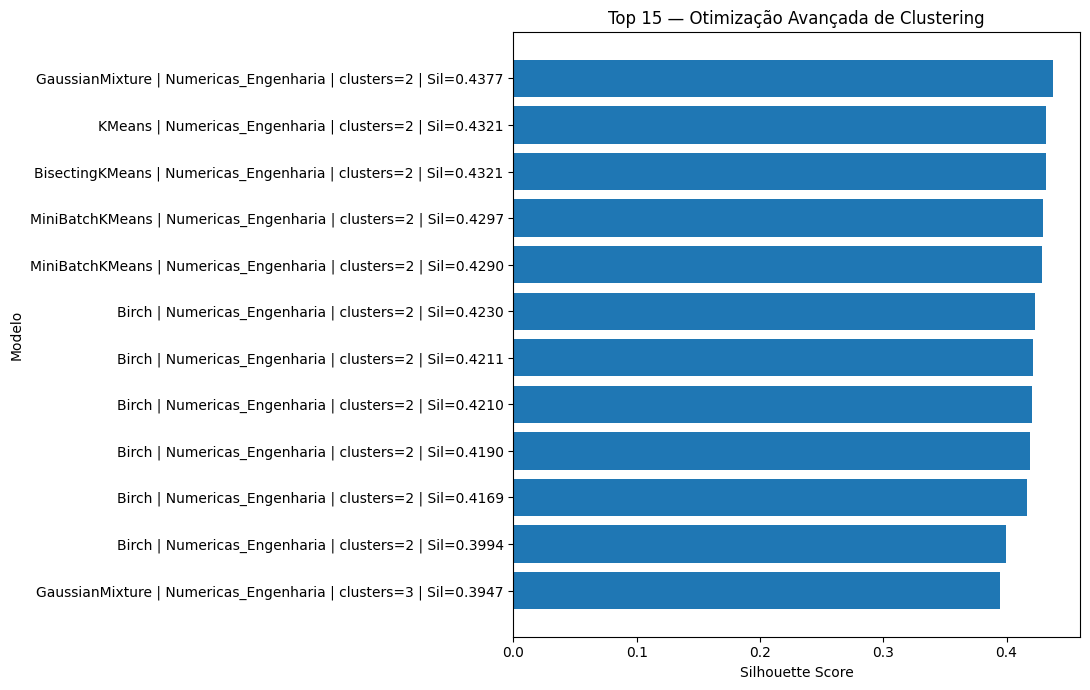

In [90]:
# ============================================================
# Gráfico Top 15 modelos avançados — versão corrigida
# ============================================================

top_avancado_plot = ranking_full_top.head(15).copy()

top_avancado_plot["Descricao"] = top_avancado_plot.apply(
    lambda row: (
        f"{row['Modelo']} | {row['Variante_Dados']} | "
        f"clusters={int(row['N_Clusters'])} | Sil={row['Silhouette']:.4f}"
    ),
    axis=1
)

plt.figure(figsize=(11, 7))

plt.barh(
    top_avancado_plot["Descricao"],
    top_avancado_plot["Silhouette"]
)

plt.xlabel("Silhouette Score")
plt.ylabel("Modelo")
plt.title("Top 15 — Otimização Avançada de Clustering")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig(
    figures_path / "m3_top15_otimizacao_avancada_silhouette.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [91]:
# Decisão final após otimização avançada — alinhada com o Objetivo SMART

melhoria_minima = 0.005

silhouette_atual = float(metricas_finais_df.loc[0, "Silhouette"])

# Por defeito, manter o modelo atual
modelo_final_decisao = None
decisao_final = (
    "Manter o modelo atual, pois não foi encontrado modelo avançado "
    "com 3 clusters e melhoria material."
)

# O Objetivo SMART define 3 perfis de clientes.
# Por isso, a decisão final deve privilegiar o melhor modelo válido com 3 clusters,
# mesmo que exista uma solução global com 2 clusters e Silhouette superior.
if "melhor_k3_avancado_full" in globals() and melhor_k3_avancado_full is not None:
    if float(melhor_k3_avancado_full["Silhouette"]) >= silhouette_atual + melhoria_minima:
        modelo_final_decisao = melhor_k3_avancado_full
        decisao_final = "Substituir pelo melhor modelo avançado com 3 clusters."
else:
    decisao_final = (
        "Não foi encontrado modelo avançado válido com 3 clusters. "
        "Mantém-se o modelo atual."
    )

print("Decisão final:")
print(decisao_final)

print("\nSilhouette do modelo atual:")
print(round(silhouette_atual, 4))

if "melhor_modelo_avancado_full" in globals():
    print("\nMelhor modelo global encontrado, apenas para comparação:")
    display(melhor_modelo_avancado_full)

if modelo_final_decisao is not None:
    print("\nModelo final selecionado, alinhado com o Objetivo SMART:")
    display(modelo_final_decisao)
else:
    print("\nModelo mantido:")
    display(metricas_finais_df)

Decisão final:
Substituir pelo melhor modelo avançado com 3 clusters.

Silhouette do modelo atual:
0.2161

Melhor modelo global encontrado, apenas para comparação:


Variante_Dados       Numericas_Engenharia
Modelo                    GaussianMixture
n_components                          2.0
covariance_type                 spherical
n_init                                5.0
random_state                         42.0
N_Clusters                              2
Ruido_%                               0.0
Silhouette                         0.4377
Davies_Bouldin                     0.8396
Calinski_Harabasz               7232.9524
Inercia                               NaN
Min_Cluster_%                       31.55
n_clusters                            NaN
init                                  NaN
max_iter                              NaN
algorithm                             NaN
batch_size                            NaN
threshold                             NaN
branching_factor                      NaN
Name: 0, dtype: object


Modelo final selecionado, alinhado com o Objetivo SMART:


Variante_Dados       Numericas_Engenharia
Modelo                    GaussianMixture
n_components                          3.0
covariance_type                 spherical
n_init                                5.0
random_state                         42.0
N_Clusters                              3
Ruido_%                               0.0
Silhouette                         0.3947
Davies_Bouldin                     0.9626
Calinski_Harabasz               7142.2309
Inercia                               NaN
Min_Cluster_%                       29.62
n_clusters                            NaN
init                                  NaN
max_iter                              NaN
algorithm                             NaN
batch_size                            NaN
threshold                             NaN
branching_factor                      NaN
Name: 22, dtype: object

In [92]:
# Recuperar labels do melhor modelo avançado

if modelo_final_decisao is not None:
    
    nome_variante_escolhida = modelo_final_decisao["Variante_Dados"]
    nome_modelo_escolhido = modelo_final_decisao["Modelo"]
    
    # Reconstruir parâmetros usados
    parametros_escolhidos = {}
    
    for coluna in modelo_final_decisao.index:
        if coluna in [
            "Variante_Dados",
            "Modelo",
            "N_Clusters",
            "Ruido_%",
            "Silhouette",
            "Davies_Bouldin",
            "Calinski_Harabasz",
            "Inercia",
            "Min_Cluster_%",
            "K_Configurado"
        ]:
            continue
        
        valor = modelo_final_decisao[coluna]
        
        if pd.notna(valor):
            parametros_escolhidos[coluna] = valor
    
    # Corrigir tipos de parâmetros
    for chave in parametros_escolhidos:
        if chave in [
            "n_clusters",
            "n_components",
            "n_init",
            "max_iter",
            "batch_size",
            "branching_factor",
            "n_neighbors",
            "min_samples",
            "min_cluster_size",
            "random_state"
        ]:
            try:
                parametros_escolhidos[chave] = int(parametros_escolhidos[chave])
            except Exception:
                pass
    
    X_final_avancado = variantes_X[nome_variante_escolhida]
    
    resultado_final_avancado, labels_finais_avancados = avaliar_modelo_avancado(
        nome_modelo=nome_modelo_escolhido,
        parametros=parametros_escolhidos,
        X_data=X_final_avancado,
        nome_variante=nome_variante_escolhida
    )
    
    metricas_finais_avancadas_df = pd.DataFrame([resultado_final_avancado]).round(4)
    
    print("Métricas finais avançadas:")
    display(metricas_finais_avancadas_df)
    
    clusters_finais_avancados_resumo = resumo_dimensao_clusters(labels_finais_avancados)
    
    print("Distribuição dos clusters do modelo avançado:")
    display(clusters_finais_avancados_resumo)
    
    metricas_finais_avancadas_df.to_csv(
        processed_path / "m3_modelo_final_avancado_metricas.csv",
        index=False
    )
    
    clusters_finais_avancados_resumo.to_csv(
        processed_path / "m3_modelo_final_avancado_dimensao_clusters.csv",
        index=False
    )
    
    df_modelo_final_avancado = X.copy()
    df_modelo_final_avancado["Cluster_Final_Avancado"] = labels_finais_avancados
    
    df_modelo_final_avancado.to_csv(
        processed_path / "m3_modelo_final_avancado_clusters.csv",
        index=False
    )

Métricas finais avançadas:


,Variante_Dados,Modelo,n_components,covariance_type,n_init,random_state,N_Clusters,Ruido_%,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inercia,Min_Cluster_%
0,Numericas_Engenharia,GaussianMixture,3,spherical,5,42,3,0.0,0.3947,0.9626,7142.2309,NaN,29.62


Distribuição dos clusters do modelo avançado:


,Cluster,Nº de clientes,Percentagem (%)
0,0,2086,29.62
1,1,2298,32.63
2,2,2659,37.75


In [93]:
# Definir objetos finais para avaliação 

if modelo_final_decisao is not None and "labels_finais_avancados" in globals():
    labels_modelo_final = labels_finais_avancados
    X_modelo_final = variantes_X[nome_variante_escolhida].copy()
    metricas_modelo_final_df = metricas_finais_avancadas_df.copy()
    clusters_modelo_final_resumo = clusters_finais_avancados_resumo.copy()
    nome_modelo_final = f"{nome_modelo_escolhido} ({nome_variante_escolhida})"
else:
    labels_modelo_final = labels_finais
    X_modelo_final = X.copy()
    metricas_modelo_final_df = metricas_finais_df.copy()
    clusters_modelo_final_resumo = clusters_finais_resumo.copy()
    nome_modelo_final = "KMeans Otimizado (Atual_M2)"

print("Modelo final utilizado na avaliação:")
print(nome_modelo_final)

print("\nMétricas do modelo final:")
display(metricas_modelo_final_df)

print("\nDistribuição dos clusters finais:")
display(clusters_modelo_final_resumo)

Modelo final utilizado na avaliação:
GaussianMixture (Numericas_Engenharia)

Métricas do modelo final:


,Variante_Dados,Modelo,n_components,covariance_type,n_init,random_state,N_Clusters,Ruido_%,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inercia,Min_Cluster_%
0,Numericas_Engenharia,GaussianMixture,3,spherical,5,42,3,0.0,0.3947,0.9626,7142.2309,NaN,29.62



Distribuição dos clusters finais:


,Cluster,Nº de clientes,Percentagem (%)
0,0,2086,29.62
1,1,2298,32.63
2,2,2659,37.75


In [94]:
# Validação da estabilidade do modelo final com K-Fold

from sklearn.model_selection import KFold
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans, MiniBatchKMeans, Birch

kf_final = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

resultados_estabilidade_final = []

X_modelo_final_df = pd.DataFrame(X_modelo_final).reset_index(drop=True)

for fold, (train_idx, test_idx) in enumerate(kf_final.split(X_modelo_final_df), start=1):
    X_fold_train = X_modelo_final_df.iloc[train_idx]
    X_fold_test = X_modelo_final_df.iloc[test_idx]
    
    if nome_modelo_escolhido == "GaussianMixture":
        modelo_fold = GaussianMixture(
            n_components=int(parametros_escolhidos["n_components"]),
            covariance_type=parametros_escolhidos["covariance_type"],
            n_init=int(parametros_escolhidos["n_init"]),
            random_state=int(parametros_escolhidos["random_state"])
        )
        
        modelo_fold.fit(X_fold_train)
        labels_train_fold = modelo_fold.predict(X_fold_train)
        labels_test_fold = modelo_fold.predict(X_fold_test)
    
    elif nome_modelo_escolhido == "KMeans":
        modelo_fold = KMeans(**parametros_escolhidos)
        labels_train_fold = modelo_fold.fit_predict(X_fold_train)
        labels_test_fold = modelo_fold.predict(X_fold_test)
    
    elif nome_modelo_escolhido == "MiniBatchKMeans":
        modelo_fold = MiniBatchKMeans(**parametros_escolhidos)
        labels_train_fold = modelo_fold.fit_predict(X_fold_train)
        labels_test_fold = modelo_fold.predict(X_fold_test)
    
    elif nome_modelo_escolhido == "Birch":
        modelo_fold = Birch(**parametros_escolhidos)
        labels_train_fold = modelo_fold.fit_predict(X_fold_train)
        labels_test_fold = modelo_fold.predict(X_fold_test)
    
    else:
        raise ValueError(f"Modelo não preparado para validação: {nome_modelo_escolhido}")
    
    metricas_train_fold = avaliar_labels_cluster(
        X_fold_train,
        labels_train_fold,
        sample_size=3000
    )
    
    metricas_test_fold = avaliar_labels_cluster(
        X_fold_test,
        labels_test_fold,
        sample_size=3000
    )
    
    resultados_estabilidade_final.append({
        "Fold": fold,
        "Conjunto": "Treino",
        **metricas_train_fold
    })
    
    resultados_estabilidade_final.append({
        "Fold": fold,
        "Conjunto": "Teste",
        **metricas_test_fold
    })

estabilidade_modelo_final_df = pd.DataFrame(resultados_estabilidade_final).round(4)

print("Resultados de estabilidade do modelo final por fold:")
display(estabilidade_modelo_final_df)

resumo_estabilidade_modelo_final = estabilidade_modelo_final_df.groupby("Conjunto")[
    ["Silhouette", "Davies_Bouldin", "Calinski_Harabasz", "Min_Cluster_%"]
].agg(["mean", "std"]).round(4)

print("Resumo da estabilidade do modelo final:")
display(resumo_estabilidade_modelo_final)

estabilidade_modelo_final_df.to_csv(
    processed_path / "m3_estabilidade_modelo_final_kfold.csv",
    index=False
)

resumo_estabilidade_modelo_final.to_csv(
    processed_path / "m3_resumo_estabilidade_modelo_final_kfold.csv"
)

Resultados de estabilidade do modelo final por fold:


,Fold,Conjunto,N_Clusters,Ruido_%,Silhouette,Davies_Bouldin,Calinski_Harabasz,Inercia,Min_Cluster_%
0,1,Treino,3,0.0,0.3953,0.9662,5722.4272,NaN,29.66
1,1,Teste,3,0.0,0.4005,0.9515,1430.9782,NaN,29.52
2,2,Treino,3,0.0,0.3952,0.9543,5740.7758,NaN,28.65
3,2,Teste,3,0.0,0.3894,0.9699,1390.8793,NaN,27.96
4,3,Treino,3,0.0,0.3960,0.9632,5729.3719,NaN,30.39
5,3,Teste,3,0.0,0.3927,0.9580,1399.8238,NaN,26.83
6,4,Treino,3,0.0,0.3928,0.9593,5707.9693,NaN,28.93
7,4,Teste,3,0.0,0.3923,0.9716,1431.8411,NaN,31.46
8,5,Treino,3,0.0,0.3977,0.9631,5666.0963,NaN,29.23
9,5,Teste,3,0.0,0.3979,0.9566,1476.8414,NaN,31.04


Resumo da estabilidade do modelo final:


Silhouette         Davies_Bouldin         Calinski_Harabasz           \
               mean     std           mean     std              mean      std   
Conjunto                                                                        
Teste        0.3946  0.0045         0.9615  0.0088         1426.0728  33.7727   
Treino       0.3954  0.0018         0.9612  0.0046         5713.3281  28.9531   

         Min_Cluster_%          
                  mean     std  
Conjunto                        
Teste           29.362  1.9760  
Treino          29.372  0.6812

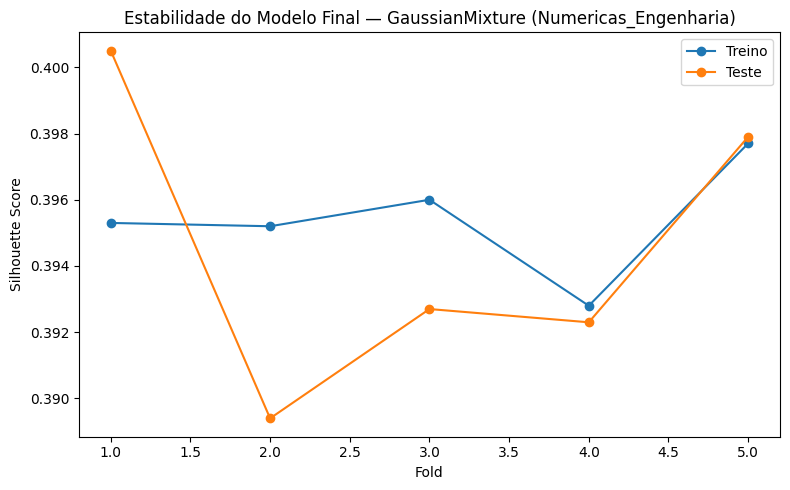

In [95]:
# Gráfico de estabilidade do modelo final por fold

plt.figure(figsize=(8, 5))

for conjunto in estabilidade_modelo_final_df["Conjunto"].unique():
    subset = estabilidade_modelo_final_df[
        estabilidade_modelo_final_df["Conjunto"] == conjunto
    ]
    
    plt.plot(
        subset["Fold"],
        subset["Silhouette"],
        marker="o",
        label=conjunto
    )

plt.xlabel("Fold")
plt.ylabel("Silhouette Score")
plt.title(f"Estabilidade do Modelo Final — {nome_modelo_final}")
plt.legend()
plt.tight_layout()

plt.savefig(
    figures_path / "m3_estabilidade_modelo_final_kfold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 4. Avaliação do Modelo Final

Nesta secção é avaliada a qualidade do modelo final de clustering.

Como o problema é não supervisionado, a avaliação não usa matriz de confusão, F1-Score ou ROC.  
A avaliação centra-se na coesão e separação dos clusters através do Silhouette Score, do Silhouette Plot, da visualização PCA e da caracterização dos perfis encontrados.

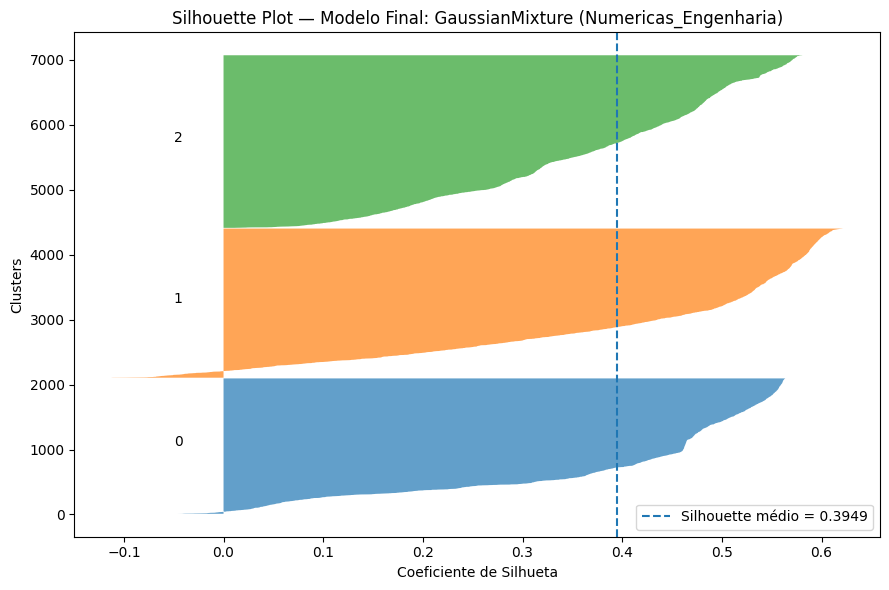

Silhouette médio do modelo final: 0.3949


In [96]:
# Silhouette Plot do modelo final

silhouette_vals = silhouette_samples(X_modelo_final, labels_modelo_final)
silhouette_medio = silhouette_score(X_modelo_final, labels_modelo_final)

y_lower = 10

plt.figure(figsize=(9, 6))

for cluster_id in sorted(np.unique(labels_modelo_final)):
    cluster_silhouette_vals = silhouette_vals[labels_modelo_final == cluster_id]
    cluster_silhouette_vals.sort()
    
    size_cluster = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster
    
    plt.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_silhouette_vals,
        alpha=0.7
    )
    
    plt.text(
        -0.05,
        y_lower + 0.5 * size_cluster,
        str(cluster_id)
    )
    
    y_lower = y_upper + 10

plt.axvline(
    x=silhouette_medio,
    linestyle="--",
    label=f"Silhouette médio = {silhouette_medio:.4f}"
)

plt.title(f"Silhouette Plot — Modelo Final: {nome_modelo_final}")
plt.xlabel("Coeficiente de Silhueta")
plt.ylabel("Clusters")
plt.legend()
plt.tight_layout()

plt.savefig(
    figures_path / "m3_silhouette_plot_modelo_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Silhouette médio do modelo final:", round(silhouette_medio, 4))

In [97]:
# Diagnóstico de coesão por cluster
silhouette_individual = silhouette_samples(
    X_modelo_final,
    labels_modelo_final
)

diagnostico_silhouette_df = pd.DataFrame({
    "Cluster_Final": labels_modelo_final,
    "Silhouette_Individual": silhouette_individual
})

diagnostico_clusters = diagnostico_silhouette_df.groupby("Cluster_Final").agg(
    N_Clientes=("Silhouette_Individual", "count"),
    Silhouette_Media=("Silhouette_Individual", "mean"),
    Silhouette_Mediana=("Silhouette_Individual", "median"),
    Silhouette_Minima=("Silhouette_Individual", "min"),
    Silhouette_Maxima=("Silhouette_Individual", "max"),
    Percentagem_Silhouette_Negativa=(
        "Silhouette_Individual",
        lambda x: round((x < 0).mean() * 100, 2)
    )
).round(4)

print("Diagnóstico de coesão por cluster:")
display(diagnostico_clusters)

diagnostico_clusters.to_csv(
    processed_path / "m3_diagnostico_silhouette_por_cluster.csv"
)

Diagnóstico de coesão por cluster:


,N_Clientes,Silhouette_Media,Silhouette_Mediana,Silhouette_Minima,Silhouette_Maxima,Percentagem_Silhouette_Negativa
Cluster_Final,,,,,,
0,2086,0.3946,0.4626,-0.0466,0.5645,1.53
1,2298,0.4189,0.5066,-0.1129,0.6219,4.44
2,2659,0.3744,0.3993,0.0110,0.5812,0.00


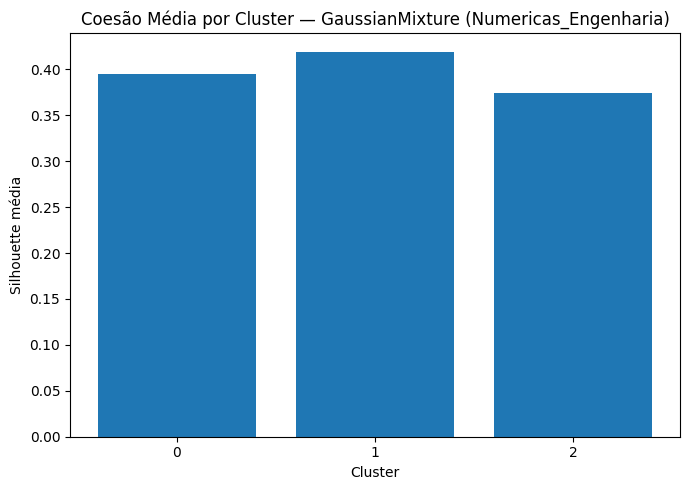

In [98]:
# Gráfico da Silhouette média por cluster

diagnostico_clusters_plot = diagnostico_clusters.reset_index()

plt.figure(figsize=(7, 5))

plt.bar(
    diagnostico_clusters_plot["Cluster_Final"].astype(str),
    diagnostico_clusters_plot["Silhouette_Media"]
)

plt.xlabel("Cluster")
plt.ylabel("Silhouette média")
plt.title(f"Coesão Média por Cluster — {nome_modelo_final}")
plt.tight_layout()

plt.savefig(
    figures_path / "m3_silhouette_media_por_cluster.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

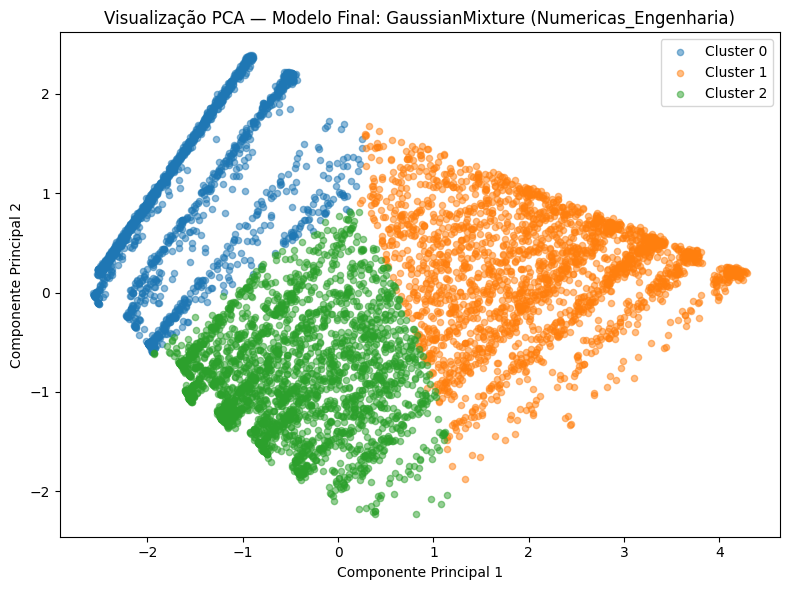

Variância explicada pelas duas primeiras componentes:
[0.69669122 0.20828152]

Variância explicada acumulada:
0.905


In [99]:
# Visualização PCA do modelo final

pca_final = PCA(n_components=2, random_state=42)
X_pca_final = pca_final.fit_transform(X_modelo_final)

pca_final_df = pd.DataFrame({
    "PC1": X_pca_final[:, 0],
    "PC2": X_pca_final[:, 1],
    "Cluster_Final": labels_modelo_final
})

plt.figure(figsize=(8, 6))

for cluster_id in sorted(pca_final_df["Cluster_Final"].unique()):
    subset = pca_final_df[pca_final_df["Cluster_Final"] == cluster_id]
    
    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"Cluster {cluster_id}",
        alpha=0.5,
        s=20
    )

plt.title(f"Visualização PCA — Modelo Final: {nome_modelo_final}")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend()
plt.tight_layout()

plt.savefig(
    figures_path / "m3_pca_modelo_final.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Variância explicada pelas duas primeiras componentes:")
print(pca_final.explained_variance_ratio_)

print("\nVariância explicada acumulada:")
print(round(pca_final.explained_variance_ratio_.sum(), 4))

In [100]:
# Caracterização dos clusters finais 

df_perfis = df_m2.copy()
df_perfis["Cluster_Final"] = labels_modelo_final

variaveis_numericas_perfil = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "ServiceCount",
    "AvgChargePerTenure"
]

variaveis_numericas_perfil = [
    col for col in variaveis_numericas_perfil
    if col in df_perfis.columns
]

perfil_numerico = df_perfis.groupby("Cluster_Final")[variaveis_numericas_perfil].agg(
    ["mean", "median", "std"]
).round(2)

print("Perfil numérico dos clusters:")
display(perfil_numerico)

perfil_numerico.to_csv(
    processed_path / "m3_perfil_numerico_clusters_finais.csv"
)

Perfil numérico dos clusters:


tenure               MonthlyCharges               TotalCharges  \
                mean median    std           mean median    std         mean   
Cluster_Final                                                                  
0              27.61   21.0  23.76          25.52  20.55   8.57       689.62   
1              57.29   60.0  12.77          89.79  93.40  17.32      5127.99   
2              14.57   12.0  11.96          73.92  74.90  15.74      1065.63   

                                ServiceCount              AvgChargePerTenure  \
                median      std         mean median   std               mean   
Cluster_Final                                                                  
0               481.95   643.15         1.25    1.0  0.56              25.47   
1              4972.75  1542.82         5.56    6.0  1.38              89.85   
2               865.10   871.30         3.12    3.0  1.27              73.74   

                             
              median    std  
Cluster_Final                
0              21.45   8.82  
1              93.06  17.45  
2              74.60  16.35

In [101]:
# Perfil categórico dos clusters finais

variaveis_categoricas_perfil = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

variaveis_categoricas_perfil = [
    col for col in variaveis_categoricas_perfil
    if col in df_perfis.columns
]

perfil_categorico_resultados = []

for cluster_id in sorted(df_perfis["Cluster_Final"].unique()):
    df_cluster = df_perfis[df_perfis["Cluster_Final"] == cluster_id]
    
    for coluna in variaveis_categoricas_perfil:
        proporcoes = df_cluster[coluna].value_counts(normalize=True).head(3) * 100
        
        for categoria, percentagem in proporcoes.items():
            perfil_categorico_resultados.append({
                "Cluster": cluster_id,
                "Variavel": coluna,
                "Categoria": categoria,
                "Percentagem_%": round(percentagem, 2)
            })

perfil_categorico_df = pd.DataFrame(perfil_categorico_resultados)

print("Principais categorias por cluster:")
display(perfil_categorico_df.head(60))

perfil_categorico_df.to_csv(
    processed_path / "m3_perfil_categorico_clusters_finais.csv",
    index=False
)

Principais categorias por cluster:


,Cluster,Variavel,Categoria,Percentagem_%
0,0,gender,Male,51.29
1,0,gender,Female,48.71
2,0,SeniorCitizen,0,94.01
3,0,SeniorCitizen,1,5.99
4,0,Partner,No,55.51
5,0,Partner,Yes,44.49
6,0,Dependents,No,62.61
7,0,Dependents,Yes,37.39
8,0,Contract,Month-to-month,46.36
9,0,Contract,Two year,32.26


In [102]:
# Variáveis finais que mais distinguem cada cluster

df_features_clusters = pd.DataFrame(X_modelo_final).copy()
df_features_clusters["Cluster_Final"] = labels_modelo_final

medias_cluster = df_features_clusters.groupby("Cluster_Final").mean()
media_global = pd.DataFrame(X_modelo_final).mean()

desvios_cluster = medias_cluster.subtract(media_global, axis=1)

top_variaveis_cluster = []

for cluster_id in desvios_cluster.index:
    desvios_abs = desvios_cluster.loc[cluster_id].abs().sort_values(ascending=False)
    top_variaveis = desvios_abs.head(10).index
    
    for variavel in top_variaveis:
        top_variaveis_cluster.append({
            "Cluster": cluster_id,
            "Variavel": variavel,
            "Desvio": round(desvios_cluster.loc[cluster_id, variavel], 4),
            "Desvio_Absoluto": round(abs(desvios_cluster.loc[cluster_id, variavel]), 4)
        })

top_variaveis_cluster_df = pd.DataFrame(top_variaveis_cluster)

print("Top variáveis diferenciadoras por cluster:")
display(top_variaveis_cluster_df)

top_variaveis_cluster_df.to_csv(
    processed_path / "m3_top_variaveis_diferenciadoras_clusters.csv",
    index=False
)

Top variáveis diferenciadoras por cluster:


,Cluster,Variavel,Desvio,Desvio_Absoluto
0,0,MonthlyCharges,-1.3042,1.3042
1,0,ServiceCount,-1.0270,1.0270
2,0,TotalCharges,-0.7015,0.7015
3,0,HasInternetService,-0.5149,0.5149
4,0,tenure,-0.1937,0.1937
5,0,SeniorCitizen,-0.1022,0.1022
6,1,TotalCharges,1.2566,1.2566
7,1,ServiceCount,1.0671,1.0671
8,1,tenure,1.0146,1.0146
9,1,MonthlyCharges,0.8317,0.8317


,tenure,MonthlyCharges,TotalCharges,ServiceCount,AvgChargePerTenure
Cluster_Final,,,,,
0,0.305,0.000,0.000,0.000,0.00
1,1.000,1.000,1.000,1.000,1.00
2,0.000,0.753,0.085,0.435,0.75


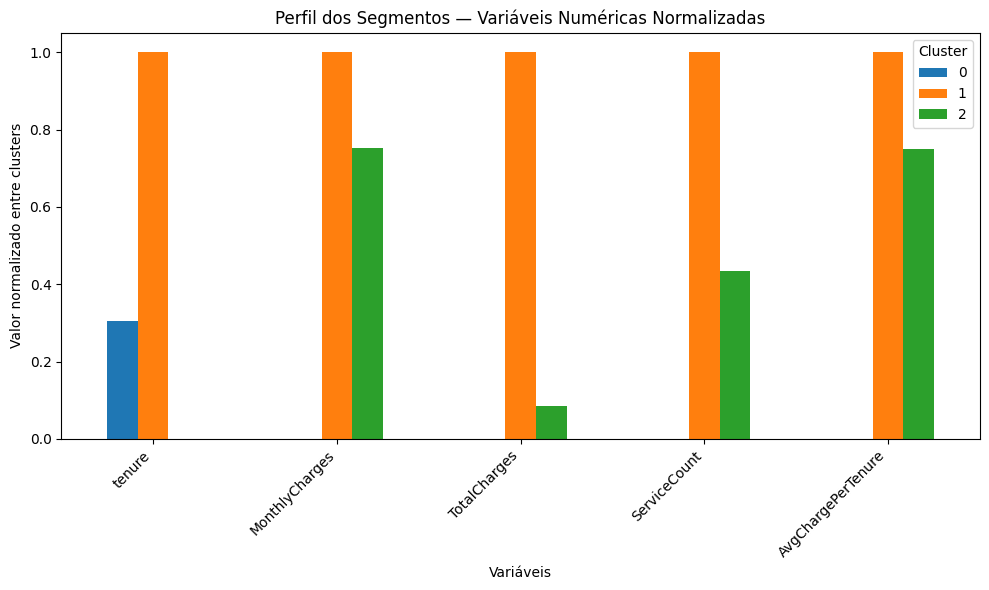

In [103]:
# Gráfico de perfil dos segmentos com variáveis numéricas normalizadas

perfil_medias = df_perfis.groupby("Cluster_Final")[variaveis_numericas_perfil].mean()

perfil_medias_normalizado = (
    perfil_medias - perfil_medias.min()
) / (
    perfil_medias.max() - perfil_medias.min()
)

perfil_medias_normalizado = perfil_medias_normalizado.fillna(0)

display(perfil_medias_normalizado.round(3))

ax = perfil_medias_normalizado.T.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Perfil dos Segmentos — Variáveis Numéricas Normalizadas")
plt.xlabel("Variáveis")
plt.ylabel("Valor normalizado entre clusters")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Cluster")
plt.tight_layout()

plt.savefig(
    figures_path / "m3_perfil_segmentos_variaveis_numericas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [104]:
# Síntese final

print("===== SÍNTESE FINAL DA M3 =====")

print("\n1. Melhor modelo candidato inicial no teste:")
print("Modelo:", melhor_modelo_candidato["Modelo"])
print("Nº de clusters:", melhor_modelo_candidato["N_Clusters"])
print("Silhouette:", melhor_modelo_candidato["Silhouette"])
print("Davies-Bouldin:", melhor_modelo_candidato["Davies_Bouldin"])

print("\n2. Melhor configuração K-Means com 3 clusters em Cross-Validation:")
print(parametros_finais)
print("Silhouette médio CV:", melhor_config_k3["Silhouette_Media"])
print("Desvio-padrão CV:", melhor_config_k3["Silhouette_Desvio"])

if "melhor_modelo_avancado_full" in globals():
    print("\n3. Melhor modelo global encontrado na otimização avançada:")
    display(melhor_modelo_avancado_full)

if "melhor_k3_avancado_full" in globals() and melhor_k3_avancado_full is not None:
    print("\n4. Melhor modelo avançado alinhado com o Objetivo SMART, com 3 clusters:")
    display(melhor_k3_avancado_full)

print("\n5. Decisão final:")
print(decisao_final)

print("\n6. Modelo final utilizado na avaliação:")
print(nome_modelo_final)

print("\n7. Métricas finais do modelo escolhido:")
display(metricas_modelo_final_df)

print("\n8. Distribuição dos clusters finais:")
display(clusters_modelo_final_resumo)

print("\n9. Comparação entre modelo atual, melhor global e melhor modelo com 3 clusters:")
display(comparacao_modelos_final)

print("\n10. Ficheiros principais guardados em data/processed e reports/figures.")

===== SÍNTESE FINAL DA M3 =====

1. Melhor modelo candidato inicial no teste:
Modelo: KMeans
Nº de clusters: 3
Silhouette: 0.2194
Davies-Bouldin: 1.586

2. Melhor configuração K-Means com 3 clusters em Cross-Validation:
{'n_clusters': 3, 'init': 'random', 'n_init': 20, 'max_iter': 300, 'algorithm': 'elkan', 'random_state': 42}
Silhouette médio CV: 0.2159
Desvio-padrão CV: 0.0049

3. Melhor modelo global encontrado na otimização avançada:


Variante_Dados       Numericas_Engenharia
Modelo                    GaussianMixture
n_components                          2.0
covariance_type                 spherical
n_init                                5.0
random_state                         42.0
N_Clusters                              2
Ruido_%                               0.0
Silhouette                         0.4377
Davies_Bouldin                     0.8396
Calinski_Harabasz               7232.9524
Inercia                               NaN
Min_Cluster_%                       31.55
n_clusters                            NaN
init                                  NaN
max_iter                              NaN
algorithm                             NaN
batch_size                            NaN
threshold                             NaN
branching_factor                      NaN
Name: 0, dtype: object


4. Melhor modelo avançado alinhado com o Objetivo SMART, com 3 clusters:


Variante_Dados       Numericas_Engenharia
Modelo                    GaussianMixture
n_components                          3.0
covariance_type                 spherical
n_init                                5.0
random_state                         42.0
N_Clusters                              3
Ruido_%                               0.0
Silhouette                         0.3947
Davies_Bouldin                     0.9626
Calinski_Harabasz               7142.2309
Inercia                               NaN
Min_Cluster_%                       29.62
n_clusters                            NaN
init                                  NaN
max_iter                              NaN
algorithm                             NaN
batch_size                            NaN
threshold                             NaN
branching_factor                      NaN
Name: 22, dtype: object


5. Decisão final:
Substituir pelo melhor modelo avançado com 3 clusters.

6. Modelo final utilizado na avaliação:
GaussianMixture (Numericas_Engenharia)

7. Métricas finais do modelo escolhido:


...


8. Distribuição dos clusters finais:


,Cluster,Nº de clientes,Percentagem (%)
0,0,2086,29.62
1,1,2298,32.63
2,2,2659,37.75



9. Comparação entre modelo atual, melhor global e melhor modelo com 3 clusters:


,Cenario,Variante_Dados,Modelo,N_Clusters,Silhouette,Davies_Bouldin,Min_Cluster_%,Melhoria_Silhouette
0,Modelo atual,Atual_M2,KMeans Otimizado,3,0.2161,1.6155,30.81,0.0000
1,Melhor modelo avançado,Numericas_Engenharia,GaussianMixture,2,0.4377,0.8396,31.55,0.2216
2,Melhor avançado com 3 clusters,Numericas_Engenharia,GaussianMixture,3,0.3947,0.9626,29.62,0.1786



10. Ficheiros principais guardados em data/processed e reports/figures.
